In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from datetime import datetime
pd.set_option('display.max_columns', None)

In [ ]:
symbs = [
"BTC-USD", "ETH-USD", "XRP-USD", "LTC-USD", "ADA-USD", "SOL-USD", "DOT-USD","ENJ-USD", "ATOM-USD",  "FIL-USD", "VET-USD", "XTZ-USD", "AAVE-USD", "LINK-USD", "ALGO-USD", 
"AVAX-USD", "DOT-USD", "ZEC-USD", "CRV-USD", "SNX-USD", "XLM-USD", "AXS-USD",
# forex
"EURUSD=X", "JPY=X", "GBPUSD=X",  "EURJPY=X","GBPJPY=X","EURGBP=X","EURCAD=X", "EURCHF=X","CADUSD=X","CADJPY=X",
#"CHFJPY=X","GBPCHF=X", "AUDUSD=X", "NZDUSD=X", "AUDJPY=X","AUDCAD=X","AUDCHF=X","NZDJPY=X","NZDCAD=X","NZDCHF=X",
# acciones 
"AAPL", "MSFT", "GOOGL", "AMZN", "META","NVDA", "TSLA", "NFLX", "PLTR", "INTC", "ORCL", "IBM", "CSCO", "PYPL", "BABA", "KO", "V","ADBE", "JPM", "XOM", "CVX", "WMT", 
"DIS", "BA", "MCD", "NKE", "PFE", "HD", "VZ", "PEP", "T", "ABT", "CVS", "WFC", "LLY", "ACN", "MDT", "DHR", "NEE", "BMY", "AMGN", "QCOM", "TXN", "LOW", "INTU", "MMM", "GE", 
"CAT", "DE", #"F", "GM", "UPS", "FDX", "BA", "LMT", "RTX", "NOC", "GD", "HON", "UNP", "CSX", "NSC", "KSU", "DAL", "UAL", "LUV", "AAL", "JBLU",
# "ALK", "RCL", "CCL", "NCLH", "MAR", "HST", "WYN", "EXPE", "BKNG", "SPG", "VNO", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS",
# "UDR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR","VTR", "O", "EPR", "BXP", 
# "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", 
# "VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR","VTR", "O", "EPR", "BXP", "SLG", "EQR", "AVB", "ESS", "UDR", "VTR", "O", "EPR", "BXP", "SLG", 
# "EQR", "AVB", "ESS", 
# indices 
"^GSPC",   # S&P 500
# "^DJI",    # Dow Jones. no esta en xm
"^IXIC",   # Nasdaq
# etfs
# "SI=F", # Silver
# "BZ=F", # BRENT
# "PL=F", # Platinum,
# "NG=F", # NATURAL GAS

]
symbs_crypto = [x for x in symbs if "-USD" in x]
symbs_forex = [x for x in symbs if "=X" in x]
symbs_stocks = [x for x in symbs if x not in symbs_crypto and x not in symbs_forex]
symbs = list(set(symbs))
print("Total:", len(symbs))
print("Crypto :", len(symbs_crypto), f"({(len(symbs_crypto)/len(symbs))*100:.0f}%)")
print("Forex:", len(symbs_forex), f"({(len(symbs_forex)/len(symbs))*100:.0f}%)")
print("Stocks:", len(symbs_stocks), f"({(len(symbs_stocks)/len(symbs))*100:.0f}%)")

In [ ]:
# from more_itertools import last
import yfinance as yf
SYMBOLS = symbs 

# EMAS
EMA_SHORT       = 20
EMA_MID         = 50
EMA_LONG        = 200
# RSI
RSI_PERIOD      = 14
# MACD
MACD_FAST       = 12
MACD_SLOW       = 26
MACD_SIGNAL     = 9
# Bollinger
BB_PERIOD       = 20
BB_STD          = 2.0
# Estocastico
STOCH_K         = 9
STOCH_D         = 3
STOCH_SLOWING   = 3  
# ATR
ATR_PERIOD      = 14
# ATR - Gestión de riesgo
ATR_MULT_SL     = 1.5           # Multiplicador ATR para Stop Loss
ATR_MULT_TP     = 3.0           # Multiplicador ATR para Take Profit (ratio 2:1)
# Parámetro principal: mínimo de reglas que deben cumplirse 
# Rango válido: 1–8. Recomendado: 5 (conservador-moderado), 4 (agresivo), 6 (muy conservador)
MIN_RULES_TO_SIGNAL = 5
# Umbrales RSI 
RSI_OVERSOLD    = 35 # 35
RSI_OVERBOUGHT  = 70 # 65
# Umbrales Estocástico
STOCH_OVERSOLD  = 25
STOCH_OVERBOUGHT = 75
# Umbrales de posición dentro del canal BB
BB_ENTRY_SELL_MIN  = 0.75   # Para VENDER: precio debe estar en el > 75% del canal
BB_ENTRY_BUY_MAX   = 0.25   # Para COMPRAR: precio debe estar en el < 25% del canal
BB_WAIT_SELL_MIN   = 0.45   # Por debajo de esto en venta  → esperar subida
BB_WAIT_BUY_MAX    = 0.55   # Por encima de esto en compra → esperar bajada
# VPVMA
BANDWITH=0.1 # 0.1 filtro para reducir señales falsas (default 0.1)
# Volatility
VOLATILITY_PERIOD = 20
# Hull MA
HMA_FAST = 21
HMA_SLOW = 55
# Breakout structure
BREAKOUT_N = 20

import pandas as pd
def calc_ema(series: pd.Series, period: int) -> pd.Series:
    return series.ewm(span=period, adjust=False).mean()


def calc_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def calc_macd(close: pd.Series, fast: int, slow: int, signal: int):
    ema_fast   = calc_ema(close, fast)
    ema_slow   = calc_ema(close, slow)
    macd_line  = ema_fast - ema_slow
    signal_line = calc_ema(macd_line, signal)
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram


def calc_bollinger(close: pd.Series, period: int, std_mult: float):
    mid   = close.rolling(period).mean()
    std   = close.rolling(period).std()
    upper = mid + std_mult * std
    lower = mid - std_mult * std
    return upper, mid, lower


def calc_stochastic(high: pd.Series, low: pd.Series, close: pd.Series,
                    k_period: int, slowing: int, d_period: int):
    lowest_low   = low.rolling(k_period).min()
    highest_high = high.rolling(k_period).max()
    denom = (highest_high - lowest_low).replace(0, np.nan)
    
    raw_k = 100 * (close - lowest_low) / denom  # %K crudo
    k     = raw_k.rolling(slowing).mean()        # %K suavizado (Slowing)
    d     = k.rolling(d_period).mean()           # %D
    return k, d


def calc_atr(high: pd.Series, low: pd.Series, close: pd.Series,
             period: int) -> pd.Series:
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.ewm(com=period - 1, min_periods=period).mean()


def calc_obv(close: pd.Series, volume: pd.Series) -> pd.Series:
    direction = np.sign(close.diff()).fillna(0)
    return (direction * volume).cumsum()


def calc_adx(high, low, close, period=14):
    tr = calc_atr(high, low, close, period) 

    up_move   = high.diff()
    down_move = -low.diff()

    plus_dm  = np.where((up_move > down_move) & (up_move > 0), up_move, 0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0)

    plus_dm  = pd.Series(plus_dm,  index=close.index)
    minus_dm = pd.Series(minus_dm, index=close.index)

    atr      = tr
    plus_di  = 100 * plus_dm.ewm(com=period-1).mean()  / atr
    minus_di = 100 * minus_dm.ewm(com=period-1).mean() / atr

    dx  = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx = dx.ewm(com=period-1).mean()

    return adx, plus_di, minus_di


def calc_bb_position(df):
    """
    Retorna la posición relativa del precio dentro del canal BB.
      0.0 → precio en la banda inferior
      0.5 → precio en la media (mitad del canal)
      1.0 → precio en la banda superior
    """
    return (df["Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"] + 1e-9)


def calculate_vpvma(df, window_fast=12, window_slow=26, window_sign=9):
    """
    VPVMA - Volume Price Volatility Moving Average
    Derivado del MACD por Pat Tong Chio (2022)
    
    Parámetros:
        df           : DataFrame con columnas Open, High, Low, Close, Volume
        window_fast  : período corto (default 12)
        window_slow  : período largo (default 26)
        window_sign  : período de señal (default 9)
        bandwidth    : filtro para reducir señales falsas (default 0.1)
    """
    df["TP"] = (df["High"] + df["Low"] + df["Close"]) / 3

    df["TP_x_Vol"] = df["TP"] * df["Volume"]

    df["SVWMA"] = (
        df["TP_x_Vol"].rolling(window=window_fast).sum() /
        df["Volume"].rolling(window=window_fast).sum()
    )

    df["LVWMA"] = (
        df["TP_x_Vol"].rolling(window=window_slow).sum() /
        df["Volume"].rolling(window=window_slow).sum()
    )

    df["DV"] = df[["Open", "High", "Low", "Close"]].std(axis=1)

    df["SVWMA_x_DV"] = df["SVWMA"] * df["DV"]
    df["LVWMA_x_DV"] = df["LVWMA"] * df["DV"]

    df["ESVMap"] = df["SVWMA_x_DV"].ewm(span=window_fast, adjust=False).mean()
    df["ELVMap"] = df["LVWMA_x_DV"].ewm(span=window_slow, adjust=False).mean()

    df["VPVMA"]  = df["ESVMap"] - df["ELVMap"]
    df["VPVMAS"] = df["VPVMA"].rolling(window=window_sign).mean()
    df.drop(columns = ["SVWMA", "TP", "TP_x_Vol", "SVWMA", "DV", "SVWMA_x_DV", "LVWMA_x_DV", "ESVMap", "ELVMap"], inplace = True)    


    return df


def evaluate_entry_quality(signal: str, bb_pos: float) -> dict:
    """
    Evalúa si el precio está en una zona ÓPTIMA para entrar o si es necesario esperar el REBOTE. 
    Se valida que no esteen la mitad del canal, sino en zonas XTREMs (superior para venta, inferior para compra).
    
    Zonas para VENDER (bb_pos):
    🟢 ZONA ÓPTIMA VENTA    (>= 0.75)      
    🟡 ZONA ACEPTABLE VENTA (0.55 – 0.75)  
    🔴 ESPERAR SUBIDA       (< 0.55)       

    Zonas para COMPRAR (bb_pos):
    🔴 ESPERAR BAJADA       (> 0.55)      
    🟡 ZONA ACEPTABLE COMPRA (0.25 – 0.45) 
    🟢 ZONA ÓPTIMA COMPRA   (<= 0.25) 
    """
    pct = bb_pos * 100 

    if "🔴" in signal:
        if bb_pos >= BB_ENTRY_SELL_MIN:
            return {
                "entry_ok":   True,
                "advice": "🔴",
                "entry_zone":     f"🔴",
                "bb_pct":     pct,
            }
        elif bb_pos >= BB_WAIT_SELL_MIN:
            return {
                "entry_ok":   False,
                "advice": "🟡", # Nivel aceptable, mejor esperar 
                "entry_zone":     (f"🟡 > {BB_ENTRY_SELL_MIN*100:.0f}%"),
                "bb_pct":     pct,
            }
        else:
            return {
                "entry_ok":   False,
                "advice": "⚪",
                "entry_zone":     (f"⚪ > {BB_ENTRY_SELL_MIN*100:.0f}%"), 
                "bb_pct":     pct,
            }

    elif "🟢" in signal:
        if bb_pos <= BB_ENTRY_BUY_MAX:
            return {
                "entry_ok":   True,
                "advice": "🟢",
                "entry_zone":     f"🟢",
                "bb_pct":     pct,
            }
        elif bb_pos <= BB_WAIT_BUY_MAX:
            return {
                "entry_ok":   False,
                "advice": "🟡",  
                "entry_zone":     (f"🟡 < {BB_ENTRY_BUY_MAX*100:.0f}%"),
                "bb_pct":     pct,
            }
        else:
            return {
                "entry_ok":   False,
                "advice": "⚪",
                "entry_zone":     (f"⚪ < {BB_ENTRY_BUY_MAX*100:.0f}%"),
                "bb_pct":     pct,
            }

    # Para ESPERAR no aplica
    return {"entry_ok": False, "entry_zone": "", "advice": "", "bb_pct": pct}

def calc_consistencia(close: pd.Series) -> pd.Series:
    prev26 = close.shift(26)
    prev52 = close.shift(52)

    return prev26, prev52

def build_indicators(df: pd.DataFrame) -> pd.DataFrame:
    c, h, l, v = df["Close"], df["High"], df["Low"], df["Volume"]

    df["EMA20"]  = calc_ema(c, EMA_SHORT)
    df["EMA50"]  = calc_ema(c, EMA_MID)
    df["EMA200"] = calc_ema(c, EMA_LONG)

    df["RSI"] = calc_rsi(c, RSI_PERIOD)

    df["MACD"], df["MACD_signal"], df["MACD_hist"] = calc_macd(
        c, MACD_FAST, MACD_SLOW, MACD_SIGNAL
    )

    df["BB_upper"], df["BB_mid"], df["BB_lower"] = calc_bollinger(c, BB_PERIOD, BB_STD)

    df["STOCH_K"], df["STOCH_D"] = calc_stochastic(h, l, c, STOCH_K, STOCH_SLOWING, STOCH_D)

    df["ATR"] = calc_atr(h, l, c, ATR_PERIOD)

    df["OBV"]     = calc_obv(c, v)
    df["OBV_EMA"] = calc_ema(df["OBV"], 20)

    df["ADX"], df["ADX+DI"], df["ADX-DI"] = calc_adx(h, l, c, period=14)

    df["prev26"], df["prev52"] = calc_consistencia(c)

    df = calculate_vpvma(df)

    df["VWAP"] = (df["Close"] * df["Volume"]).cumsum() / df["Volume"].cumsum()

    df["spread"] = (df["High"] - df["Low"]) / df["Close"]
    
    df["vol_ma"] = df["Volume"].rolling(20).mean()
    df["volume_increasing"] = df["Volume"] > df["vol_ma"]
    
    df["order_flow"] = np.where(df["Close"] > df["Open"], "buy", "sell")

    df["volatility"] = df["Close"].pct_change().rolling(VOLATILITY_PERIOD).std()

    # df.dropna(inplace=True)
    return df


def fmt(n, decimals=4) -> str:
    if n is None:
        return "N/A"
    fmt_str = f"{{:,.{decimals}f}}"
    return fmt_str.format(n)


def compute_tp_sl(price: float, atr: float, direction: str) -> tuple:
    """
    Retorna (take_profit, stop_loss) basados en ATR.
    direction: 'BUY' o 'SELL'
    """
    if direction == "🟢":
        sl = price - ATR_MULT_SL * atr
        tp = price + ATR_MULT_TP * atr
    else:  # SELL
        sl = price + ATR_MULT_SL * atr
        tp = price - ATR_MULT_TP * atr
    return tp, sl

def analyze_symbol(symbol: str, INTERVAL:int, LOOKBACK_DAYS:int) -> dict:
    # symbol = "CVS" # usar antes del 15/04 ya que 3 estrategias se alinean para sell
    # LOOKBACK_DAYS = 40
    # INTERVAL = "1h"

    for _ in range(3):
        try:
            df = yf.download(
                symbol,
                period=f"{LOOKBACK_DAYS}d",
                interval=INTERVAL,
                progress=False,
                auto_adjust=True,
            )
        except Exception as e:
            print(f"ERROR: {symbol} - {e}")
            return pd.DataFrame()

        if len(df) > 0:
            break   

    if df.empty or len(df) < EMA_LONG + 10:
        print(f"ERROR: {symbol} - len(df) < {EMA_LONG + 10}")
        return pd.DataFrame()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if len(df) < 2:
        print(f"ERROR: {symbol} - len(df) < 2")
        return pd.DataFrame()
    
    df["date"] = df.index
    df = build_indicators(df.copy())
    bb_pos   = calc_bb_position(df)

    # ------------------------------- SEÑALES -------------------------------#
    
    #---------------------------------- VERSIONES MACD + RSI
    # ----------- 1.1 MACD + RSI exigente
    """
    RSI bajo durante varias velas = presión vendedora estructural
    MACD cruzando = inicio del cambio
    Es un detector de “agotamiento + giro temprano”
    """
    df["rsi_below_35"] = (df["RSI"] < 30).astype(int)
    df["rsi_above_65"] = (df["RSI"] > 70).astype(int)

    df["count_men"] = df["rsi_below_35"].rolling(6, min_periods = 1).sum()
    df["count_may"] = df["rsi_above_65"].rolling(6, min_periods = 1).sum()

    df["macd_signal"] = np.where(
        df["MACD"] > df["MACD_signal"], 1,
        np.where(df["MACD"] < df["MACD_signal"], -1, 0)
    )

    # El umbral 4 originalmente era 6 (AJUSTE para que salgan señales)
    df["sign_macd_rsi_robust"] = np.where(
        (df["count_men"] >= 4) & (df["macd_signal"] == 1), "🟢",
        np.where(
            (df["count_may"] >= 4) & (df["macd_signal"] == -1), "🔴",
            ""
        )
    )
    del df["rsi_below_35"], df["rsi_above_65"], df["count_men"], df["count_may"], df["macd_signal"]


    #-----------1.2 MACD + RSI no exigente
    df["str_macd_rsi_simple"] = np.where((df["MACD"] > df["MACD_signal"]) & (df["RSI"] < 30), "🟢",
                                    np.where((df["MACD"] < df["MACD_signal"]) & (df["RSI"] > 70), "🔴", ""))

    #-----------1.1.2 MACD + RSI no exigente + confirmacion breakout
    df["str_macd_rsi_simple_break"] = np.where((df["str_macd_rsi_simple"] == "🟢") & (df["Close"] > df["High"].shift(1)), "🟢",
                                          np.where((df["str_macd_rsi_simple"] == "🔴") & (df["Close"] < df["Low"].shift(1)), "🔴", ""))

    # ---------- 2.2 MACD + RSI exigente + filtro de posición en BB
    df["bb_pos"] = bb_pos
    df["str_macd_rsi_simple_bb_pos"] = np.where((df["str_macd_rsi_simple"] == "🟢") & (df["bb_pos"] < 0.2), "🟢",
                                np.where((df["str_macd_rsi_simple"] == "🔴") & (df["bb_pos"] > 0.8), "🔴", ""))

    #---------- 3.1 RSI + Bollinger
    df["str_macd_rsi_bb"] = np.where((df["RSI"] < 30) & (df["Close"] < df["BB_lower"]), "🟢", 
                                   np.where((df["RSI"] > 70) & (df["Close"] > df["BB_upper"]), "🔴", ""))
    
    #---------- 3.2 RSI + Bollinger + Tendencia EMA
    df["str_macd_rsi_bb_ema"] = np.where((df["RSI"] < 30) & (df["Close"] < df["BB_lower"]) & (df["Close"] > df["EMA200"]), "🟢", 
                                   np.where((df["RSI"] > 70) & (df["Close"] > df["BB_upper"]) & (df["Close"] < df["EMA200"]), "🔴", ""))
    


    #---------------------------------- VERSIONES ADX
    #---------- 1 ADX + DI
    df["str_adx"] = np.where((df["ADX"] > 25) & (df["ADX+DI"] > df["ADX-DI"]), "🟢", 
                     np.where((df["ADX"] > 25) & (df["ADX-DI"] > df["ADX+DI"]), "🔴", ""))
    
    #---------- 1.1 ADX + DI + Pendiente tendencia ADX
    # ADX > 25 puede venir de un movimiento viejo o ya agotado.
    # ADX creciente (ADX[t] > ADX[t-1])
    df["str_adx_crec"] = np.where((df["str_adx"] == "🟢") & (df["ADX"] > df["ADX"].shift(1)), "🟢",
                          np.where((df["str_adx"] == "🔴") & (df["ADX"] > df["ADX"].shift(1)), "🔴", ""))


    #---------- 1.1.2 ADX + DI + Pendiente tendencia ADX
    df["str_adx_crec_rsi"] = np.where((df["str_adx"] == "🟢") & (df["ADX"] > df["ADX"].shift(1)) & (df["RSI"] < 45), "🟢",
                              np.where((df["str_adx"] == "🔴") & (df["ADX"] > df["ADX"].shift(1)) & (df["RSI"] > 55), "🔴", ""))

    #---------- 1.1.3 ADX + DI + Pendiente tendencia ADX
    df["str_adx_rsi"] = np.where((df["str_adx"] == "🟢") & (df["RSI"] < 40), "🟢",
                         np.where((df["str_adx"] == "🔴") & (df["RSI"] > 60), "🔴", ""))

    df["str_adx_rsi_robust"] = np.where((df["str_adx"] == "🟢") & (df["RSI"] < 30), "🟢",
                                np.where((df["str_adx"] == "🔴") & (df["RSI"] > 70), "🔴", ""))
    
    df["str_adx_rsi_xtrem"] = np.where((df["str_adx"] == "🟢") & (df["RSI"] < 20), "🟢",
                               np.where((df["str_adx"] == "🔴") & (df["RSI"] > 80), "🔴", ""))



    # ---------- 2. VPVMA (volumen ponderado dinámico)
    """
    Qué mide: Precio ponderado por volumen vs su media
    Es parecido a VWAP, pero más “reactivo”
    Cruce = cambio en el equilibrio entre compradores/vendedores reales
    Detecta: “quién está ganando con dinero real”
    Riesgo: Sensible a spikes de volumen
    """

    signbuy_base = (
        (df["VPVMA"] > (1 + BANDWITH) * df["VPVMAS"]) &
        (df["VPVMA"].shift(1) <= df["VPVMAS"].shift(1))
    )

    signsell_base = (
        (df["VPVMA"] < (1 - BANDWITH * 2) * df["VPVMAS"]) &
        (df["VPVMA"].shift(1) >= df["VPVMAS"].shift(1))
    )

    window = 2
    recent_buy = signbuy_base.rolling(window).max().fillna(0).astype(bool)
    recent_sell = signsell_base.rolling(window).max().fillna(0).astype(bool)

    df["str_vpvma"] = np.where(recent_buy, "🟢", np.where(recent_sell, "🔴", ""))
    # vpvma = df["vpvma_sign"].iloc[-1]


    # ----------- 3. Sinergia
    """
    “solo opero cuando TODO está alineado”
    Riesgo
    Puede filtrar demasiado (pocas señales)
    """
    long_cond = (
        (df["Close"] > df["EMA20"]) &
        (df["RSI"] > 55) &
        (df["MACD"] > df["MACD_signal"]) &
        (df["Close"] > df["VWAP"]) &
        (df["spread"] < 0.01) &
        (df["volume_increasing"]) &
        (df["order_flow"] == "buy")
    )

    short_cond = (
        (df["Close"] < df["EMA20"]) &
        (df["RSI"] < 45) &
        (df["MACD"] < df["MACD_signal"]) &
        (df["Close"] < df["VWAP"]) &
        (df["spread"] < 0.01) &
        (df["volume_increasing"]) &
        (df["order_flow"] == "sell")
    )

    df["str_sinergia"] = ""
    df.loc[long_cond, "str_sinergia"] = "🟢"
    df.loc[short_cond, "str_sinergia"] = "🔴"
    # sinergia = df["str_sinergia"].iloc[-1]
    del df["order_flow"], df["volume_increasing"], df["spread"]


    # ----------- 4. RSI mean reversion + Bollinger
    """
    Qué mide
    Desviación XTREM del precio respecto a la media
    Se predice que el precio hace una reversion a la media
    Interpretación: “el mercado se estiró demasiado, va a regresar”
    Riesgo: En tendencias fuertes, el precio sigue “rompiendo la banda”
    """

    df["str_rsi_bb_rever"] = np.where((df['RSI'] < 30) & (df['Close'] <= df['Low']), "🟢", 
                             np.where((df['RSI'] > 70) & (df['Close'] >= df['High']), "🔴", ""))
    # reversionmean = df["str_rsi_bb_rever"].iloc[-1]
    

    # ----------- 5. Trend following: MA + MACD. 
    """
    Qué mide: Dirección + confirmación de momentum
    Interpretación: “me subo a la ola, no intento predecirla”
    Riesgo: Entradas tardías
    """
    
    df['trend'] = np.where(df['Close'] > df['EMA200'], 1, -1)

    df['long_signal'] = (
        (df['EMA50'] > df['EMA200']) &
        (df['MACD'] > df['MACD_signal']) &
        (df['trend'] == 1)
    )

    df['short_signal'] = (
        (df['EMA50'] < df['EMA200']) &
        (df['MACD'] < df['MACD_signal']) &
        (df['trend'] == -1)
    )

    # Evitar lookahead bias
    df['long_signal'] = df['long_signal'].shift(1)
    df['short_signal'] = df['short_signal'].shift(1)

    df["str_ma_macd"] = ""
    df.loc[df['long_signal'] == True, "str_ma_macd"] = "🟢"
    df.loc[df['short_signal'] == True, "str_ma_macd"] = "🔴"
    del df["long_signal"], df["short_signal"]

    # trendfollow = df["str_ma_macd"].iloc[-1]


    # ----------- 6. Squeeze + Keltner + Bollinger (str_squ_kel_bb)
    """
    Qué mide: Contracción de volatilidad
    Interpretación: “el mercado está comprimido → se viene explosión”
    Riesgo: No siempre predice dirección
    """

    length = 20
    mult_bb = 2.0
    mult_kc = 1.5

    # Bollinger Bands
    df['ma_20'] = df['Close'].rolling(window=length).mean()
    df['std_20'] = df['Close'].rolling(window=length).std()
    df['bb_upper'] = df['ma_20'] + (mult_bb * df['std_20'])
    df['bb_lower'] = df['ma_20'] - (mult_bb * df['std_20'])

    # Keltner Channels (Usando ATR para la banda)
    df['keltner_channels'] = np.maximum(df['High'] - df['Low'], 
                            np.maximum(abs(df['High'] - df['Close'].shift(1)), 
                                        abs(df['Low'] - df['Close'].shift(1))))
    df['atr_20'] = df['keltner_channels'].rolling(window=length).mean()
    df['kc_upper'] = df['ma_20'] + (mult_kc * df['atr_20'])
    df['kc_lower'] = df['ma_20'] - (mult_kc * df['atr_20'])

    # Lógica del Squeeze
    df['sign_squeeze'] = (df['bb_upper'] < df['kc_upper']) & (df['bb_lower'] > df['kc_lower'])

    # Momentum (Filtro simple para dirección del squeeze)
    df['momentum'] = df['Close'] - df['Close'].shift(length)

    df["str_squ_kel_bb"] = np.where((df['sign_squeeze'] == True) & (df['momentum'] > 0), "🟢",  
                           np.where((df['sign_squeeze'] == True) & (df['momentum'] < 0), "🔴", ""))
    
    # SE CAMBIO MOMENTUM POR ADX
    df["str_squ_kel_bb"] = np.where((df['sign_squeeze'] == True) & (df['str_adx'] == "🟢"), "🟢",  
                           np.where((df['sign_squeeze'] == True) & (df['str_adx'] == "🔴"), "🔴", ""))
    
    del df["momentum"], df["bb_upper"], df["bb_lower"], df["kc_upper"], df["kc_lower"], df["keltner_channels"]


    # ---------- 7. Hull MA
    """
    Qué mide: Tendencia suavizada pero rápida
    Interpretación: Más rápida que EMA, menos ruido
    Detecta: cambios de tendencia más temprano
    """
    def calculate_hull_ma(series, n):
        def wma(s, period):
            weights = np.arange(1, period + 1)
            return s.rolling(period).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
        
        half_n = int(n / 2)
        sqrt_n = int(np.sqrt(n))
        
        val = 2 * wma(series, half_n) - wma(series, n)
        hma = wma(val, sqrt_n)
        return hma

    df['hma_fast'] = calculate_hull_ma(df['Close'], HMA_FAST)
    df['hma_slow'] = calculate_hull_ma(df['Close'], HMA_SLOW)

    df['sign_hullma'] = np.where(df['hma_fast'] > df['hma_slow'], "🟢", 
                        np.where(df['hma_fast'] < df['hma_slow'], "🔴", ""))
    # hma = df['hma_sign'].iloc[-1]
    del df["hma_fast"], df["hma_slow"]



    # ----------- 1. Golden Cross y Death Cross 
    """
    Qué mide: Cambio estructural de tendencia
    Interpretación: Es una señal “lenta pero fuerte”
    Riesgo: Muy retrasada
    """
    golden_base = (
        (df["EMA20"] > df["EMA50"]) &
        (df["EMA20"].shift(1) <= df["EMA50"].shift(1))
    )

    death_base = (
        (df["EMA20"] < df["EMA50"]) &
        (df["EMA20"].shift(1) >= df["EMA50"].shift(1))
    )

    window = 2
    recent_golden = golden_base.rolling(window).max().fillna(0).astype(bool)
    recent_death = death_base.rolling(window).max().fillna(0).astype(bool)

    df["sign_gold"] = np.where(recent_golden, "🟢", np.where(recent_death, "🔴", ""))


    # ----------- 2. Volumen — OBV 
    """
    Qué mide: Flujo acumulado de volumen
    Interpretación: “el dinero entra antes que el precio”
    # Volumen confirma presión compradora o vendedora
    """
    df["sign_obv"] =  np.where(df["OBV"] > df["OBV_EMA"],  "🟢", 
                      np.where(df["OBV"] < df["OBV_EMA"],  "🔴", ""))
    # volume = df["volume_sign"].iloc[-1]
        

    # ----------- 3. 3-EMA alignment
    """
    Qué mide: Jerarquía de tendencias
    Interpretación: mercado ordenado vs caótico
    """
    df['str_3ema'] = np.where((df['EMA20'] > df['EMA50']) & (df['EMA50'] > df['EMA200']), "🟢",  np.where((df['EMA20'] < df['EMA50']) & (df['EMA50'] < df["EMA200"]), "🔴", ""))
    # ema3 = df['str_3ema'].iloc[-1]


    # ----------- 4. Sobrecompra y sobreventa RSI
    df["sign_rsi30"] = np.where((df["RSI"] < 30), "🟢", np.where((df["RSI"] > 70), "🔴", ""))
    df["sign_rsi20"] = np.where((df["RSI"] < 20), "🟢", np.where((df["RSI"] > 80), "🔴", ""))
    df["sign_rsi15"] = np.where((df["RSI"] < 15), "🟢", np.where((df["RSI"] > 85), "🔴", ""))


    # ----------- 5. ADX + DI - Direccion y fuerza tendencia
    """
    Qué mide: Fuerza + dirección
    Interpretación: diferencia entre tendencia real vs ruido
    """
    def classify(row):
        adx_val   = row["ADX"]
        p_di      = row["ADX+DI"]
        m_di      = row["ADX-DI"]
        precio    = row["Close"]
        ema200    = row["EMA200"]

        if pd.isna(adx_val) or pd.isna(p_di) or pd.isna(m_di):
            return "- 0"

        #  Mercado lateral: ADX muy bajo, sin dirección clara
        if adx_val < 15:
            return ""

        # Determinar dirección
        alcista = (p_di > m_di) and (precio > ema200)
        bajista = (m_di > p_di) and (precio < ema200)

        # Caso borde: DI's apuntan contra EMA200 (conflicto de señales)
        if not alcista and not bajista:
            if p_di > m_di:
                return "▲ 1"   # alcista pero bajo EMA200
            elif m_di > p_di:
                return "▼ 1"   # bajista pero sobre EMA200
            else:
                return ""

        # Clasificar por fuerza del ADX
        if alcista:
            if adx_val >= 70:
                return "▲ 5 SUPER XTREM"
            elif adx_val >= 60:
                return "▲ 4 XTREM"
            elif adx_val >= 40:
                return "▲ 3"
            elif adx_val >= 25:
                return "▲ 2"
            else:             
                return "▲ 1"
        if bajista:
            if adx_val >= 70:
                return "▼ 5 SUPER XTREM"
            elif adx_val >= 60:
                return "▼ 4 XTREM"
            elif adx_val >= 40:
                return "▼ 3"
            elif adx_val >= 25:
                return "▼ 2"
            else:
                return "▼ 1"

        return ""

    df["trend"] = df.apply(classify, axis=1)


    # ----------- 6. Breakout de estructura
    """
    BUY: rompe el máximo de N velas
    SELL: rompe el mínimo de N velas    
    Qué mide: no mide “indicadores”… mide estructura pura de precio.
    Máximos y mínimos recientes = zonas donde el mercado ya tomó decisiones
    Cuando se rompen → cambia el equilibrio
    Interpretación profunda: Un breakout es literalmente:
    “los compradores (o vendedores) absorbieron toda la liquidez disponible en ese nivel”
    No es solo un cruce… es consumo de órdenes pendientes

    Breakout sin volumen → sospechoso
    Breakout + volumen → institucional
    """

    max_bars_since_break = 4  # límite de velas válidas
    strength_factor = 0.4

    df["hh"] = df["High"].rolling(BREAKOUT_N).max()
    df["ll"] = df["Low"].rolling(BREAKOUT_N).min()

    df["range"] = df["High"] - df["Low"]

    df["break_up"] = (
        (df["Close"] > df["hh"].shift(1)) &
        (df["Close"].shift(1) <= df["hh"].shift(2))
    )

    df["break_down"] = (
        (df["Close"] < df["ll"].shift(1)) &
        (df["Close"].shift(1) >= df["ll"].shift(2))
    )

    df["strong_break_up"] = (
        df["break_up"] &
        (df["Close"] > df["hh"].shift(1) + strength_factor * df["range"])
    )

    df["strong_break_down"] = (
        df["break_down"] &
        (df["Close"] < df["ll"].shift(1) - strength_factor * df["range"])
    )

    df["bars_since_break_up"] = np.where(df["strong_break_up"], 0, np.nan)
    df["bars_since_break_down"] = np.where(df["strong_break_down"], 0, np.nan)

    df["bars_since_break_up"] = df["bars_since_break_up"].ffill()
    df["bars_since_break_down"] = df["bars_since_break_down"].ffill()

    df["bars_since_break_up"] = df["bars_since_break_up"].groupby(df["bars_since_break_up"].notna().cumsum()).cumcount()

    df["bars_since_break_down"] = df["bars_since_break_down"].groupby(df["bars_since_break_down"].notna().cumsum()).cumcount()

    df["str_breakout"] = np.where((df["bars_since_break_up"] <= max_bars_since_break), "🟢",
                         np.where((df["bars_since_break_down"] <= max_bars_since_break), "🔴", ""))
    
    del df["hh"], df["ll"], df["range"], df["break_up"], df["break_down"], df["strong_break_up"], df["strong_break_down"], df["bars_since_break_up"], df["bars_since_break_down"]

    # breakout = df["msb_sign"].iloc[-1]
    

    # ----------- 8. Pullback + EMA
    """
    Qué mide: Retroceso dentro de tendencia
    Interpretación: no persigo el precio, espero descuento
    Es lo que hacen traders institucionales: Compran en retrocesos. No en rompimientos emocionales

    Mejora el ratio riesgo/beneficio brutalmente. Reduce drawdowns
    """
    df["str_pullb_ema"] = np.where(
        (df["Close"] > df["EMA50"]) &
        (df["Low"] <= df["EMA20"]) &
        (df["Close"] > df["EMA20"]),
        "🟢",
        np.where(
            (df["Close"] < df["EMA50"]) &
            (df["High"] >= df["EMA20"]) &
            (df["Close"] < df["EMA20"]),
            "🔴", ""))
    
    # pullback = df["pullback_sign"].iloc[-1]


    # ----------- 9. Divergencia RSI - agotamiento 
    """
    Qué mide: Desacople entre precio y momentum
    Interpretación: el precio sigue subiendo… pero con menos fuerza interna. Es como un coche subiendo una montaña 
    con el motor fallando.

    Muy potente en techos/suelos
    Mejor en temporalidades altas

    Precio hace lower low, RSI no → BUY
    Precio hace higher high, RSI no → SELL
    """
    df["price_diff"] = df["Close"].diff()
    df["rsi_diff"] = df["RSI"].diff()

    df["str_rsi_div"] =np.where((df["price_diff"] < 0) & (df["rsi_diff"] > 0), "🟢",
                       np.where((df["price_diff"] > 0) & (df["rsi_diff"] < 0), "🔴", ""))
    del df["price_diff"], df["rsi_diff"]


    # ----------- 10. VWAP Deviation
    """
    Muy lejos del VWAP → reversión probable
    Qué mide: Distancia respecto al precio promedio ponderado
    Interpretación: qué tan “caro” o “barato” está el precio en el día

    Institucionales usan VWAP como referencia. Grandes desviaciones → reversión probable
    """
    df["vwap_dev"] = (df["Close"] - df["VWAP"]) / df["VWAP"]

    df["sign_vwap_devi"] = np.where(df["vwap_dev"] < -0.02, "🟢", np.where(df["vwap_dev"] > 0.02, "🔴", ""))
    # vwap_dev = df["vwap_dev_sign"].iloc[-1]
    del df["vwap_dev"]


    # 11. ----------- Support / Resistance dinámico 
    """
    Qué mide: Zonas donde el precio ha reaccionado antes
    Interpretación: memoria del mercado. Los traders recuerdan esos niveles… y actúan ahí

    Más fuerte si coincide con volumen
    Más fuerte si coincide con estructura
    """
    n = 50
    lookback_break = 5  # máximo de velas desde el rompimiento

    df["resistance"] = df["High"].rolling(n).max()
    df["support"] = df["Low"].rolling(n).min()

    df["break_up"] = (df["Close"] > df["resistance"].shift(1))
    df["break_down"] = (df["Close"] < df["support"].shift(1))

    df["bars_since_break_up"] = (~df["break_up"]).cumsum() - (~df["break_up"]).cumsum().where(df["break_up"]).ffill()
    df["bars_since_break_down"] = (~df["break_down"]).cumsum() - (~df["break_down"]).cumsum().where(df["break_down"]).ffill()

    df["str_supo_resi"] = np.where(df["bars_since_break_up"] <= lookback_break, "🔴", 
                             np.where(df["bars_since_break_down"] <= lookback_break, "🟢", ""))
    # sr = df["supor_resis_sign"].iloc[-1]
    del df["resistance"], df["support"], df["break_up"], df["break_down"], df["bars_since_break_up"], df["bars_since_break_down"]


    # ----------- 13. Heikin Ashi Trend
    """
    Suaviza velas → mejor lectura de tendencia
    Qué mide: Tendencia suavizada
    Interpretación: elimina ruido emocional del mercado

    Ideal para mantener posiciones
    No para entradas precisas
    """
    df["ha_close"] = (df["Open"] + df["High"] + df["Low"] + df["Close"]) / 4
    df["ha_open"]  = (df["Open"].shift(1) + df["Close"].shift(1)) / 2

    df["sign_heikin"] = np.where(df["ha_close"] > df["ha_open"], "🟢",
                        np.where(df["ha_close"] < df["ha_open"], "🔴", ""))
    # ha_signal = df["ha_sign"].iloc[-1]
    del df["ha_close"], df["ha_open"]


    # ----------- 14. Momentum puro (Rate of Change)
    """
    Mide velocidad del precio (aceleración)
    Qué mide: velocidad del precio
    Interpretación: qué tan rápido se mueve el mercado

    Momentum precede a tendencia
    """
    n = 10
    df["ROC"] = df["Close"].pct_change(n)

    df["sign_momentum"] = np.where(df["ROC"] > 0.02, "🟢",
                          np.where(df["ROC"] < -0.02, "🔴", ""))
    # momentum = df["momentum_sign"].iloc[-1]


    # # ----------- 15. Volumen anómalo (Volume Spike)
    """
    Detecta actividad institucional o eventos
    Qué mide: volumen anormal
    Interpretación: actividad institucional o evento importante

    Confirmación clave de movimientos
    """
    df["vol_mean"] = df["Volume"].rolling(20).mean()

    df["sign_volume_anormal"] = np.where(df["Volume"] > 2 * df["vol_mean"], "✅", "")
    # volume_spike = df["volspike_sign"].iloc[-1]
    del df["vol_mean"]


    # ----------- 16. Range Compression (antes de breakout)
    """
    Detecta consolidación XTREM
    Qué mide: reducción XTREM del rango
    Interpretación: mercado “apretado” antes de moverse

    Precede breakouts
    """
    df["range"] = df["High"] - df["Low"]
    df["range_mean"] = df["range"].rolling(20).mean()

    df["sign_compress_xtrem"] = np.where(df["range"] < 0.5 * df["range_mean"], "✅", "")
    # compression = df["compress_sign"].iloc[-1]
    del df["range"], df["range_mean"]


    # ----------- 17. EMA Distance (sobre-extensión)
    """
    Detecta cuando el precio está demasiado lejos de la media
    Qué mide: sobre-extensión del precio
    Interpretación: el precio se alejó demasiado de su equilibrio

    Evita entrar tarde
    Ideal para contrarian trades
    """
    df["ema_dist"] = (df["Close"] - df["EMA50"]) / df["EMA50"]

    df["sign_sobreext"] = np.where(df["ema_dist"] > 0.03, "🔴",
                          np.where(df["ema_dist"] < -0.03, "🟢", ""))
    # ema_distance = df["emadist_sign"].iloc[-1]


    # ----------- 18. Supertrend (ATR-based dynamic S/R)
    """
    Genera soporte/resistencia dinámico basado en ATR. Excelente complemento al HMA porque confirma dónde está el soporte, no solo la dirección.
    """
    def calc_supertrend(df, period=10, multiplier=3.0):
        hl2 = (df["High"] + df["Low"]) / 2
        atr = df["ATR"]

        upper = hl2 + (multiplier * atr)
        lower = hl2 - (multiplier * atr)

        supertrend = pd.Series(index=df.index, dtype=float)
        direction = pd.Series(index=df.index, dtype=int)

        supertrend.iloc[0] = upper.iloc[0]
        direction.iloc[0] = 1

        for i in range(1, len(df)):
            prev_st = supertrend.iloc[i-1]
            prev_dir = direction.iloc[i-1]

            up = upper.iloc[i]
            dn = lower.iloc[i]

            if prev_dir == 1:
                up = min(up, prev_st)
            else:
                dn = max(dn, prev_st)

            if df["Close"].iloc[i] > up:
                direction.iloc[i] = -1
            elif df["Close"].iloc[i] < dn:
                direction.iloc[i] = 1
            else:
                direction.iloc[i] = prev_dir

            supertrend.iloc[i] = dn if direction.iloc[i] == -1 else up

        df["supertrend"] = supertrend
        df["st_direction"] = direction
        
        return df["st_direction"]
    
    df["str_supertrend"] = calc_supertrend(df)
    df["str_supertrend"] = df["str_supertrend"].astype(int).astype(str).replace({"-1":"🔴", "1":"🟢", "0":""})
    # supertrend = df["st_direction"].iloc[-1]


    #------------- HMA + Supertrend
    df['str_hullma_supertrend'] = np.where((df['sign_hullma'] == "🟢") & (df['str_supertrend'] == "🟢"), "🟢", 
                                  np.where((df['sign_hullma'] == "🔴") & (df['str_supertrend'] == "🔴"), "🔴", ""))


    # ----------- 19. Stochastic K/D crossover en zonas XTREMs
    """
    Tu sistema tiene Stochastic calculado pero comentado. Esta señal aprovecha el cruce K/D en zonas XTREMs.
    """
    df["sign_stochas"] = np.where((df["STOCH_K"] < 25) & (df["STOCH_D"] < 25) & (df["STOCH_K"].shift(1) < df["STOCH_D"].shift(1)) & (df["STOCH_K"] > df["STOCH_D"]), "🟢",
                         np.where((df["STOCH_K"] > 75) & (df["STOCH_D"] > 75) & (df["STOCH_K"].shift(1) > df["STOCH_D"].shift(1)) & (df["STOCH_K"] < df["STOCH_D"]), "🔴", ""))

    # stochastic = df["stochcross_sign"].iloc[-1]


    # ----------- 20. Chaikin Money Flow (CMF)
    # Mide la presión compradora/vendedora ponderada por volumen durante N períodos. Más sensible que el OBV a cambios intradía.
    CMF_PERIOD = 20
    CMF_UMBRAL = 0.05

    df["CLV"] = ((df["Close"] - df["Low"]) - (df["High"] - df["Close"])) / (df["High"] - df["Low"] + 1e-9)
    df["CMF"] = (df["CLV"] * df["Volume"]).rolling(CMF_PERIOD).sum() / df["Volume"].rolling(CMF_PERIOD).sum()

    df["sign_cmf"] = np.where((df["CMF"] > CMF_UMBRAL) & (df["CMF"] > df["CMF"].shift(1)), "🟢", 
                     np.where((df["CMF"] < -CMF_UMBRAL) & (df["CMF"] < df["CMF"].shift(1)), "🔴", ""))
    # cmf = df["CMF_sign"].iloc[-1]
    del df["CLV"], df["CMF"]



    # ----------- 21. Parabolic SAR
    # Excelente para gestión de stops dinámicos y detección de reversiones. Complementa al Supertrend — juntos forman una doble confirmación ATR-based.
    def calc_psar(df, iaf=0.02, maxaf=0.2):

        df = df.copy()

        length = len(df)
        high = df["High"].values
        low = df["Low"].values

        psar = np.zeros(length)

        bull = True
        af = iaf
        hp = high[0]
        lp = low[0]

        # Inicialización
        psar[0] = low[0]
        psar[1] = low[0]

        for i in range(2, length):

            if bull:
                psar[i] = psar[i-1] + af * (hp - psar[i-1])
                psar[i] = min(psar[i], low[i-1], low[i-2])

                if low[i] < psar[i]:
                    bull = False
                    psar[i] = hp
                    lp = low[i]
                    af = iaf
                else:
                    if high[i] > hp:
                        hp = high[i]
                        af = min(af + iaf, maxaf)

            else:
                psar[i] = psar[i-1] + af * (lp - psar[i-1])
                psar[i] = max(psar[i], high[i-1], high[i-2])

                if high[i] > psar[i]:
                    bull = True
                    psar[i] = lp
                    hp = high[i]
                    af = iaf
                else:
                    if low[i] < lp:
                        lp = low[i]
                        af = min(af + iaf, maxaf)

        df["PSAR"] = psar

        # Señal
        df["sign_psar"] = np.where(df["Close"] > df["PSAR"], "🟢", np.where(df["Close"] < df["PSAR"], "🔴", ""))

        return df["sign_psar"], df["PSAR"]
    
    df["sign_psar"], df["PSAR"] = calc_psar(df)
    # psar = df["PSAR"].iloc[-1]


    # # ----------- 22. Elder Ray Index
    # Mide la diferencia entre el precio y una EMA. El Bull Power es High - EMA13, Bear Power es Low - EMA13. 
    # Detecta si los compradores/vendedores están ganando fuerza dentro de la tendencia.

    EMA_ELDER = 13
    df["EMA13"]      = df["Close"].ewm(span=EMA_ELDER, adjust=False).mean()
    df["bull_power"] = df["High"] - df["EMA13"]
    df["bear_power"] = df["Low"]  - df["EMA13"]

    # Señal: tendencia alcista con bear_power cruzando hacia positivo (compresión terminando)
    df["sign_eri"] = np.where((df["bull_power"].shift(1) > 0) & (df["bear_power"].shift(1) < 0) & (df["bear_power"].shift(2) < df["bear_power"].shift(1)), "🟢",
                     np.where((df["bull_power"].shift(1) < 0) & (df["bear_power"].shift(1) > 0) & (df["bull_power"].shift(2) < df["bull_power"].shift(1)), "🟢", ""))
    # elder_ray = df["edr_sign"].iloc[-1]
    del df["EMA13"], df["bull_power"], df["bear_power"] 


    # ----------- 23. Williams %R
    # Similar al Stochastic pero más reactivo. Útil para detectar zonas de agotamiento rápido, especialmente en intradía.
    WILLR_PERIOD = 14
    highest_high = df["High"].rolling(WILLR_PERIOD).max()
    lowest_low   = df["Low"].rolling(WILLR_PERIOD).min()
    df["WillR"]  = -100 * (highest_high - df["Close"]) / (highest_high - lowest_low + 1e-9)

    # Saliendo de zonas XTREMs (más preciso que entrar en ellas)
    df["sign_willr"] = np.where((df["WillR"].shift(-2) < -80) & (df["WillR"].shift(-1) > -80), "🟢",   # saliendo de sobreventa
                        np.where((df["WillR"].shift(-2) > -20) & (df["WillR"].shift(-1) < -20), "🔴", "")) # saliendo de sobrecompra


    # ----------- 25. Donchian Channel Breakout
    """
    Captura rupturas de rango después de consolidación. Complementa perfectamente al Squeeze porque el Squeeze dice cuándo viene el movimiento y Donchian dice si ya rompió.
    Detecta ruptura de máximos/mínimos recientes (tendencia fuerte)
    """
    n = 20
    df["donchian_high"] = df["High"].rolling(n).max()
    df["donchian_low"]  = df["Low"].rolling(n).min()

    df["sign_donchian"] = np.where(df["Close"] > df["donchian_high"].shift(1), "🟢",
                          np.where(df["Close"] < df["donchian_low"].shift(1), "🔴", ""))
    # donchian = df["donchian_sign"].iloc[-1]


    # ----------- 26. Liquidity Sweep (caza de stops)
    #  Muy usado por smart money.
    # Lógica
    # Rompe máximo previo pero cierra por debajo → trampa → SELL
    # Rompe mínimo previo pero cierra por encima → BUY

    df["prev_high"] = df["High"].shift(1)
    df["prev_low"] = df["Low"].shift(1)

    df["sign_liquid"] = np.where((df["High"] > df["prev_high"]) & (df["Close"] < df["prev_high"]), "🔴", 
                        np.where((df["Low"] < df["prev_low"]) & (df["Close"] > df["prev_low"]), "🟢", ""))
    # liquidity = df["liquid_sign"].iloc[-1]
    del df["prev_high"], df["prev_low"]

    

    # ----------- 28. Divergencia MACD
    def compute_macd(df, fast=12, slow=26, signal=9):
        ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
        ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

        macd = ema_fast - ema_slow
        macd_signal = macd.ewm(span=signal, adjust=False).mean()
        hist = macd - macd_signal

        df = df.copy()
        df["MACD"] = macd
        df["MACD_signal"] = macd_signal
        df["MACD_hist"] = hist

        return df


    def find_pivots(series, left=3, right=3):
        pivots_high = []
        pivots_low = []

        for i in range(left, len(series) - right):
            window = series[i-left:i+right+1]

            if series.iloc[i] == window.max():
                pivots_high.append(i)

            if series.iloc[i] == window.min():
                pivots_low.append(i)

        return pivots_high, pivots_low


    def detect_macd_divergence(df, left=3, right=3):

        df = compute_macd(df)

        price = df["Close"]
        macd = df["MACD"]

        highs, lows = find_pivots(price, left, right)

        signals = pd.DataFrame(index=df.index)
        signals["bullish_div"] = False
        signals["bearish_div"] = False

        for i in range(1, len(lows)):
            prev = lows[i-1]
            curr = lows[i]

            # precio hace mínimo más bajo
            price_ll = price.iloc[curr] < price.iloc[prev]

            # MACD hace mínimo más alto
            macd_hl = macd.iloc[curr] > macd.iloc[prev]

            if price_ll and macd_hl:
                signals.loc[df.index[curr], "bullish_div"] = True

        for i in range(1, len(highs)):
            prev = highs[i-1]
            curr = highs[i]

            # precio hace máximo más alto
            price_hh = price.iloc[curr] > price.iloc[prev]

            # MACD hace máximo más bajo
            macd_lh = macd.iloc[curr] < macd.iloc[prev]

            if price_hh and macd_lh:
                signals.loc[df.index[curr], "bearish_div"] = True

        return signals["bearish_div"], signals["bullish_div"]

    df["bearish_div"], df["bullish_div"] = detect_macd_divergence(df)

    df["tempsignal"] = np.where(df["bullish_div"], "🟢", np.where(df["bearish_div"], "🔴", ""))

    #----------- V1
    window = 1
    recent_signal = (df["tempsignal"].replace("", np.nan).shift(1).ffill(limit=window))
    df["str_macd_div"] = recent_signal.fillna("")
    df["str_macd_div1"] = df["str_macd_div"].where(df["str_macd_div"] != df["str_macd_div"].shift(1), "")

    #----------- V2
    window = 3
    recent_signal = (df["tempsignal"].replace("", np.nan).shift(1).ffill(limit=window))
    df["str_macd_div"] = recent_signal.fillna("")
    df["str_macd_div3"] = df["str_macd_div"].where(df["str_macd_div"] != df["str_macd_div"].shift(1), "")

    #----------- V3
    window = 5
    recent_signal = (df["tempsignal"].replace("", np.nan).shift(1).ffill(limit=window))
    df["str_macd_div"] = recent_signal.fillna("")
    df["str_macd_div5"] = df["str_macd_div"].where(df["str_macd_div"] != df["str_macd_div"].shift(1), "")


    del df["tempsignal"], df["bullish_div"], df["bearish_div"], df["str_macd_div"]



    #---------------------------------- OTHER STRATEGIES --------------------------------#

    # C. PULLBACK PERFECTO
    buy_pullback = (
        df["trend"].isin(["▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"]) &
        (df["str_pullb_ema"] == "🟢") &
        (df["RSI"] < 30)
    )

    sell_pullback = (
        df["trend"].isin(["▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"]) &
        (df["str_pullb_ema"] == "🔴") &
        (df["RSI"] > 70)
    )
    # Se añade rolling
    buy_pullback = buy_pullback.rolling(1, min_periods=1).sum()
    sell_pullback = sell_pullback.rolling(1, min_periods=1).sum()

    df["strat_pullback"] = np.where(buy_pullback > sell_pullback, "🟢",
                            np.where(sell_pullback > buy_pullback, "🔴", ""))


    # # D. SQUEEZE
    # sign_numeric = df["squeeze_sign"].map({"🟢": 1, "🔴": -1}).fillna(0)
    # buy_count  = (sign_numeric == 1).rolling(3, min_periods=1).sum()
    # sell_count = (sign_numeric == -1).rolling(3, min_periods=1).sum()
    # df["squeeze_sign"] = np.where(buy_count > sell_count, "🟢", np.where(sell_count > buy_count, "🔴", ""))

    # buy_squeeze_combo = (
    #     (df["compress_sign"] == "✅") &
    #     (df["squeeze_sign"] == "🟢") &
    #     (df["momentum_sign"] == "🟢")
    # )

    # sell_squeeze_combo = (
    #     (df["compress_sign"] == "✅") &
    #     (df["squeeze_sign"] == "🔴") &
    #     (df["momentum_sign"] == "🔴")
    # )
    # Se añade rolling
    # buy_squeeze_combo = buy_squeeze_combo.rolling(3, min_periods=1).sum()
    # sell_squeeze_combo = sell_squeeze_combo.rolling(3, min_periods=1).sum()

    # # No se cumple nunca ninguna de las condiciones, si se cumplen si se aumenta rolling de squeeze
    # df["strat_squeeze"] = np.where(buy_squeeze_combo > sell_squeeze_combo, "🟢",
    #                         np.where(sell_squeeze_combo > buy_squeeze_combo, "🔴", ""))
    

    # E. ESTRUCTURA
    buy_structure = (
        (df["str_3ema"] == "🟢") &
        (df["sign_hullma"] == "🟢") &
        (df["sign_obv"] == "🟢") &
        (df["Close"] > df["EMA200"])
    )

    sell_structure = (
        (df["str_3ema"] == "🔴") &
        (df["sign_hullma"] == "🔴") &
        (df["sign_obv"] == "🔴") &
        (df["Close"] < df["EMA200"])
    )

    # Se añade rolling
    buy_structure = buy_structure.rolling(1, min_periods=1).sum()
    sell_structure = sell_structure.rolling(1, min_periods=1).sum()

    df["strat_struct"] = np.where(buy_structure > sell_structure, "🟢",
                            np.where(sell_structure > buy_structure, "🔴", ""))



    # dicc = {
    #     "symbol":         symbol,
    #     "str_macd_rsi_robust":df["macd_rsi_robust_sign"].iloc[-1],
    #     "str_macd_rsi_simple":df["macd_rsi_simple_sign"].iloc[-1],
    #     "str_macd_rsi_simple_break":df["macd_rsi_simple_break_sign"].iloc[-1],
    #     "str_macd_rsi_simple_bb_pos":df["macd_rsi_simple_bb_pos_sign"].iloc[-1],
    #     "str_macd_rsi_bb_ema":df["macd_rsi_bb_ema_sign"].iloc[-1],
    #     "str_macd_rsi_bb":df["macd_rsi_bb_sign"].iloc[-1],

    #     "str_adx_crec_sign":df["adx_crec_sign"].iloc[-1],
    #     "str_adx_crec_rsi_sign":df["adx_crec_rsi_sign"].iloc[-1],
    #     "str_adx_rsi_sign":df["adx_rsi_sign"].iloc[-1],
    #     "str_adx_rsi_robust_sign":df["adx_rsi_robust_sign"].iloc[-1],
    #     "str_adx_rsi_xtrem_sign":df["adx_rsi_xtrem_sign"].iloc[-1],

    #     "str_sinergia":   sinergia,
    #     "str_trend_foll": trendfollow,
    #     # "str_squeeze2":    squeeze,
    #     "str_squeeze":    df["strat_squeeze"].iloc[-1],
    #     "str_squeeze_kelner": df["squeeze_sign"].iloc[-1],
    #     "str_rsi_bb_rev":    reversionmean,
    #     "str_xplos":      df["strat_explosion"].iloc[-1],
    #     "str_suptrend":   supertrend,   
    #     "str_revinstitu": df["strat_revinstitu"].iloc[-1],
    #     "str_pullback":   df["strat_pullback"].iloc[-1],
    #     "str_struct":     df["strat_struct"].iloc[-1],

    #     "stoch_rsi":      df["stoch_rsi_sign"].iloc[-1],
    #     # "div_rsi2":        divergencersi,
    #     "str_div_rsiagot":    df["divrsi_sign"].iloc[-1],
    #     "str_revmean_atr":    reversionmean_atr,
    #     "gold_cr":        df["golden_sign"].iloc[-1],
    #     "str_pullback":       pullback,
    #     "str_sup_res":    sr,
    #     "rsi_sign":       df["rsi_sign"].iloc[-1],
    #     "str_heikin":             ha_signal,
    #     "momentum_sign":       momentum,
    #     "vol_spike_sign":      volume_spike,
    #     "compress_sign":       compression,
    #     "sign_ema_dist":       ema_distance,
    #     "stoch":          stochastic, 
    #     "cmf":            cmf,         
    #     "psar":           psar,         
    #     "edr":            elder_ray,   
    #     "willr":          df["willr_sign"].iloc[-1], 
    #     "div_macd":       df["div_macd"].iloc[-1],  
    #     "donchian":       donchian,        
    #     "liquid":         liquidity,
    #     "vpvma":          vpvma,
    #     "str_vwap_dev":       vwap_dev,
    #     "str_3ema":       ema3,
    #     "hma":            hma,
    #     "str_breakout":    breakout,
    #     "str_obv":         volume,
    #     "bb_pos":         round(bb_pos.iloc[-1]*100, 1),
    #     "trend":          df["trend"].iloc[-1],
    #     "regime":         df["regime"].iloc[-1],
    #     "price":          df["Close"].iloc[-1],

    #     # Indicadores
    #     "RSI":        float(df["RSI"].iloc[-1]),
    #     "ATR":        float(df["ATR"].iloc[-1]),
    # },

    # results = pd.DataFrame(dicc)
    df["symbol"] = symbol
    return pd.DataFrame(), df # results


from joblib import Parallel, delayed

def main(SYMBOLS, INTERVAL, LOOKBACK_DAYS):
    print(f"Se analizan {len(SYMBOLS)} símbolos")
    print(f"Intervalo: {INTERVAL}  |  Lookback: {LOOKBACK_DAYS} días")

    output = []
    chunk_size = 90
    for i in range(0, len(SYMBOLS), chunk_size):
        chunk = SYMBOLS[i:i + chunk_size]
        chunk_results = Parallel(n_jobs=-1)(
            delayed(analyze_symbol)(sym, INTERVAL, LOOKBACK_DAYS)
            for sym in chunk)
        output.extend(chunk_results)

    valid_rows = [row for row in output if row is not None and len(row) == 2]
    # results = pd.concat([row[0] for row in valid_rows if row[0] is not None], ignore_index=True)
    df = pd.concat([row[1] for row in valid_rows if row[1] is not None], ignore_index=True)

    return df

### Create score

In [ ]:
symb = "BTC-USD"
save = False
_, df = analyze_symbol(symb, "1h", 400)
# FECHA_INICIO = '2025-04-01'  
# FECHA_FIN    = '2026-04-25'      
# df   = df[(df['date'] >= FECHA_INICIO) & (df['date'] <= FECHA_FIN)]
cols_str = [col for col in df.columns if col.startswith("str_")]
cols_sign = [col for col in df.columns if col.startswith("sign_")]
cols_strsig = cols_str + cols_sign
cols_others = ["sign_volume_anormal", "sign_compress_xtrem"]
cols_strsig = [x for x in cols_strsig if x not in cols_others]

cols_base = [x for x in df if x not in cols_strsig] 
order = cols_base + sorted(cols_strsig)
df = df[order]

print("Total cols:", len(cols_strsig))
print("Strategies:", len(cols_str))
print("Signals:   ", len(cols_sign))
print("Others:    ", len(cols_base))

print(df["date"].min())
print(df.shape)
df2 = df.copy()
df

In [ ]:
res = []
for j in cols_strsig:
    buys = df[df[j].isin(["🟢", True, "✅"])].shape[0]
    sells = df[df[j] == "🔴"].shape[0] 
    n = buys + sells
    res.append(pd.DataFrame({"signal":[j], "n":[n], "%":[(n/len(df))*100], "buys":[buys], "buys%":[(buys/len(df))*100],
                              "sells":[sells],"sells%":[(sells/len(df))*100]}))
print(len(df))
res = pd.concat(res).sort_values("%", ascending = False)
res

In [ ]:
for signal in cols_strsig:
    try:
        mapping = {"🔴": -1, "": 0, "🟢": 1}
        df[signal] = df[signal].replace(mapping).fillna(0).astype(int)
    except:
        print("ERROR:", signal)
# df = df[["Close"] + cols_strsig]
df.head(6)

In [ ]:
# Correlaciones
N = 10
df["return_next"] = df["Close"].shift(-3) / df["Close"] - 1

# Calcular correlación de cada señal con el retorno siguiente
correlaciones = {}
for col in cols_strsig:
    corr = df[col].corr(df["return_next"])
    correlaciones[col] = abs(corr)   # valor absoluto, te importa la fuerza

correlaciones = pd.Series(correlaciones).sort_values(ascending=False)
print(correlaciones)

## Signal Importances XGB

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# PARÁMETROS
# ============================================================
ventana_target = 4        # velas adelante para construir el target
umbral_pct     = 0.003    # movimiento mínimo para no ser "hold" (0.3%) # 0.03 mas conservador para crypto
test_size      = 0.20     # fracción del in-sample para validación XGBoost
pct_insample   = 0.80     # fracción del df total para entrenar
umbral_long    = 0.35     # score mínimo para señal de compra
umbral_short   = 0.35     # score mínimo para señal de venta

# ============================================================
# SPLIT TEMPORAL IN / OUT SAMPLE
# ============================================================
n_insample   = int(len(df) * pct_insample)
df_insample  = df.iloc[:n_insample].copy()
df_outsample = df.iloc[n_insample:].copy()

retorno_futuro = df_insample["Close"].shift(-ventana_target) / df_insample["Close"] - 1
#  1 → precio subió más de umbral_pct  → debió comprar
# -1 → precio bajó  más de umbral_pct  → debió vender
#  0 → precio se quedó lateral         → debió esperar
df_insample["target"] = np.where(
    retorno_futuro >  umbral_pct,  1,
    np.where(
    retorno_futuro < -umbral_pct, -1, 0)
)

print(df_insample["target"].value_counts(normalize = True))
features_ok  = [c for c in cols_strsig if c in df_insample.columns]
faltantes    = [c for c in cols_strsig if c not in df_insample.columns]
if faltantes:
    print(f"  [!] Columnas no encontradas en df: {faltantes}")

# Eliminar filas con NaN
subset = df_insample[features_ok + ["target"]].dropna()
X      = subset[features_ok].astype(float)
y      = subset["target"]

# XGBoost necesita clases 0, 1, 2  (no -1, 0, 1)
# Mapeo: -1 → 0  |  0 → 1  |  1 → 2
y_encoded = y.map({-1: 0, 0: 1, 1: 2}).astype(int)

# ============================================================
# SPLIT TEMPORAL TRAIN / TEST (dentro del in-sample)
# ============================================================
n_total  = len(X)
n_train  = int(n_total * (1 - test_size))

X_train = X.iloc[:n_train]
X_test  = X.iloc[n_train:]
y_train = y_encoded.iloc[:n_train]
y_test  = y_encoded.iloc[n_train:]

dist = y_train.map({0: "short", 1: "hold", 2: "long"}).value_counts()
print(f"\n  Distribución del target (train):")
for k, v in dist.items():
    print(f"    {k:<6}: {v:>5} ({v/len(y_train):.1%})")

# ============================================================
# ENTRENAR XGBOOST
# ============================================================
modelo = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,        # poco profundo → menos overfitting
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,       # evita splits en muy pocos datos
    gamma            = 1,        # regularización
    eval_metric      = "mlogloss",
    random_state     = 42,
    n_jobs           = -1,
)

modelo.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = False,
)

# ============================================================
# EVALUACIÓN OUT-OF-SAMPLE
# ============================================================
y_pred = modelo.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\n  Accuracy out-of-sample: {acc:.2%}")
print(f"\n  Reporte por clase:")
print(classification_report(
    y_test, y_pred,
    target_names = ["short", "hold", "long"],
    zero_division = 0
))

# ============================================================
# EXTRAER IMPORTANCIAS → PESOS
# ============================================================
# gain = ganancia promedio que aporta cada indicador en los splits
# más confiable que weight (nº de veces que aparece)
imp_gain   = modelo.get_booster().get_score(importance_type="gain")
imp_weight = modelo.get_booster().get_score(importance_type="weight")
imp_cover  = modelo.get_booster().get_score(importance_type="cover")

tabla_importancias = pd.DataFrame({"indicador": features_ok})
tabla_importancias["imp_gain"]   = tabla_importancias["indicador"].map(imp_gain).fillna(0)
tabla_importancias["imp_weight"] = tabla_importancias["indicador"].map(imp_weight).fillna(0)
tabla_importancias["imp_cover"]  = tabla_importancias["indicador"].map(imp_cover).fillna(0)



# Factor de frecuencia de señales sobre el score
# Después de calcular tabla_importancias, antes de construir pesos_dict

# ── Frecuencia de señales de cada indicador ───────────────────
# Cuántas veces da señal (1 o -1) sobre el total de velas
frecuencia = {}
for col in features_ok:
    n_señales = (df_insample[col] != 0).sum()
    frecuencia[col] = n_señales / len(df_insample)   # entre 0.0 y 1.0

tabla_importancias["frecuencia"] = tabla_importancias["indicador"].map(frecuencia)

# ── Peso ajustado = gain × frecuencia ────────────────────────
tabla_importancias["peso_ajustado"] = (
    tabla_importancias["imp_gain"] * tabla_importancias["frecuencia"]
)

# Renormalizar para que sumen 1.0
total_ajustado = tabla_importancias["peso_ajustado"].sum()
tabla_importancias["peso_final"] = tabla_importancias["peso_ajustado"] / total_ajustado


# Frecuencia mínima y máxima aceptable
frec_min = 0.05   # al menos 5% de las velas → descarta indicadores mudos
frec_max = 0.80   # máximo 80% → descarta indicadores que siempre gritan

tabla_importancias["frecuencia"] = tabla_importancias["indicador"].map(frecuencia)

# Penalizar frecuencias extremas con una curva de campana
# máximo en frecuencia=0.30 (señala el 30% de las velas → ideal)
tabla_importancias["frec_score"] = np.exp(
    -((tabla_importancias["frecuencia"] - 0.30) ** 2) / (2 * 0.20 ** 2)
)

# Descartar los que están fuera del rango aceptable
tabla_importancias["frec_score"] = np.where(
    (tabla_importancias["frecuencia"] < frec_min) |
    (tabla_importancias["frecuencia"] > frec_max),
    0,   # peso cero → se excluyen del ensemble
    tabla_importancias["frec_score"]
)

# Peso final = gain × frec_score
tabla_importancias["peso_ajustado"] = (
    tabla_importancias["imp_gain"] * tabla_importancias["frec_score"]
)

# Renormalizar
total_ajustado = tabla_importancias["peso_ajustado"].sum()
tabla_importancias["peso_final"] = tabla_importancias["peso_ajustado"] / total_ajustado
print("total_ajustado", total_ajustado)

# Ver el efecto
print(f"\n  {'Indicador':<25} {'Gain':>8} {'Frec':>7} {'FrecScore':>10} {'Peso final':>11}")
print(f"  {'─'*25} {'─'*8} {'─'*7} {'─'*10} {'─'*11}")
for _, row in tabla_importancias.sort_values("peso_final", ascending=False).iterrows():
    excluido = " ← excluido" if row["peso_final"] == 0 else ""
    print(f"  {row['indicador']:<25} {row['imp_gain']:>8.1f} "
          f"{row['frecuencia']:>7.1%} {row['frec_score']:>10.3f} "
          f"{row['peso_final']:>10.4f}{excluido}")
    


# Normalizar gain → pesos que suman 1.0
total_gain = tabla_importancias["imp_gain"].sum()
# tabla_importancias["peso_final"] = tabla_importancias["imp_gain"] / total_gain
print("total gain", total_gain)

# tabla_importancias = tabla_importancias.sort_values(
#     "peso_final", ascending=False
# ).reset_index(drop=True)

print("\n" + "═" * 62)
print("  IMPORTANCIAS XGBOOST → PESOS DEL ENSEMBLE")
print("═" * 62)
print(f"  {'#':>3}  {'Indicador':<25} {'Gain':>10} {'Peso final':>11}  {'Barra'}")
print(f"  {'─'*3}  {'─'*25} {'─'*10} {'─'*11}  {'─'*40}")

for i, row in tabla_importancias.iterrows():
    bar = "█" * int(row["peso_final"] * 180) 
    print(f"  {i+1:>3}. {row['indicador']:<25} "
          f"{row['imp_gain']:>10.1f}  "
          f"{row['peso_final']:>10.4f}  {bar}")

sin_importancia = tabla_importancias[tabla_importancias["peso_final"] == 0]["indicador"].tolist()
if sin_importancia:
    print(f"\n  [!] Sin importancia (XGBoost no los usó): {sin_importancia}")
    print(f"      → Candidatos a eliminar del ensemble")

print(f"\n  {'TOTAL':.<44} {tabla_importancias['peso_final'].sum():>10.4f}")
print("═" * 62)


# ============================================================
# CONSTRUIR PESOS DICT
# ============================================================
# Solo usar indicadores con importancia > 0
pesos_dict = {
    row["indicador"]: row["peso_final"]
    for _, row in tabla_importancias.iterrows()
    if row["peso_final"] > 0
}

# ============================================================
# CALCULAR SCORE Y SEÑAL DEL ENSEMBLE EN TODO EL DF
# ============================================================
cols_activas = [c for c in pesos_dict if c in df.columns]

# Renormalizar con los indicadores presentes
total_peso  = sum(pesos_dict[c] for c in cols_activas)
pesos_norm  = {c: pesos_dict[c] / total_peso for c in cols_activas}

# Score long: suma ponderada de indicadores que dicen 1
df["score_long"] = sum(
    (df[col] == 1).astype(float) * pesos_norm[col]
    for col in cols_activas
)

# Score short: suma ponderada de indicadores que dicen -1
df["score_short"] = sum(
    (df[col] == -1).astype(float) * pesos_norm[col]
    for col in cols_activas
)

umbral_long    = 0.35     # score mínimo para señal de compra
umbral_short   = 0.35     # score mínimo para señal de venta
# Señal final
df["sign_xgb"] = np.where(df["score_long"]  >= umbral_long, 1, np.where(df["score_short"] >= umbral_short, -1, 0))
df["sign_xgb2"] = np.where(df["score_long"]  >= 0.2, 1, np.where(df["score_short"] >= 0.2, -1, 0))
df["sign_xgb3"] = np.where(df["score_long"]  >= 0.45, 1, np.where(df["score_short"] >= 0.45, -1, 0))
df["sign_xgb4"] = np.where(df["score_long"]  >= 0.5, 1, np.where(df["score_short"] >= 0.5, -1, 0))

sign_xgb = df['sign_xgb']
sign_xgb2 = df['sign_xgb2']
sign_xgb3 = df['sign_xgb3']
sign_xgb4 = df['sign_xgb4']


# Score de la señal activa — para ajustar size en el loop
df["sign_score"] = np.where(
    df["sign_xgb"] ==  1, df["score_long"],
    np.where(
    df["sign_xgb"] == -1, df["score_short"], 0)
)

# ============================================================
# DISTRIBUCIÓN DE SEÑALES GENERADAS
# ============================================================
n_long  = (df["sign_xgb"] ==  1).sum()
n_short = (df["sign_xgb"] == -1).sum()
n_none  = (df["sign_xgb"] ==  0).sum()

print(f"\n  Señales generadas en todo el df ({len(df)} velas):")
print(f"  Long:  {n_long:>5} ({n_long/len(df):.1%})")
print(f"  Short: {n_short:>5} ({n_short/len(df):.1%})")
print(f"  Hold:  {n_none:>5} ({n_none/len(df):.1%})")
print(f"  Score promedio señales activas: "
      f"{df[df['sign_xgb'] != 0]['sign_score'].mean():.3f}")

del df["return_next"], df["score_long"], df["score_short"], df["sign_score"]

In [ ]:
df

## Signal correlations

In [ ]:
# Retorno futuro (lo que quieres predecir)
df["return_next"] = df["Close"].shift(-3) / df["Close"] - 1

# Calcular correlación de cada señal con el retorno siguiente
correlaciones = {}
for col in cols_strsig:
    corr = df[col].corr(df["return_next"])
    correlaciones[col] = abs(corr)   # valor absoluto, te importa la fuerza

correlaciones = pd.Series(correlaciones).sort_values(ascending=False)
print(correlaciones)

In [ ]:
correlaciones.head(15).index

In [ ]:
# Los mejores N indicadores (uno por grupo idealmente)
seleccionados = ['sign_willr', 'str_macd_div1', 'str_supertrend', 'str_macd_rsi_simple', 'sign_eri', 'sign_obv', 'sign_liquid', 'str_sinergia', 
                 'str_hullma_supertrend', 'str_adx_crec', 'str_rsi_bb_rever', 'sign_vwap_devi']

# Calcular correlación de cada uno con return_next
corrs = {}
for col in seleccionados:
    corrs[col] = abs(df[col].corr(df["return_next"]))

# Normalizar para que sumen 1.0
total = sum(corrs.values())
pesos = {k: v / total for k, v in corrs.items()}

print(pesos)
# {"EMA_cross": 0.31, "RSI": 0.18, "ATR_ratio": 0.22, ...}
df["score_long"]  = sum((df[col] ==  1) * pesos[col] for col in seleccionados)
df["score_short"] = sum((df[col] == -1) * pesos[col] for col in seleccionados)

umbral = 0.3
df["sign_corr"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["sign_score"] = np.where(df["sign"] ==  1, df["score_long"],np.where(df["sign"] == -1, df["score_short"], 0))
print(df["sign_corr"].value_counts(dropna = False))
print(df["sign_corr"].value_counts(normalize =True, dropna = False), "\n")

umbral = 0.4
df["sign_corr2"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["sign_score"] = np.where(df["sign"] ==  1, df["score_long"],np.where(df["sign"] == -1, df["score_short"], 0))
print(df["sign_corr2"].value_counts(dropna = False))
print(df["sign_corr2"].value_counts(normalize =True, dropna = False), "\n")

umbral = 0.55
df["sign_corr3"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["sign_score"] = np.where(df["sign"] ==  1, df["score_long"],np.where(df["sign"] == -1, df["score_short"], 0))
print(df["sign_corr3"].value_counts(dropna = False))
print(df["sign_corr3"].value_counts(normalize =True, dropna = False), "\n")

umbral = 0.2
df["sign_corr4"] = np.where(df["score_long"]  >= umbral,  1, np.where(df["score_short"] >= umbral, -1, 0))
# df["sign_score"] = np.where(df["sign"] ==  1, df["score_long"],np.where(df["sign"] == -1, df["score_short"], 0))
print(df["sign_corr4"].value_counts(dropna = False))
print(df["sign_corr4"].value_counts(normalize =True, dropna = False), "\n")

sign_corr = df["sign_corr"]
sign_corr2 = df["sign_corr2"]
sign_corr3 = df["sign_corr3"]
sign_corr4 = df["sign_corr4"]

## Signals score and manuals

In [ ]:
def clean_signal(df):
    print("Signals:", df[df["signal"] != 0].shape[0])
    display(df["signal"].value_counts(normalize = True, dropna = False))
    display(df["signal"].value_counts(normalize = False, dropna = False))
    print("-"*60)

    # Filtro de volatilidad
    ## Evita mercados muertos o demasiado caóticos
    df["vol"] = df["ATR"] / df["Close"]
    df["signal"] = np.where((df["vol"] < 0.002) | (df["vol"] > 0.08), 0, df["signal"]) 
    print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

    # Filtro RSI
    df["signal"] = np.where((df["signal"] == 1) & (df["RSI"] > 65), 0, 
                   np.where((df["signal"] == -1) & (df["RSI"] < 35), 0, df["signal"]))
    print("RSI:            ", df[df["signal"] != 0].shape[0])

    # # Filtro contra tendencia
    # df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
    #                np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
    # print("Contratendencia:", df[df["signal"] != 0].shape[0])

    # Filtro tendencia lateral
    df["signal"] = np.where((df["signal"] != 0) & (df["ADX"] < 20), 0, df["signal"])
    print("ADX < 20:        ", df[df["signal"] != 0].shape[0])

    display(df["signal"].value_counts(normalize = True, dropna = False))
    display(df["signal"].value_counts(normalize = False, dropna = False))

    return df["signal"]

In [ ]:
print(cols_strsig)

In [ ]:
df

In [ ]:
cols_fuerte = ['sign_gold', 'sign_macd_rsi_robust', 'str_macd_rsi_simple', 'str_macd_rsi_simple_break', 'str_macd_rsi_simple_bb_pos', 'str_macd_rsi_bb',
              #'str_macd_rsi_bb_ema', 
               'str_adx', 'str_adx_crec', 
                'str_adx_crec_rsi', 'str_adx_rsi', 'str_adx_rsi_robust', 'str_adx_rsi_xtrem', 'str_vpvma', 'str_sinergia', 'str_rsi_bb_rever', 'str_ma_macd', 'str_squ_kel_bb', 
                'str_3ema', 'str_breakout', 'str_pullb_ema', 'str_rsi_div', 'str_supo_resi', 'str_supertrend', 'str_hullma_supertrend', 'str_macd_div1']
cols_medio = ['sign_squeeze', 'sign_hullma',  'sign_obv', 'sign_rsi30', 'sign_vwap_devi', 
              'sign_heikin', 'sign_momentum', 'sign_sobreext', 'sign_stochas', 'sign_cmf', 'sign_psar', 'sign_eri', 'sign_willr', 'sign_donchian', 'sign_liquid']
cols_debil = []

cols_fuerte + cols_medio + cols_debil
print("Signals variables:", len(cols_strsig))

def score_signal(row):
    score = 0
    for col in cols_strsig:
        # Puntos
        if row[col] in [1] and row[col] not in [""]: # Volume y compress aplica para sell y buy
            if col in cols_fuerte: # Puntaje fuerte
                score += 1.5
            elif col in cols_medio:
                score += 1
            else:
                score += 0.5

        elif row[col] in [-1] and row[col] not in [""]:
            if col in cols_fuerte: # Puntaje fuerte
                score -= 1.5
            elif col in cols_medio:
                score -= 1
            else:
                score -= 0.5

        # # Penalizaciones
        # if score >= 1:
        #     if row["rsi_sign"] == "OVERBUY":
        #         score -= 2
        # elif score <= -1:
        #     if row["rsi_sign"] == "OVERSELL":
        #         score += 2

    return score

MIN_SCORE = 4
df["score"] = df.apply(score_signal, axis=1)
print("MIN Score:", MIN_SCORE, "| MAX score:", len(cols_fuerte)*2 + len(cols_medio) + len(cols_debil)/2, "| PROM score:", round(df["score"].mean(), 1))

df["sign_multi1"] = np.where(df["score"] >= 9.5, 1, np.where(df["score"] <= -9.5, -1, 0))
df["sign_multi2"] = np.where(df["score"] >= 10.5, 1, np.where(df["score"] <= -10.5, -1, 0))
df["sign_multi3"] = np.where(df["score"] >= 11, 1, np.where(df["score"] <= -11, -1, 0))
df["sign_multi5"] = np.where(df["score"] >= 12, 1, np.where(df["score"] <= -12, -1, 0))
df["sign_multi6"] = np.where(df["score"] >= 13, 1, np.where(df["score"] <= -13, -1, 0))
df["sign_multi7"] = np.where(df["score"] >= 13.5, 1, np.where(df["score"] <= -13.5, -1, 0))
df["sign_multi8"] = np.where(df["score"] >= 14, 1, np.where(df["score"] <= -14, -1, 0))
df["sign_multi9"] = np.where(df["score"] >= 14.5, 1, np.where(df["score"] <= -14.5, -1, 0))

for j in [2,3,5,6,7]:
    print(j)
    print(df[df[f"sign_multi{j}"] != 0].shape[0])
    display(df[f"sign_multi{j}"].value_counts(normalize = True, dropna = False)*100)
    print(" ")
    print("-"*60) 

In [ ]:
print(np.percentile(df[df["score"] > 0]["score"], 95))
print(np.percentile(df[df["score"] < 0]["score"], 5))

In [ ]:
import random
df["sign_random"] = np.random.choice([-1,0,1], len(df), p=[0.005, 0.99, 0.005])
display(df["sign_random"].value_counts(normalize = True, dropna = False))

df["sign_random2"] = np.random.choice([-1,0,1], len(df), p=[0.01, 0.98, 0.01])
display(df["sign_random2"].value_counts(normalize = True, dropna = False))

df["sign_random3"] = np.random.choice([-1,0,1], len(df), p=[0.015, 0.97, 0.015])
display(df["sign_random3"].value_counts(normalize = True, dropna = False))

In [ ]:
cols_str = [col for col in df.columns if col.startswith("str_")]
cols_sign = [col for col in df.columns if col.startswith("sign_")]
cols_strsig = cols_str + cols_sign
cols_others = ["sign_volume_anormal", "sign_compress_xtrem"]
cols_strsig = [x for x in cols_strsig if x not in cols_others]
len(cols_strsig)

In [ ]:
# Crear variables con version limpia de cada señal
signals2 = cols_strsig
news = []
for j in signals2:
    if len(df[j].unique()) != 1:
        df[j] = df[j].replace({"🔴":-1, "":0, "🟢":1}).fillna(0)
        df["signal"] = df[j]
        df[j + "_clean"]  = clean_signal(df)
        if len(df[j + "_clean"].unique()) != 1:
            news += [j + "_clean"]
    else:
        signals2 = [x for x in signals2 if x != j]
signals2 += news
print(len(signals2))
print(signals2)

In [ ]:
# # Score con mayor return y win rate
# combs = ['div_macd', 'sinergia_sign', '3ema_sign', 'squeeze_sign_clean'] CAMBIAR
# for j in combs:
#     df[j] = df[j].replace({"🔴":-1, "":0, "🟢":1}).fillna(0)
# df["temp"] = df[combs].sum(axis = 1)
# _min = len(combs)/2
# print(_min)
# df["signal_best"] = np.where(df["temp"] >= _min, 1, np. where(df["temp"] < -_min, -1, 0))
# print(df["signal_best"].value_counts(normalize = True), "\n") 
# print(df["signal_best"].value_counts(normalize = False), "\n") 
# print(" ")


# _min = 1
# print(_min)
# df["signal_best2"] = np.where(df["temp"] >= _min, 1, np.where(df["temp"] < -_min, -1, 0))
# print(df["signal_best2"].value_counts(normalize = True), "\n") 
# print(df["signal_best2"].value_counts(normalize = False), "\n")


# # Otro score
# combs = ['div_macd', 'sinergia_sign'] CAMBIAR
# df["temp"] = df[combs].sum(axis = 1)
# df["signal_best3"] = np.where(df["temp"] >= 1, 1, np. where(df["temp"] < -1, -1, 0))
# print(df["signal_best3"].value_counts(normalize = True), "\n") 
# print(df["signal_best3"].value_counts(normalize = False), "\n") 
# print(" ")

# signals2 += ["signal_best", "signal_best2", "signal_best3"]


## Signal clean signal

In [ ]:
#--------------- V1
#  Filtro RSI
df["signal"] = np.where((df["RSI"] > 70), -1, np.where((df["RSI"] < 30), 1, 0))
print("RSI:            ", df[df["signal"] != 0].shape[0])

# Filtro de volatilidad
## Evita mercados muertos o demasiado caóticos:
df["vol"] = df["ATR"] / df["Close"]
df["signal"] = np.where((df["vol"] < 0.005) | (df["vol"] > 0.1), 0, df["signal"]) # < 0.002 | > 0.05
print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

# Filtro contra tendencia
df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
            np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
print("Contratendencia:", df[df["signal"] != 0].shape[0])

display(df["signal"].value_counts(normalize = True, dropna = False))
display(df["signal"].value_counts(normalize = False, dropna = False))
df["sign_clean"] = df["signal"]
print("="*120)


#-------------- V2
# Filtro RSI
df["signal"] = np.where((df["RSI"] > 60), -1, np.where((df["RSI"] < 40), 1, 0))
print("RSI:            ", df[df["signal"] != 0].shape[0])

# Filtro de volatilidad
## Evita mercados muertos o demasiado caóticos:
df["vol"] = df["ATR"] / df["Close"]
df["signal"] = np.where((df["vol"] < 0.002) | (df["vol"] > 0.05), 0, df["signal"]) # < 0.002 | > 0.05
print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

# Filtro contra tendencia
df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 1", "▼ 2", "▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
            np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 1","▲ 2", "▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
print("Contratendencia:", df[df["signal"] != 0].shape[0])

display(df["signal"].value_counts(normalize = True, dropna = False))
display(df["signal"].value_counts(normalize = False, dropna = False))
df["sign_clean2"] = df["signal"]
print("="*120)


#-------------- V3
# Filtro RSI
df["signal"] = np.where((df["RSI"] > 75), -1, np.where((df["RSI"] < 25), 1, 0))
print("RSI:            ", df[df["signal"] != 0].shape[0])

# Filtro de volatilidad
## Evita mercados muertos o demasiado caóticos:
df["vol"] = df["ATR"] / df["Close"]
df["signal"] = np.where((df["vol"] < 0.005) | (df["vol"] > 0.1), 0, df["signal"]) # < 0.002 | > 0.05
print("Volatilidad:    ", df[df["signal"] != 0].shape[0])

# Filtro contra tendencia
df["signal"] = np.where((df["signal"] == 1) & (df["trend"].isin(["▼ 3", "▼ 4 XTREM", "▼ 5 SUPER XTREM"])), 0,  
            np.where((df["signal"] == -1) & (df["trend"].isin(["▲ 3", "▲ 4 XTREM", "▲ 5 SUPER XTREM"])), 0, df["signal"]))
print("Contratendencia:", df[df["signal"] != 0].shape[0])

display(df["signal"].value_counts(normalize = True, dropna = False))
display(df["signal"].value_counts(normalize = False, dropna = False))
df["sign_clean3"] = df["signal"]

del df["signal"]

df2 = df.copy()

In [ ]:
cols_str = [col for col in df.columns if col.startswith("str_")]
cols_sign = [col for col in df.columns if col.startswith("sign_")]
cols_strsig = cols_str + cols_sign
cols_others = ["sign_volume_anormal", "sign_compress_xtrem"]
cols_strsig = [x for x in cols_strsig if x not in cols_others]
len(cols_strsig)

In [ ]:
res = []
for j in cols_strsig:
    buys = df[df[j] == 1].shape[0]
    sells = df[df[j] == -1].shape[0]
    n = buys + sells
    res.append(pd.DataFrame({"signal":[j], "n":[n], "%":[(n/len(df))*100], "buys":[buys], "buys%":[(buys/len(df))*100],
                              "sells":[sells],"sells%":[(sells/len(df))*100]}))
res = pd.concat(res).sort_values("%", ascending = False)
res.head(20)

In [ ]:
cols_strsig = [x for x in cols_strsig if x in res[res["%"] > 0.001]["signal"].tolist() and x not in ["str_adx_rsi"]] # Dan error
len(cols_strsig)

• Cooldown before SL
• add simultaneus trades
• Dinamic slippage (volume)
• Monte carlo
• Reversión de señal (flip posición), cerrar posicion antes de sl
• Spread dinámico por volatilidad

Riesgo
• Ruina estimada (kelly / fracción)

Calidad de trades
• Slippage real acumulado

• Avg barras por trade (holding period)
• % tiempo en mercado (exposure)
• Hora / día con mejor rendimiento
• Distribución de retornos por hora
• Rendimiento por día de semana

Mejoras al algoritmo
• Position sizing dinámico (Kelly, fixed-R) 
• Comisión por tamaño de posición

Filtros de entrada
• Filtro por volumen (mín. relativo)
• Hora de mercado (no operar 1ª vela)
• Distancia mínima entre señales
• Correlación entre activos<>

In [ ]:
df = df2.copy()
FECHA_INICIO = '2026-01-01'  
FECHA_FIN    = '2026-05-25'      
df   = df[(df['date'] >= FECHA_INICIO) & (df['date'] <= FECHA_FIN)]
print(df.shape)
print(df["date"].min() , "|" ,df["date"].max())
df.head(10)

In [ ]:
# Parameters
risk_per_trade        = 0.01
fee_rate              = 0.0007
slippage_pct          = 0.0005
atr_period            = 14
# min_holding_period    = 0
leverage              = 100     # 10 = 1:10
# max_loss_streak_limit = 5
# cooldown_after_losses = 10
# ST y TP
atr_sl                = 2        # Value for SL. Scalping: 0.8-1.5 | Intradia: 1.5-2.5 | Swing: 2-3.5 | Largo: 3-5
multiplier_tp         = 1.5        # Value for TP -> atr_tp = atr_sl x multiplier_tp. 
# Trailing
trailing_atr_mult     = 2          # Value por trailing stop
use_r_tp              = False      # Si se activa, no se usara ATR si no R para fijar sl, tp. R: distancia a sl, para calcular tp. 
factor_r_tp           = 2         # Factor para fijar TP = entry price + factor_r_tp * R. R=price - sl. Conservador: 1-1.5 | Balanceado: 2 | Tendencial | 3-5
use_trailing_stop     = False
use_breakeven         = use_trailing_stop
trailing_activation_r = 1         # default=2. Solo activar trailing después de 2R de ganancia, el break-even se activa antes, al llegar a 1R. Evitar que sea igual que breakeven_trigger_r
breakeven_trigger_r   = 1         # break-even al llegar a 1R, stop loss se posicione en precio de entrada. Cero ganancias


# ── Gestión de riesgo de cartera ─────────────────────────────
# max_dd_daily_pct       = 0.05        # parar si el día pierde >5%
# cooldown_bars          = 3           # barras de espera tras un SL
# max_trades_per_day     = 6

In [ ]:
qwe

### Tester de varias señales en un simbolo

In [ ]:
def load(df, name_signal):
    resume = []
    state_all = {}
    count = 1
    print(f"{count}: {name_signal}")
    count += 1
    df = df.copy()

    capital               = 1000
    patrimony             = capital # Equity
    profit_total = 0
    loss_total = 0
    position_opened = False
    candle_trade = []
    state = []
    idx = 0
    bars_held = np.nan
    loss_streak = 0
    cooldown = 0
    n = len(df)

    df["signal"] = df[name_signal]

    for i in range(n):

        bar        = df.iloc[i]
        prev_bar   = df.iloc[i - 1]
        signal     = bar["signal"]
        high       = bar["High"]
        low        = bar["Low"]
        atr        = bar["ATR"]
        price_var  = "Close"
        price      = bar[price_var]

        # print(bar["date"])

        # COOLDOWN CONTROL
        if cooldown > 0:
            cooldown -= 1
            signal = 0  # bloquear entradas
            # print("# COOLDOWN CONTROL if cooldown > 0:")


        #-------------- 1. ENTRY
        if not position_opened and signal != 0:
            # print("#-------------- 1. ENTRY if not position_opened and signal != 0:")

            if signal == 1: 
                entry_price = price * (1 + slippage_pct)
            else:
                entry_price = price * (1 - slippage_pct)

            sl_distance = atr_sl * atr

            if signal == 1:
                stop_loss = entry_price - sl_distance
            else:
                stop_loss = entry_price + sl_distance

            tp_distance = abs(entry_price - stop_loss) * multiplier_tp

            if signal == 1:
                take_profit = entry_price + tp_distance
            else:
                take_profit = entry_price - tp_distance

            amount = patrimony * risk_per_trade
            patrimony = patrimony - amount

            risk_unit = abs(entry_price - stop_loss)
            size = amount / risk_unit
            position_value = size * entry_price
            max_position_value = amount * leverage      
            if position_value > max_position_value:
                size = max_position_value / entry_price

            # Niveles auxiliares (se calculan UNA vez en ENTRY)
            r_unit        = abs(entry_price - stop_loss)
            be_price      = entry_price + breakeven_trigger_r * r_unit * signal

            bars_held = 0

            temp = {
                "id": [idx],
                "time": [bar.name],
                "signal": [signal],
                "signal_trade": [signal],
                "close": [entry_price],
                "high": [high],
                "low": [low],
                "entry_price": [entry_price],
                "sl": [stop_loss],
                "sl_inicial":     [stop_loss],   # guardamos el SL original para calcular R
                "tp": [take_profit],
                "size": size,
                "bars_held": [bars_held],
                "entry_amount":[amount],
                "be_price":       [be_price],
                "breakeven_hit":  [False],
                "partial_hit":    [False],
                "trailing_active":[False],
                "price_prev":[prev_bar[price_var]],
                "diff":[bar[price_var] - prev_bar[price_var]],
                "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                "diff_open": [np.nan],
                "delta_open":[np.nan],  
                "patrimony": [patrimony],
                "state": ["ENTRY"],
                "RSI":[bar["RSI"]],
                "ADX":[bar["ADX"]],
                "ADX+DI":[bar["ADX+DI"]],
                "ADX-DI":[bar["ADX-DI"]],
                "ATR":[bar["ATR"]]
            }
            temp = pd.DataFrame(temp)
            state.append(temp)
            position_opened = True
            candle_trade = temp.copy()

            # print('"state": ["ENTRY"]')
            # print("position_opened = True PASS")
            pass


        #-------------- 2. MANAGE TRADE
        if position_opened:
            # print("if position_opened:")
           
            _exit        = False
            exitintrail  = False
            reason       = np.nan

            _close = bar["Close"]
            _high = bar["High"]
            _low = bar["Low"]
            _sl = candle_trade["sl"][0]
            _tp = candle_trade["tp"][0]
            _entry_amount = candle_trade["entry_amount"][0]
            _entry_price = candle_trade["entry_price"][0]
            _size = candle_trade["size"][0]        
            signal_trade    = candle_trade["signal_trade"][0]
            _sl_inicial     = candle_trade["sl_inicial"][0]
            _be_price       = candle_trade["be_price"][0]
            _breakeven_hit  = candle_trade["breakeven_hit"][0]
            _trailing_active= candle_trade["trailing_active"][0]
            _close          = bar["Close"]


            # REV CONDITION
            if signal != 0 and signal != signal_trade:
                # print("# REV CONDITION if signal != 0 and signal != signal_trade:")
                _exit = True
                reason = "REV"


            temp = candle_trade.copy()

            temp["diff_open"] = (bar[price_var] - candle_trade[price_var.lower()])[0]
            temp["delta_open"] = ((bar[price_var] - candle_trade[price_var.lower()]) /
                                candle_trade[price_var.lower()])[0]
            
            # P&L actual de la posición (sobre valor real apalancado)
            actual_pos_value = _size * _entry_price          
            delta_open       = (_close - _entry_price) / _entry_price
            pnl              = actual_pos_value * delta_open * signal_trade

            # BREAK-EVEN
            if use_breakeven and not _breakeven_hit:
                be_hit = (signal_trade ==  1 and _close >= _be_price) or \
                         (signal_trade == -1 and _close <= _be_price)
                if be_hit:
                    _sl = _entry_price
                    candle_trade["sl"]           = _sl
                    candle_trade["breakeven_hit"]= True
                    _breakeven_hit               = True

            # TRAILING STOP (solo se activa después de trailing_activation_r)
            if use_trailing_stop:
                r_unit       = abs(_entry_price - _sl_inicial)
                ganancia_en_r = abs(_close - _entry_price) / r_unit if r_unit != 0 else 0

                if ganancia_en_r >= trailing_activation_r:
                    candle_trade["trailing_active"] = True
                    _trailing_active = True

                if _trailing_active:
                    trail_dist = trailing_atr_mult * atr

                    if signal_trade == 1:                     
                        new_trail = high - trail_dist
                        if new_trail > _sl:
                            _sl = new_trail
                            candle_trade["sl"] = _sl
                            exitintrail = True
                    else:
                        new_trail = low + trail_dist
                        if new_trail < _sl:
                            _sl = new_trail
                            candle_trade["sl"] = _sl
                            exitintrail = True


            if signal_trade == 1:
                # print("if signal_trade == 1:")
                sl_hit = low <= _sl
                tp_hit = high >= _tp
                if sl_hit:
                    _exit = True
                    reason = "SL"
                    reason = "TS" if reason == "SL" and exitintrail else reason
                elif tp_hit:
                    _exit = True
                    reason = "TP"


            if signal_trade == -1:
                sl_hit = high >= _sl
                tp_hit = low <= _tp
                if sl_hit:
                    _exit = True
                    reason = "SL"
                    reason = "TS" if reason == "SL" and exitintrail else reason
                elif tp_hit:
                    _exit = True
                    reason = "TP"


            # EXIT TRADE
            if _exit and bars_held >= 1:
                # print("# EXIT TRADE if _exit and bars_held >= 1:")
                # print("bars_held", bars_held)
                # print("reason", reason)
                exit_price = _tp if reason == "TP" else _sl

                if reason == "REV":
                    exit_price = price  # cerrar al precio actual

                if signal_trade == 1:
                    _return = (exit_price - _entry_price) / _entry_price
                else:
                    _return = (_entry_price - exit_price) / _entry_price
                
                actual_position_value = _size * _entry_price          
                gross_profit = _return * actual_position_value          
                fees         = actual_position_value * fee_rate * 2       
                profit_f     = gross_profit - fees
                patrimony    += _entry_amount + profit_f


                temp = {
                    "id": [idx],
                    "time": [bar.name],
                    "close": [price],
                    "high": [high],
                    "low": [low],
                    "signal_trade":[0],
                    "price_prev":prev_bar[price_var],
                    "diff":bar[price_var] - prev_bar[price_var],
                    "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                    "patrimony": [patrimony],
                    "state":"EXIT",
                    "reason":[reason],
                    "pnl":[_entry_amount + profit_f],
                    "entry_amount":[_entry_amount],
                    "profit_ex":[profit_f],
                    "return_ex":[_return],
                    "bars_held_ex":[bars_held],
                    "RSI":[bar["RSI"]],
                    "ADX":[bar["ADX"]],
                    "ADX+DI":[bar["ADX+DI"]],
                    "ADX-DI":[bar["ADX-DI"]],
                    "ATR":[bar["ATR"]],
                    "breakeven_hit":[_breakeven_hit],
                    "be_price":[_be_price],
                    "sl":[_sl],
                    "tp":[_tp],
                    
                }
                # print('"state":"EXIT"')

                temp = pd.DataFrame(temp)
                state.append(temp)

                _exit = False
                position_opened = False
                candle_trade = []

                pass

            # 3. IF NOT EXIT -> HOLD AND UPDATE
            else:
                temp = candle_trade.copy()
                temp["id"] = idx
                temp["signal"] = np.nan
                temp["close"] = price
                temp["high"] = high
                temp["low"] = low
                temp["time"] = bar.name
                temp["bars_held"] = [bars_held]
                temp["price_prev"] = prev_bar[price_var]
                temp["diff"] = bar[price_var] - prev_bar[price_var]
                temp["delta"] = (bar[price_var] - prev_bar[price_var]) / prev_bar[price_var]
                temp["diff_open"] = (bar[price_var] - candle_trade[price_var.lower()])[0]
                temp["delta_open"] = ((bar[price_var] - candle_trade[price_var.lower()]) / candle_trade[price_var.lower()])[0]
                temp["patrimony"] = patrimony
                temp["state"] = "HOLD"
                temp["pnl"] = pnl
                temp["RSI"] = bar["RSI"]
                temp["ADX"] = bar["ADX"]
                temp["ADX+DI"] = bar["ADX+DI"]
                temp["ADX-DI"] = bar["ADX-DI"]
                temp["ATR"] = bar["ATR"]
                temp["breakeven_hit"] = _breakeven_hit
                temp["be_price"] = _be_price

                state.append(temp)
                # print('temp["state"] = "HOLD"')

                pass


        # 5. IF NOT SIGNAL AND TRADE OPENED -> HOLD 
        if not position_opened and signal == 0:
            temp = {
                "id": [idx],
                "time": [bar.name],
                "signal_trade": [signal],
                "close": [price],
                "high": [high],
                "low": [low],
                "price_prev":prev_bar[price_var],
                "diff":bar[price_var] - prev_bar[price_var],
                "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                "patrimony": [patrimony],
                "state":"NO SIGNAL",
                "RSI":[bar["RSI"]],
                "ADX":[bar["ADX"]],
                "ADX+DI":[bar["ADX+DI"]],
                "ADX-DI":[bar["ADX-DI"]],
                "ATR":[bar["ATR"]]
            }
            temp = pd.DataFrame(temp)
            state.append(temp)

            # print('"state":"NO SIGNAL"')
            pass

        bars_held += 1
        idx += 1
        # print("="*120)


    state = pd.concat(state)
    state.drop_duplicates("time", inplace = True) # Ajustar

    # Devolviendo capital invertido a la ultima vela si finalizando se tiene una operacion abierta y esta no cerró
    last = state.iloc[-1]
    indeter_signal = False
    if last["state"] == "HOLD":
        indeter_signal = True
        state["patrimony"] = np.where(state["id"] == last["id"], state["patrimony"] + state["entry_amount"], state["patrimony"])

    if "profit_ex" not in state:
        state["profit_ex"] = np.nan
    if "return_ex" not in state:
        state["return_ex"] = np.nan

    state["profit"] = state["pnl"] - state["entry_amount"]
    state["return%"] = state["profit"] / state["entry_amount"]
    state["profit"] = np.where(state["state"] == "EXIT", state["profit_ex"], state["profit"])
    state["return%"] = np.where(state["state"] == "EXIT", state["return_ex"], state["return%"])
    state["peak"] = state["patrimony"].cummax()
    state["drawdown"] = (state["patrimony"] - state["peak"]) / state["peak"]
    exits = state[state["state"] == "EXIT"].copy()

    returns = state.loc[state["state"] == "EXIT", "return%"].dropna()
    returns_pct = exits["return%"]

    if len(returns) > 1 and returns.std() != 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(len(returns))
    else:
        sharpe = np.nan

    max_dd = state["drawdown"].min()

    capital_f = state["patrimony"].iloc[-1]
    pnl_f = capital_f - capital
    return_f = ((capital_f / capital) - 1)*100
    exits["return%"] = exits["return%"]*100
    n_trades = exits.shape[0] if not indeter_signal else exits.shape[0] - 1
    win_rate = (exits[(exits["profit"] > 0)].shape[0] / n_trades)*100
    days = (state["time"].max() - state["time"].min()) / pd.Timedelta(days=1)
    downside = exits["return%"]
    downside = downside[downside < 0]
    sortino = (exits["return%"].mean() / downside.std()) * np.sqrt(24*365) 
    gains = exits[exits["profit"] > 0]
    loss = exits[exits["profit"] < 0]
    exits["time_t1"] = exits["time"].shift(1)
    exits["diff_time"] = (exits["time"] - exits["time_t1"]) / pd.Timedelta(days=1)
    cagr   = ((capital_f / capital) ** (365 / max(days, 1)) - 1) * 100
    calmar = cagr / abs(max_dd * 100) if max_dd != 0 else np.nan
    win_rate_dec = len(gains) / n_trades if n_trades > 0 else 0
    max_loss_streak, cur_streak = 0, 0
    for s in exits["profit"]:
        cur_streak      = cur_streak + 1 if s < 0 else 0
        max_loss_streak = max(max_loss_streak, cur_streak)
    max_gain_streak, cur_streak = 0, 0
    for s in exits["profit"]:
        cur_streak      = cur_streak + 1 if s > 0 else 0
        max_gain_streak = max(max_gain_streak, cur_streak)
    hold_bars  = state[state["state"] == "HOLD"].shape[0]
    exposure   = hold_bars / len(state) * 100
    var_95  = np.percentile(returns_pct, 5)  if len(returns_pct) > 0 else np.nan
    cvar_95 = returns_pct[returns_pct <= var_95].mean() if len(returns_pct) > 0 else np.nan
    recovery_factor = pnl_f / abs(max_dd * capital) if max_dd != 0 else np.nan
    n_sl = exits[exits["reason"] == "SL"].shape[0]
    n_tp = exits[exits["reason"] == "TP"].shape[0]
    n_ts = exits[exits["reason"] == "TS"].shape[0]

    print("─────────────── Symbol ──────────────")
    print(f"               {symb}")

    print("\n───────── Time and Candles ──────────")
    print("Candles:", f"{len(df)} | Days: {int(days)}") # {window}
    print("Trades:           ", n_trades, f"| Wins: {len(gains)} | Loss: {len(loss)}")
    print("Trades/day:       ", f"{(n_trades/days):.1f}")
    print("Time/trade:       ", f"Mean: {exits["bars_held_ex"].mean():.0f} | Min: {exits["bars_held_ex"].min():.0f} | Max: {exits["bars_held_ex"].max():.0f}")
    print("Time inter trades:", f"Mean: {exits["diff_time"].mean():.0f} | Min: {exits["diff_time"].min():.0f} | Max: {exits["diff_time"].max():.0f}")

    print("\n─────────── Final Results ───────────")
    print("Win rate:         ", f"{win_rate:.0f}%")
    print("Capital initial:  ", f"${capital}")
    print("Capital final:    ", f"${capital_f:.1f}")
    print("PnL:              ", f"${pnl_f:.1f}")
    print("Return:           ", f"{(return_f):.1f}%")
    print("Max drawdown:     ", f"{max_dd:.1%}\n")

    print("Sharpe:           ", f"{sharpe:.1f}")
    print("Sortino:          ", f"{sortino:.0f}")
    print("Calmar:           ", f"{calmar:.0f}")
    print("CAGR:             ", f"{cagr:.0f}\n")

    print("Total gains:      ", f"${gains["profit"].sum():.0f}")
    print("Total loss:       ", f"${loss["profit"].sum():.0f}")
    print(" ")
    print("Return/trade:     ", f"Mean: {exits["return%"].mean():.0f}% | Min: {exits["return%"].min():.0f}% | Max: {exits["return%"].max():.0f}%")
    print("Profit/trade:     ", f"Mean: ${exits["profit"].mean():.1f} | Min: ${exits["profit"].min():.1f} | Max: ${exits["profit"].max():.1f}")

    print("\n─────────── Metrics Risk ───────────") # Risk:Reward Ratio
    exits["return_on_margin"] = exits["profit"] / exits["entry_amount"] * 100 # Retorno promedio real sobre margen (no sobre precio)
    avg_win = exits[exits['profit']>0]['return%'].mean()
    avg_loss = exits[exits['profit']<0]['return%'].mean()
    avg_win_margin = exits[exits['profit']>0]['return_on_margin'].mean()
    avg_loss_margin = exits[exits['profit']<0]['return_on_margin'].mean()
    loss_rate = 1 - win_rate   
    expectancy = (win_rate_dec * avg_win) - (loss_rate * avg_loss)
    # expectancy = (win_rate * avg_win) - (loss_rate * avg_loss) # Para ser rentable que sea > 0. Te dice cuánto esperas ganar o perder por operación, en 
    # expectancy = win_rate_dec * avg_win + (1 - win_rate_dec) * avg_loss
    # promedio. Expectancy = ganancia promedio por trade
    # prom_fee = exits['entry_amount'].mean() * leverage * fee_rate * 2
    prom_fee = exits['entry_amount'].mean() * fee_rate * 2 * leverage
    # → solo es correcto si size siempre alcanza el límite de leverage,
    #   lo cual con leverage=100 casi siempre ocurre. Verificar con:
    print(f"Prom Position Value:${exits['entry_amount'].mean() * leverage:.0f} (with leverage)")
    print(f"Prom Position Value:${exits['entry_amount'].mean():.0f} (without leverage)")

    print(f"Expectancy:         {expectancy:.1f}")
    print(f"Avg win (price):    {avg_win:.1f}%")
    print(f"Avg loss (price):   {avg_loss:.1f}%\n")

    print(f"Ratio W/L:          {abs(avg_win / avg_loss):.1f}x | Gain prom = {abs(avg_win / avg_loss):.1f} x Loss") # en promedio cada ganancia es 2.6 veces más grande que cada pérdida.
    print(f"Recovery factor:    {recovery_factor:.2f}")
    print(f"VaR 95%:            {var_95:.1f}%")
    print(f"CVaR 95%:           {cvar_95:.1f}%\n")

    print(f"Max racha loss:     {max_loss_streak:.0f}")
    print(f"Max racha gain:     {max_gain_streak:.0f}\n")

    print(f"Closed x TP:        {n_tp} ({n_tp/n_trades*100:.0f}%)")
    print(f"Closed x SL:        {n_sl} ({n_sl/n_trades*100:.0f}%)")
    print(f"Closed x TS:        {n_ts} ({n_ts/n_trades*100:.0f}%)\n")

    print(f"Avg win (margin):   {avg_win_margin:.0f}%")
    print(f"Avg loss (margin):  {avg_loss_margin:.0f}%\n")

    print(f"Fees estim/trade:   ${prom_fee:.1f}")
    print(f"Total fees estim:   ${prom_fee * n_trades:.0f}")
    print(f"Fees as %avg_win:   {prom_fee / exits[exits['profit']>0]['profit'].mean() * 100:.0f}%\n")

    # print(f"Duration: {datetime.now() - now_temp}")

    resume = pd.DataFrame({"symbol":[symb], "signal":[name_signal], "capital":[capital_f], "win_rate":[win_rate], "pnl":[pnl_f], "return":[return_f], 
                        "trades":[n_trades], "tradesxday":[n_trades/days], "drawdown":[max_dd], "sharpe":[max_dd], "sharpe":[sharpe], "ratio_wl":[abs(avg_win / avg_loss)],
                        "total_gains":[gains["profit"].sum()], "total_loss":[loss["profit"].sum()], "mean_timextrade":[exits["bars_held_ex"].mean()],
                        "mean_profit":[exits["profit"].mean()], "min_profit":[exits["profit"].min()],"max_profit":[exits["profit"].mean()],
                        "mean_position":[exits['entry_amount'].mean() * leverage], "expectancy":[expectancy], "recov_factor":[recovery_factor], "max_rach_loss":[max_loss_streak],
                        "max_rach_gain":[max_gain_streak], "close_tp":[n_tp/n_trades*100], "close_sl":[n_sl/n_trades*100],"close_ts":[n_ts/n_trades*100],
                        "mean_fees":[prom_fee], "total_fees":[prom_fee * n_trades], "param.atr_sl":[atr_sl], "param.multiplier_tp":[multiplier_tp], 
                        "param.trailing_atr_mult":[trailing_atr_mult], "param.use_trailing_stop":[use_trailing_stop], "param.use_breakeven":[use_breakeven],
                        "param.trailing_activation_r":[trailing_activation_r], "param.breakeven_trigger_r":[breakeven_trigger_r],
                        "param.use_r_tp":[use_r_tp], "param.factor_r_tp":[factor_r_tp],
                        })

    state.drop(columns = ["diff_open", "price_prev", "diff", "delta", "profit_ex", "return_ex", "peak", "bars_held_ex", "delta_open",# "be_price", "breakeven_hit",
                        "trailing_active", "sl_inicial"], inplace =True)
    state2 = state.copy()
    state_all.update({name_signal:state})
    return resume, state2
    print("="*120)
    print("="*120, "\n")


In [ ]:
from joblib import Parallel, delayed

def run_signal(name_signal):
    try:
        res, state = load(df, name_signal)
    except:
        res = pd.DataFrame()
        state = pd.DataFrame()
        
    return name_signal, res, state


results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_signal)(name_signal) for name_signal in cols_strsig
)

resume = []
state_all = {}

for name_signal, res, state in results:
    resume.append(res)
    state_all[name_signal] = state
    
resume = pd.concat(resume).sort_values("capital", ascending = False)

### Tester de una señal en varios simbolos

In [ ]:
symbs = [
"BTC-USD", "ETH-USD", "XRP-USD", "LTC-USD", "ADA-USD", "SOL-USD", "DOT-USD","ENJ-USD", "ATOM-USD",  "FIL-USD", "VET-USD", "XTZ-USD", "AAVE-USD", "LINK-USD", "ALGO-USD", 
"AVAX-USD", "DOT-USD", "ZEC-USD", "CRV-USD", "SNX-USD", "XLM-USD", "AXS-USD",
# forex
"EURUSD=X", "JPY=X", "GBPUSD=X",  "EURJPY=X","GBPJPY=X","EURGBP=X","EURCAD=X", "EURCHF=X","CADUSD=X","CADJPY=X",
"CHFJPY=X","GBPCHF=X", "AUDUSD=X", "NZDUSD=X", "AUDJPY=X","AUDCAD=X","AUDCHF=X","NZDJPY=X","NZDCAD=X","NZDCHF=X",
# acciones 
"AAPL", "MSFT", "GOOGL", "AMZN", "META","NVDA", "TSLA", "NFLX", "PLTR", "INTC", "ORCL", "IBM", "CSCO", "PYPL", "BABA", "KO", "V","ADBE", "JPM", "XOM", "CVX", "WMT", 
"DIS", "BA", "MCD", "NKE", "PFE", "HD", "VZ", "PEP", "T", "ABT", "CVS", "WFC", "LLY", "ACN", "MDT", "DHR", "NEE", "BMY", "AMGN", "QCOM", "TXN", "LOW", "INTU", "MMM", "GE", 
"CAT", "DE", "F", "GM", "UPS", "FDX", "BA", "LMT", "RTX", "NOC", "GD", "HON", "UNP", "CSX", "NSC", "KSU", "DAL", "UAL", "LUV", "AAL", "JBLU",

]
symbs_crypto = [x for x in symbs if "-USD" in x]
symbs_forex = [x for x in symbs if "=X" in x]
symbs_stocks = [x for x in symbs if x not in symbs_crypto and x not in symbs_forex]
symbs = list(set(symbs))
print("Total:", len(symbs))
print("Crypto :", len(symbs_crypto), f"({(len(symbs_crypto)/len(symbs))*100:.0f}%)")
print("Forex:", len(symbs_forex), f"({(len(symbs_forex)/len(symbs))*100:.0f}%)")
print("Stocks:", len(symbs_stocks), f"({(len(symbs_stocks)/len(symbs))*100:.0f}%)")

In [17]:
del state, res

In [23]:
from joblib import Parallel, delayed
def run_signal(symb):
# try:    
    name_signal = "str_macd_div1"

    # Test MACD
    # symb = "ETH-USD"
    save = False
    _, df = analyze_symbol(symb, "1h", 400)
    # FECHA_INICIO = '2025-04-01'  
    # FECHA_FIN    = '2026-04-25'      
    # df   = df[(df['date'] >= FECHA_INICIO) & (df['date'] <= FECHA_FIN)]
    cols_str = [col for col in df.columns if col.startswith("str_")]
    cols_sign = [col for col in df.columns if col.startswith("sign_")]
    cols_strsig = cols_str + cols_sign
    cols_others = ["sign_volume_anormal", "sign_compress_xtrem"]
    cols_strsig = [x for x in cols_strsig if x not in cols_others]

    cols_base = [x for x in df if x not in cols_strsig] 
    order = cols_base + sorted(cols_strsig)
    df = df[order]


    for signal in [name_signal]:
        try:
            mapping = {"🔴": -1, "": 0, "🟢": 1}
            df[signal] = df[signal].replace(mapping).fillna(0).astype(int)
        except:
            print("ERROR:", signal)
    # df = df[["Close"] + cols_strsig]
    df.head(6)


    FECHA_INICIO = '2026-02-15'  
    FECHA_FIN    = '2026-05-25'      
    df   = df[(df['date'] >= FECHA_INICIO) & (df['date'] <= FECHA_FIN)]
    print(df.shape)
    print(df["date"].min() , "|" ,df["date"].max())
    df.head(10)


    # try:
    #     res, state = load(df, name_signal)
    # except:
    #     res = pd.DataFrame()
    #     state = pd.DataFrame()

    res, state = load(df, name_signal)

    res["symbol"] = symb
        
    return res, state, df
    # except:
    #     return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()


In [ ]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_signal)(symb) for symb in symbs[:50]
)

resume = []
state_all = []
df_all = []

for res, state, _df in results:
    resume.append(res)
    state_all.append(state)
    df_all.append(_df)
    
resume = pd.concat(resume).sort_values("capital", ascending = False)
resume

In [30]:
resume = []
state_all =[]
df_all = []
for i, symb in enumerate(symbs[:2]):
    print(i, symb)
    _res, _state, _df = run_signal(symb)
    resume.append(_res)
    state_all.append(_state)
    df_all.append(_df)
resume = pd.concat(resume).sort_values("capital", ascending = False)
resume

0 ADA-USD
(1832, 95)
2026-02-15 00:00:00+00:00 | 2026-05-02 07:00:00+00:00
1: str_macd_div1
─────────────── Symbol ──────────────
               ADA-USD

───────── Time and Candles ──────────
Candles: 1832 | Days: 76
Trades:            23 | Wins: 14 | Loss: 9
Trades/day:        0.3
Time/trade:        Mean: 15 | Min: 3 | Max: 58
Time inter trades: Mean: 3 | Min: 0 | Max: 8

─────────── Final Results ───────────
Win rate:          61%
Capital initial:   $1000
Capital final:     $1096.7
PnL:               $96.7
Return:            9.7%
Max drawdown:      -7.0%

Sharpe:            2.0
Sortino:           452
Calmar:            8
CAGR:              55

Total gains:       $202
Total loss:        $-106
 
Return/trade:      Mean: 1% | Min: -2% | Max: 4%
Profit/trade:      Mean: $4.2 | Min: $-12.0 | Max: $15.5

─────────── Metrics Risk ───────────
Prom Position Value:$1060 (with leverage)
Prom Position Value:$11 (without leverage)
Expectancy:         -89.0
Avg win (price):    2.3%
Avg loss (price

,symbol,signal,capital,win_rate,pnl,return,trades,tradesxday,drawdown,sharpe,ratio_wl,total_gains,total_loss,mean_timextrade,mean_profit,min_profit,max_profit,mean_position,expectancy,recov_factor,max_rach_loss,max_rach_gain,close_tp,close_sl,close_ts,mean_fees,total_fees,param.atr_sl,param.multiplier_tp,param.trailing_atr_mult,param.use_trailing_stop,param.use_breakeven,param.trailing_activation_r,param.breakeven_trigger_r,param.use_r_tp,param.factor_r_tp
0,ADA-USD,str_macd_div1,1096.659876,60.869565,96.659876,9.665988,23,0.301475,-0.070413,2.022818,1.552054,202.409228,-105.749352,14.869565,4.202603,-11.994316,4.202603,1060.307529,-89.038348,1.372747,5,5,56.521739,39.130435,0.0,1.484431,34.141902,2,1.5,2,False,False,1,1,False,2
0,ALGO-USD,str_macd_div1,1076.547244,55.172414,76.547244,7.654724,29,0.380120,-0.031544,1.435559,1.512149,223.426700,-146.879455,15.241379,2.639560,-12.014654,2.639560,1033.482330,-94.860279,2.426714,2,2,51.724138,44.827586,0.0,1.446875,41.959383,2,1.5,2,False,False,1,1,False,2


In [ ]:
print("Total:", len(resume))
_return = resume["pnl"].sum()
print(f"Return    : {_return:.0f} | Mean: {resume["return"].mean():.0f} | Min: {resume["return"].min():.0f} | Max: {resume["return"].max():.0f}")
print(f"Return%   : {(_return)/1000*100:.0f}%")
c1 = resume[resume["pnl"] > 0].shape[0]
c2 = resume[resume["pnl"] < 0].shape[0]
print(f"PnL > 0   : {c1} | {(c1/len(resume)*100):.0f}%")
print(f"PnL < 0   : {c2} | {(c2/len(resume)*100):.0f}%")

In [ ]:
resume.describe().T

In [ ]:
resume.sum().reset_index()#.sort_values(0, ascending = False)

In [27]:
symbs = symbs[:2]

In [31]:
df_all

[Price                         Close      High       Low      Open    Volume  \
 Datetime                                                                      
 2026-02-15 00:00:00+00:00  0.297108  0.297201  0.295108  0.295140   9250176   
 2026-02-15 01:00:00+00:00  0.296155  0.297703  0.294885  0.297082   6646336   
 2026-02-15 02:00:00+00:00  0.295453  0.297156  0.293388  0.296253  21299968   
 2026-02-15 03:00:00+00:00  0.297071  0.297071  0.294040  0.295446  30138624   
 2026-02-15 04:00:00+00:00  0.297534  0.300155  0.296739  0.297081  23765696   
 ...                             ...       ...       ...       ...       ...   
 2026-05-02 03:00:00+00:00  0.248100  0.248500  0.247600  0.248100    116288   
 2026-05-02 04:00:00+00:00  0.247900  0.248400  0.247500  0.248100    390400   
 2026-05-02 05:00:00+00:00  0.247200  0.248200  0.247000  0.247900   3111968   
 2026-05-02 06:00:00+00:00  0.247900  0.247900  0.247000  0.247100   2732224   
 2026-05-02 07:00:00+00:00  0.247700  0.

### Analysis behavior of signal

In [32]:
for i, j in enumerate(symbs):
    df_all[i]["symbol"] = j
df_all = pd.concat(df_all)
print(df_all.shape)
df_all

for i, j in enumerate(symbs):
    state_all[i]["symbol"] = j
df_symbols = pd.concat(state_all)
print(df_symbols.shape)
df_symbols

(3664, 95)
(3664, 29)


,id,time,signal_trade,close,high,low,patrimony,state,RSI,ADX,ADX+DI,ADX-DI,ATR,signal,entry_price,sl,tp,size,bars_held,entry_amount,be_price,breakeven_hit,partial_hit,pnl,reason,profit,return%,drawdown,symbol
0,0,2026-02-15 00:00:00+00:00,0,0.297108,0.297201,0.295108,1000.000000,NO SIGNAL,73.820939,59.200647,41.083808,8.587967,0.002677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,ADA-USD
0,1,2026-02-15 01:00:00+00:00,0,0.296155,0.297703,0.294885,1000.000000,NO SIGNAL,71.061041,59.714624,39.339990,7.944696,0.002687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,ADA-USD
0,2,2026-02-15 02:00:00+00:00,0,0.295453,0.297156,0.293388,1000.000000,NO SIGNAL,69.014906,59.204583,35.509690,11.037793,0.002764,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,ADA-USD
0,3,2026-02-15 03:00:00+00:00,0,0.297071,0.297071,0.294040,1000.000000,NO SIGNAL,71.081964,58.730973,32.747391,10.179163,0.002784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,ADA-USD
0,4,2026-02-15 04:00:00+00:00,0,0.297534,0.300155,0.296739,1000.000000,NO SIGNAL,71.664647,58.852283,37.709547,9.301251,0.002829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,ADA-USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1827,2026-05-02 03:00:00+00:00,0,0.106700,0.106900,0.106300,1076.547244,NO SIGNAL,31.686995,21.503937,12.320723,29.178976,0.000849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000962,ALGO-USD
0,1828,2026-05-02 04:00:00+00:00,0,0.106400,0.107000,0.106200,1076.547244,NO SIGNAL,30.053786,22.654873,12.332858,27.206331,0.000845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000962,ALGO-USD
0,1829,2026-05-02 05:00:00+00:00,0,0.106300,0.106700,0.106100,1076.547244,NO SIGNAL,29.507825,23.823855,11.694298,26.660628,0.000828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000962,ALGO-USD
0,1830,2026-05-02 06:00:00+00:00,0,0.106400,0.106400,0.106100,1076.547244,NO SIGNAL,30.860438,24.909338,11.377108,25.937499,0.000790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000962,ALGO-USD


In [ ]:
df_symbols["MACD"] = df_all["MACD"]
df_symbols["MACD_signal"] = df_all["MACD_signal"]
df_symbols["MACD_hist"] = df_all["MACD_hist"]

In [34]:
df_symbols = df_symbols.sort_values(["symbol", "time"], ascending = True)
df_symbols["signal2"] = df_symbols["signal_trade"].shift(1)
exits = df_symbols[df_symbols["state"] == "EXIT"]
print(len(exits))
exits["reason"].value_counts(normalize = True)

52


reason
TP     0.538462
SL     0.423077
REV    0.038462
Name: proportion, dtype: float64

In [ ]:
df_symbols

In [ ]:
print(exits["signal2"].value_counts(normalize = True))

In [37]:
df_symbols["ADX1"] = df_symbols["ADX"].shift(1)
df_symbols["ADX2"] = df_symbols["ADX"].shift(1).rolling(2).mean()

df_symbols["ADX_diff1"] = (df_symbols["ADX+DI"] - df_symbols["ADX-DI"]).shift(1)
df_symbols["ADX_diff2"] = (df_symbols["ADX+DI"] - df_symbols["ADX-DI"]).shift(1).rolling(2).mean()

df_symbols["ADX-DI_roll1"] = df_symbols["ADX-DI"].shift(1)
df_symbols["ADX-DI_roll2"] = df_symbols["ADX-DI"].shift(1).rolling(2).mean()
df_symbols["ADX-DI_roll3"] = df_symbols["ADX-DI"].shift(1).rolling(5).mean()
df_symbols["ADX-DI_roll5"] = df_symbols["ADX-DI"].shift(1).rolling(5).mean()

df_symbols["ADX+DI_roll1"] = df_symbols["ADX+DI"].shift(1)
df_symbols["ADX+DI_roll2"] = df_symbols["ADX+DI"].shift(1).rolling(2).mean()
df_symbols["ADX+DI_roll3"] = df_symbols["ADX+DI"].shift(1).rolling(5).mean()
df_symbols["ADX+DI_roll5"] = df_symbols["ADX+DI"].shift(1).rolling(5).mean()

df_symbols["RSI1"] = df_symbols["RSI"].shift(1)
df_symbols["RSI2"] = df_symbols["RSI"].shift(1).rolling(2).mean()
df_symbols["RSI3"] = df_symbols["RSI"].shift(1).rolling(3).mean()
df_symbols["RSI5"] = df_symbols["RSI"].shift(1).rolling(5).mean()

exits = df_symbols[df_symbols["state"] == "EXIT"]

In [38]:
buys = exits[exits["signal2"] == 1]
buys.groupby("reason").agg({"ADX_diff1":["mean"], "ADX_diff2":["mean"], "ADX":["mean"], "ADX-DI":["mean"], "ADX+DI":["mean"], 
                            "ADX-DI_roll1":["mean"], "ADX+DI_roll1":["mean"],
                            "ADX-DI_roll2":["mean"], "ADX+DI_roll2":["mean"],
                            "ADX-DI_roll5":["mean"], "ADX+DI_roll5":["mean"], 
                            "RSI":["mean"], "RSI1":["mean"], "RSI2":["mean"], "RSI3":["mean"], "RSI5":["mean"]})

,ADX_diff1,ADX_diff2,ADX,ADX-DI,ADX+DI,ADX-DI_roll1,ADX+DI_roll1,ADX-DI_roll2,ADX+DI_roll2,ADX-DI_roll5,ADX+DI_roll5,RSI,RSI1,RSI2,RSI3,RSI5
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
reason,,,,,,,,,,,,,,,,
SL,-13.291688,-12.918481,27.477319,38.849039,16.169416,32.142889,18.851200,31.980255,19.061773,32.306604,19.458634,32.378325,38.235783,38.902871,39.679539,39.410985
TP,-2.732000,-5.778956,25.035554,22.101662,35.431339,27.241664,24.509663,28.620665,22.841709,29.261849,22.000623,60.471476,49.829128,46.527427,45.160390,44.461420


In [ ]:
buys

In [ ]:
import seaborn as sns

sns.kdeplot(data=buys, x="ADX1", hue="reason")

In [ ]:
sns.kdeplot(data=buys, x="ADX+DI_roll1", hue="reason")

In [ ]:
sns.kdeplot(data=buys, x="ADX-DI_roll1", hue="reason")

In [ ]:
sns.kdeplot(data=buys, x="ADX_diff1", hue="reason")

In [39]:
ax = df_symbols[["symbol", "time", "signal_trade", "close", "high", "low", "entry_price", "state", "reason", "pnl", "ADX", "ADX+DI", "ADX-DI", "ATR", "sl", "tp"]]
ax.head(20)

,symbol,time,signal_trade,close,high,low,entry_price,state,reason,pnl,ADX,ADX+DI,ADX-DI,ATR,sl,tp
0,ADA-USD,2026-02-15 00:00:00+00:00,0,0.297108,0.297201,0.295108,NaN,NO SIGNAL,NaN,NaN,59.200647,41.083808,8.587967,0.002677,NaN,NaN
0,ADA-USD,2026-02-15 01:00:00+00:00,0,0.296155,0.297703,0.294885,NaN,NO SIGNAL,NaN,NaN,59.714624,39.339990,7.944696,0.002687,NaN,NaN
0,ADA-USD,2026-02-15 02:00:00+00:00,0,0.295453,0.297156,0.293388,NaN,NO SIGNAL,NaN,NaN,59.204583,35.509690,11.037793,0.002764,NaN,NaN
0,ADA-USD,2026-02-15 03:00:00+00:00,0,0.297071,0.297071,0.294040,NaN,NO SIGNAL,NaN,NaN,58.730973,32.747391,10.179163,0.002784,NaN,NaN
0,ADA-USD,2026-02-15 04:00:00+00:00,0,0.297534,0.300155,0.296739,NaN,NO SIGNAL,NaN,NaN,58.852283,37.709547,9.301251,0.002829,NaN,NaN
0,ADA-USD,2026-02-15 05:00:00+00:00,0,0.298184,0.298784,0.297541,NaN,NO SIGNAL,NaN,NaN,58.964927,36.470370,8.995601,0.002716,NaN,NaN
0,ADA-USD,2026-02-15 06:00:00+00:00,0,0.297208,0.298472,0.297200,NaN,NO SIGNAL,NaN,NaN,58.830959,35.201510,9.615662,0.002613,NaN,NaN
0,ADA-USD,2026-02-15 07:00:00+00:00,0,0.300253,0.300253,0.297035,NaN,NO SIGNAL,NaN,NaN,59.027523,36.943519,8.783509,0.002656,NaN,NaN
0,ADA-USD,2026-02-15 08:00:00+00:00,-1,0.296058,0.300707,0.295792,0.296058,ENTRY,NaN,NaN,58.367973,32.340545,10.839533,0.002817,0.301693,0.287606
0,ADA-USD,2026-02-15 09:00:00+00:00,-1,0.295647,0.297295,0.295536,0.296058,HOLD,NaN,0.729179,57.585056,30.858423,11.009867,0.002742,0.301693,0.287606


In [ ]:
df_symbols["reason"].value_counts()

🔍 Extrayendo trades...
   → 30 trades encontrados
reason
TP    16
SL    14
Name: count, dtype: int64

📐 Construyendo df intra-trade...
   → 459 filas (velas durante operaciones)

🧮 Calculando features por trade...

══════════════════════════════════════════════════════════════════════
📋 PATRONES POR RESULTADO DE TRADE
══════════════════════════════════════════════════════════════════════
       rsi_slope_5        macd_flip        adx_entry         adx_drop        adverse_di_cross        max_drawdown_pct        max_gain_pct        pct_negative_candles        first_neg_step        n_candles       
              mean median      mean median      mean  median     mean median             mean median             mean median         mean median                 mean median           mean median      mean median
reason                                                                                                                                                                                   

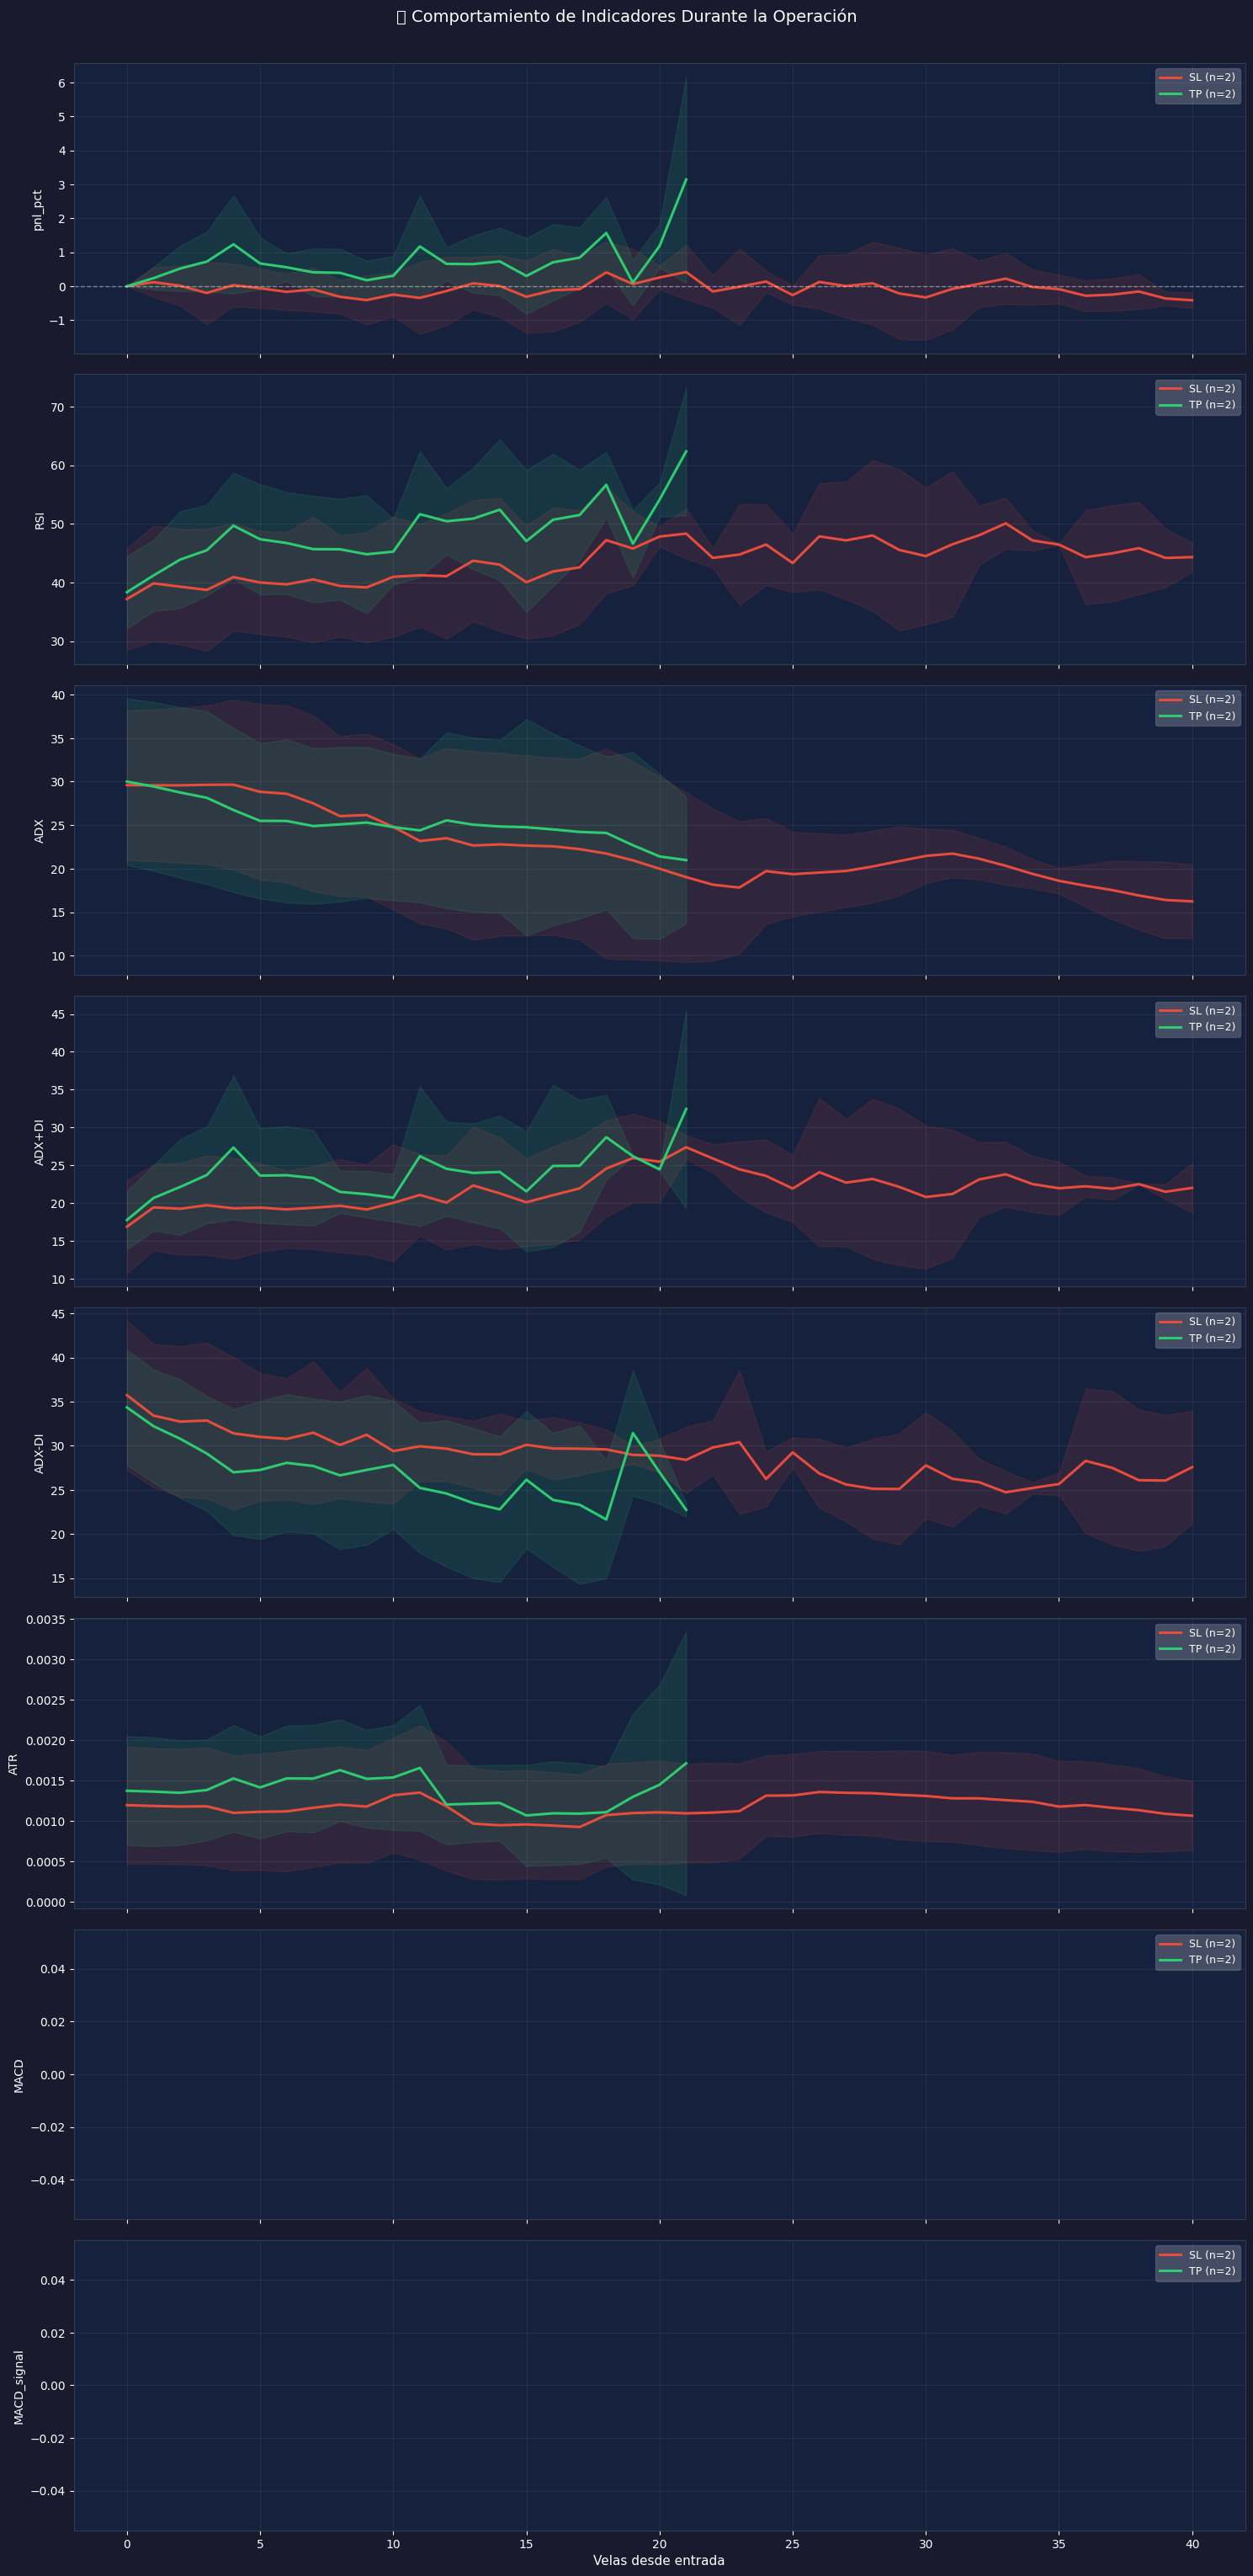

✅ Guardado: intrade_trajectories.png

✅ trade_features.csv guardado

── Ejemplo regla de salida anticipada ──
   Salir: False  |  Alertas: 1
   🔴 ADX débil (13.9 < 20.0) — tendencia perdida


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────
INDICATORS = ["RSI", "ADX", "ADX+DI", "ADX-DI", "ATR", "MACD", "MACD_signal"]  # ajusta a tus columnas
MAX_CANDLES = 60   # máximo de velas a analizar por trade
MIN_CANDLES = 3    # trades con menos velas se descartan


# ══════════════════════════════════════════════
# PASO 1 — EXTRAER TRADES desde el df principal
# ══════════════════════════════════════════════
def extract_trades(df: pd.DataFrame, direction_filter: int = None) -> pd.DataFrame:
    """
    direction_filter: 1 = solo compras, -1 = solo ventas, None = todos
    """
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values(["symbol", "time"]).reset_index(drop=True)

    trades = []

    for symbol, grp in df.groupby("symbol"):
        grp = grp.reset_index(drop=True)
        in_trade = False
        trade_candles = []
        trade_direction = None  # ← se guarda desde la vela ENTRY

        for _, row in grp.iterrows():
            state = str(row.get("state", "")).strip().upper()

            if state == "ENTRY":
                # ── La dirección se toma AQUÍ, nunca del EXIT
                signal = row.get("signal_trade")
                try:
                    trade_direction = int(signal)
                except (ValueError, TypeError):
                    trade_direction = None

                # Si hay filtro, ignorar trades que no correspondan
                if direction_filter is not None and trade_direction != direction_filter:
                    in_trade = False
                    trade_candles = []
                    trade_direction = None
                    continue

                in_trade = True
                trade_candles = [row]

            elif state == "HOLD" and in_trade:
                trade_candles.append(row)

            elif state == "EXIT" and in_trade:
                # EXIT no tiene signal_trade, pero ya tenemos trade_direction
                trade_candles.append(row)
                reason = str(row.get("reason", "UNKNOWN")).strip().upper()

                trades.append({
                    "symbol": symbol,
                    "entry_time": trade_candles[0]["time"],
                    "exit_time": row["time"],
                    "reason": reason,
                    "signal_trade": trade_direction,   # ← viene del ENTRY
                    "entry_price": trade_candles[0]["entry_price"],
                    "exit_pnl": row["pnl"],
                    "n_candles": len(trade_candles),
                    "candles": trade_candles
                })

                in_trade = False
                trade_candles = []
                trade_direction = None

    return pd.DataFrame(trades)


# ══════════════════════════════════════════════
# PASO 2 — CONSTRUIR df INTRA-TRADE (vela a vela)
# ══════════════════════════════════════════════
def build_intrade_df(df_trades: pd.DataFrame, indicators: list, max_candles: int) -> pd.DataFrame:
    """
    Explota cada trade en filas individuales por vela,
    añadiendo candle_step y pnl_pct normalizado.
    """
    records = []

    for _, trade in df_trades.iterrows():
        candles = trade["candles"][:max_candles]
        entry_price = trade["entry_price"]
        direction = trade["signal_trade"]  # 1 o -1
        reason = trade["reason"]

        for step, row in enumerate(candles):
            pnl_pct = (row["close"] - entry_price) / entry_price * 100
            if direction == -1:
                pnl_pct *= -1  # normalizar shorts: positivo = ganando

            rec = {
                "symbol": trade["symbol"],
                "reason": reason,
                "signal_trade": direction,
                "candle_step": step,
                "pnl_pct": pnl_pct,
                "close": row["close"],
            }

            # Añadir cada indicador
            for ind in indicators:
                rec[ind] = row.get(ind, np.nan)

            records.append(rec)

    return pd.DataFrame(records)


# ══════════════════════════════════════════════
# PASO 3 — FEATURES POR TRADE (para análisis de patrones)
# ══════════════════════════════════════════════
def compute_trade_features(df_trades: pd.DataFrame, df_intrade: pd.DataFrame) -> pd.DataFrame:
    """
    Para cada trade calcula estadísticas de la trayectoria
    útiles para distinguir SL vs TP desde el principio.
    """
    features = []

    for _, trade in df_trades.iterrows():
        key = (trade["symbol"], trade["entry_time"])
        grp = df_intrade[
            (df_intrade["symbol"] == trade["symbol"])
        ]
        # Filtrar por candle_step (ya están en orden por trade, usamos entry_time)
        # Reaprovechar directamente las velas del trade
        candles = trade["candles"]
        reason = trade["reason"]
        direction = trade["signal_trade"]
        entry_price = trade["entry_price"]
        n = len(candles)

        def safe_get(rows, col):
            vals = [r.get(col, np.nan) for r in rows]
            return np.array([v for v in vals if not pd.isna(v)], dtype=float)

        pnl_arr = np.array([
            ((r["close"] - entry_price) / entry_price * 100) * (1 if direction == 1 else -1)
            for r in candles
        ])

        adx_arr = safe_get(candles, "ADX")
        rsi_arr = safe_get(candles, "RSI")
        macd_arr = safe_get(candles, "MACD_hist")
        di_neg = safe_get(candles, "ADX-DI")
        di_pos = safe_get(candles, "ADX+DI")

        # ── RSI: pendiente en primeras 5 velas
        rsi_slope_5 = np.polyfit(range(min(5, len(rsi_arr))), rsi_arr[:5], 1)[0] \
                      if len(rsi_arr) >= 3 else np.nan

        # ── MACD hist: ¿cruzó a zona negativa para longs?
        if len(macd_arr) >= 2:
            if direction == 1:
                macd_flip = int(any(macd_arr[i] >= 0 and macd_arr[i+1] < 0 for i in range(len(macd_arr)-1)))
            else:
                macd_flip = int(any(macd_arr[i] <= 0 and macd_arr[i+1] > 0 for i in range(len(macd_arr)-1)))
        else:
            macd_flip = 0

        # ── ADX: caída máxima desde entrada
        adx_entry = adx_arr[0] if len(adx_arr) > 0 else np.nan
        adx_min = adx_arr.min() if len(adx_arr) > 0 else np.nan
        adx_drop = adx_entry - adx_min if not np.isnan(adx_entry) else np.nan

        # ── DI cruce adverso (DI- > DI+ en longs, DI+ > DI- en shorts)
        if len(di_neg) > 0 and len(di_pos) > 0:
            n_min = min(len(di_neg), len(di_pos))
            if direction == 1:
                adverse_cross = int(any(di_neg[i] > di_pos[i] for i in range(n_min)))
            else:
                adverse_cross = int(any(di_pos[i] > di_neg[i] for i in range(n_min)))
        else:
            adverse_cross = np.nan

        # ── PnL: máximo drawdown y candles en negativo
        max_dd = pnl_arr.min() if len(pnl_arr) > 0 else np.nan
        max_gain = pnl_arr.max() if len(pnl_arr) > 0 else np.nan
        candles_negative = int((pnl_arr < 0).sum())
        pct_negative = candles_negative / n if n > 0 else np.nan

        # ── Vela donde empezó a ir en negativo (first drawdown step)
        neg_idx = np.where(pnl_arr < 0)[0]
        first_neg_step = int(neg_idx[0]) if len(neg_idx) > 0 else n

        features.append({
            "symbol": trade["symbol"],
            "entry_time": trade["entry_time"],
            "reason": reason,
            "signal_trade": direction,
            "n_candles": n,
            "rsi_slope_5": rsi_slope_5,
            "macd_flip": macd_flip,
            "adx_entry": adx_entry,
            "adx_min": adx_min,
            "adx_drop": adx_drop,
            "adverse_di_cross": adverse_cross,
            "max_drawdown_pct": max_dd,
            "max_gain_pct": max_gain,
            "candles_negative": candles_negative,
            "pct_negative_candles": pct_negative,
            "first_neg_step": first_neg_step,
            "exit_pnl": trade["exit_pnl"],
        })

    return pd.DataFrame(features)


# ══════════════════════════════════════════════
# PASO 4 — VISUALIZACIÓN: trayectorias SL vs TP
# ══════════════════════════════════════════════
def plot_intrade_trajectories(df_intrade: pd.DataFrame, indicators: list, max_step: int = 40):
    """
    Grafica media ± std de cada indicador y el PnL%,
    separado por reason (SL / TP / REV).
    """
    cols_to_plot = ["pnl_pct"] + [i for i in indicators if i in df_intrade.columns]
    df = df_intrade[df_intrade["candle_step"] <= max_step].copy()

    reasons = sorted(df["reason"].dropna().unique())
    colors  = {"SL": "#e74c3c", "TP": "#2ecc71", "REV": "#f39c12", "UNKNOWN": "#95a5a6"}

    n_plots = len(cols_to_plot)
    fig, axes = plt.subplots(n_plots, 1, figsize=(15, 3.8 * n_plots), sharex=True,
                             facecolor="#1a1a2e")

    for ax, col in zip(axes, cols_to_plot):
        ax.set_facecolor("#16213e")

        for reason in reasons:
            sub = df[df["reason"] == reason]
            if sub.empty:
                continue
            traj = sub.groupby("candle_step")[col].agg(["mean", "std"]).dropna()
            color = colors.get(reason, "#bdc3c7")

            ax.plot(traj.index, traj["mean"], label=f"{reason} (n={sub['symbol'].nunique()})",
                    color=color, linewidth=2.2)
            ax.fill_between(traj.index,
                            traj["mean"] - traj["std"],
                            traj["mean"] + traj["std"],
                            color=color, alpha=0.12)

        if col == "pnl_pct":
            ax.axhline(0, color="white", linestyle="--", alpha=0.4, linewidth=1)

        ax.set_ylabel(col, color="white", fontsize=10)
        ax.tick_params(colors="white")
        ax.spines[["top", "right", "left", "bottom"]].set_color("#2c3e50")
        ax.legend(fontsize=9, framealpha=0.2, labelcolor="white")
        ax.grid(True, alpha=0.1)

    axes[-1].set_xlabel("Velas desde entrada", color="white", fontsize=11)
    axes[-1].tick_params(colors="white")
    fig.suptitle("📊 Comportamiento de Indicadores Durante la Operación",
                 color="white", fontsize=14, y=1.005)
    plt.tight_layout()
    # plt.savefig("intrade_trajectories.png", dpi=150, bbox_inches="tight",
    #             facecolor="#1a1a2e")
    plt.show()
    print("✅ Guardado: intrade_trajectories.png")


# ══════════════════════════════════════════════
# PASO 5 — TABLA RESUMEN DE PATRONES
# ══════════════════════════════════════════════
def print_pattern_summary(df_features: pd.DataFrame):
    """
    Muestra las métricas clave agrupadas por reason.
    """
    cols = [
        "rsi_slope_5", "macd_flip", "adx_entry", "adx_drop",
        "adverse_di_cross", "max_drawdown_pct", "max_gain_pct",
        "pct_negative_candles", "first_neg_step", "n_candles"
    ]
    cols_present = [c for c in cols if c in df_features.columns]
    summary = df_features.groupby("reason")[cols_present].agg(["mean", "median"]).round(3)

    print("\n" + "═"*70)
    print("📋 PATRONES POR RESULTADO DE TRADE")
    print("═"*70)
    print(summary.to_string())

    # Conteo
    print("\n📦 Distribución de trades:")
    print(df_features["reason"].value_counts().to_string())
    print("═"*70)


# ══════════════════════════════════════════════
# PASO 6 — REGLAS DE SALIDA ANTICIPADA (live)
# ══════════════════════════════════════════════
def should_exit_early(candles_so_far: list, direction: int,
                      adx_threshold: float = 20.0,
                      rsi_weak_long: float = 40.0,
                      rsi_weak_short: float = 60.0,
                      min_alerts: int = 2) -> dict:
    """
    Recibe la lista de velas desde la entrada hasta ahora (dicts o pd.Series).
    Retorna si conviene salir anticipadamente.

    candles_so_far : lista de rows del df (Series o dict)
    direction      : 1=long, -1=short
    """
    def g(row, col):
        try:
            v = row[col]
            return float(v) if not pd.isna(v) else np.nan
        except Exception:
            return np.nan

    alerts = []
    last = candles_so_far[-1]
    prev = candles_so_far[-2] if len(candles_so_far) >= 2 else last

    # ── 🔴 Regla 1: MACD_hist cruza contra la dirección
    hist_now  = g(last, "MACD_hist")
    hist_prev = g(prev, "MACD_hist")
    if not np.isnan(hist_now) and not np.isnan(hist_prev):
        if direction == 1 and hist_prev >= 0 and hist_now < 0:
            alerts.append("🔴 MACD_hist cruzó negativo (presión bajista en long)")
        elif direction == -1 and hist_prev <= 0 and hist_now > 0:
            alerts.append("🔴 MACD_hist cruzó positivo (presión alcista en short)")

    # ── 🔴 Regla 2: ADX por debajo del umbral (sin tendencia)
    adx_now = g(last, "ADX")
    if not np.isnan(adx_now) and adx_now < adx_threshold:
        alerts.append(f"🔴 ADX débil ({adx_now:.1f} < {adx_threshold}) — tendencia perdida")

    # ── 🔴 Regla 3: RSI en zona adversa
    rsi_now = g(last, "RSI")
    if not np.isnan(rsi_now):
        if direction == 1 and rsi_now < rsi_weak_long:
            alerts.append(f"🔴 RSI={rsi_now:.1f} < {rsi_weak_long} (débil para long)")
        elif direction == -1 and rsi_now > rsi_weak_short:
            alerts.append(f"🔴 RSI={rsi_now:.1f} > {rsi_weak_short} (débil para short)")

    # ── 🔴 Regla 4: DI cruce adverso
    di_neg = g(last, "ADX-DI")
    di_pos = g(last, "ADX+DI")
    if not np.isnan(di_neg) and not np.isnan(di_pos):
        if direction == 1 and di_neg > di_pos:
            alerts.append(f"🔴 ADX-DI({di_neg:.1f}) > ADX+DI({di_pos:.1f}) — presión bajista")
        elif direction == -1 and di_pos > di_neg:
            alerts.append(f"🔴 ADX+DI({di_pos:.1f}) > ADX-DI({di_neg:.1f}) — presión alcista")

    # ── ⚠️ Regla 5: PnL en negativo desde el inicio
    entry_price = candles_so_far[0].get("entry_price", np.nan) \
                  if isinstance(candles_so_far[0], dict) \
                  else candles_so_far[0]["entry_price"]
    close_now = g(last, "close")
    if not np.isnan(entry_price) and not np.isnan(close_now):
        pnl_pct = (close_now - entry_price) / entry_price * 100 * (1 if direction == 1 else -1)
        if pnl_pct < -1.5:
            alerts.append(f"⚠️  PnL actual = {pnl_pct:.2f}% (drawdown significativo)")

    exit_flag = len(alerts) >= min_alerts

    return {
        "exit_recommended": exit_flag,   # 🚨 True → considera salir
        "n_alerts": len(alerts),
        "alerts": alerts
    }


# ══════════════════════════════════════════════
# EJECUCIÓN COMPLETA
# ══════════════════════════════════════════════
if __name__ == "__main__":

    # ── Asume que tu df principal se llama `df`
    # df = pd.read_csv("tu_archivo.csv")   # ← carga aquí si es necesario

    print("🔍 Extrayendo trades...")
    df_trades = extract_trades(df_symbols, direction_filter=1)
    df_trades = df_trades[df_trades["n_candles"] >= MIN_CANDLES].reset_index(drop=True)
    print(f"   → {len(df_trades)} trades encontrados")
    print(df_trades["reason"].value_counts())

    print("\n📐 Construyendo df intra-trade...")
    df_intrade = build_intrade_df(df_trades, INDICATORS, MAX_CANDLES)
    print(f"   → {len(df_intrade):,} filas (velas durante operaciones)")

    print("\n🧮 Calculando features por trade...")
    df_features = compute_trade_features(df_trades, df_intrade)
    print_pattern_summary(df_features)

    print("\n📈 Graficando trayectorias...")
    plot_intrade_trajectories(df_intrade, INDICATORS, max_step=40)

    # ── Guardar features para análisis posterior
    # df_features.to_csv("trade_features.csv", index=False)
    print("\n✅ trade_features.csv guardado")

    # ── Ejemplo de uso de regla live en un trade activo
    print("\n── Ejemplo regla de salida anticipada ──")
    sample_trade = df_trades.iloc[0]
    mid_candles = sample_trade["candles"][:10]   # simula que van 10 velas
    result = should_exit_early(mid_candles, direction=sample_trade["signal_trade"])
    print(f"   Salir: {result['exit_recommended']}  |  Alertas: {result['n_alerts']}")
    for a in result["alerts"]:
        print(f"   {a}")

In [ ]:
ax.iloc[346:363, ]

In [41]:
df_symbols[(df_symbols["close"] > 278.0439) & (df_symbols["close"] < 278.043955)]

,id,time,signal_trade,close,high,low,patrimony,state,RSI,ADX,ADX+DI,ADX-DI,ATR,signal,entry_price,sl,tp,size,bars_held,entry_amount,be_price,breakeven_hit,partial_hit,pnl,reason,profit,return%,drawdown,symbol,signal2,ADX1,ADX2,ADX_diff1,ADX_diff2,ADX-DI_roll2,ADX-DI_roll3,ADX-DI_roll5,ADX+DI_roll1,ADX+DI_roll2,ADX+DI_roll3,ADX+DI_roll5,RSI1,RSI2,RSI3,RSI5,ADX-DI_roll1


In [ ]:
df_intrade.head(15)

In [42]:
ax = df_intrade[df_intrade["reason"] == "SL"]
ax.groupby(["candle_step"]).agg({"RSI":"mean", "ADX":"mean", "ADX-DI":"mean", "ADX+DI":"mean"})

,RSI,ADX,ADX-DI,ADX+DI
candle_step,,,,
0,37.184856,29.599955,35.732226,16.877516
1,39.856882,29.576086,33.421117,19.431022
2,39.293243,29.578727,32.741932,19.249021
3,38.741375,29.634302,32.862644,19.717708
4,40.927469,29.647909,31.409397,19.307146
5,40.006757,28.830820,31.005402,19.399257
6,39.688704,28.604233,30.782796,19.166410
7,40.530666,27.500782,31.486536,19.382901
8,39.418510,26.037834,30.085943,19.640321


In [ ]:
qwe

# Sacar grafico de capital, return por symbolo (serie tiempo)

In [ ]:
resume

In [ ]:
signalstester = cols_strsig[2:] # 
signalstester = ["str_macd_div1", "str_macd_div3"] # 


In [ ]:
# Backtester
resume = []
state_all = {}
count = 1
from datetime import datetime
now = datetime.now()
for name_signal in signalstester: # signals2
    print(f"{count}: {name_signal}")
    count += 1
    now_temp = datetime.now()

    capital               = 1000
    patrimony             = capital # Equity
    profit_total = 0
    loss_total = 0
    position_opened = False
    candle_trade = []
    state = []
    idx = 0
    bars_held = np.nan
    loss_streak = 0
    cooldown = 0
    n = len(df)

    df["signal"] = df[name_signal]

    for i in range(n):

        bar        = df.iloc[i]
        prev_bar   = df.iloc[i - 1]
        signal     = bar["signal"]
        high       = bar["High"]
        low        = bar["Low"]
        atr        = bar["ATR"]
        price_var  = "Close"
        price      = bar[price_var]

        # print(bar["date"])

        # COOLDOWN CONTROL
        if cooldown > 0:
            cooldown -= 1
            signal = 0  # bloquear entradas
            # print("# COOLDOWN CONTROL if cooldown > 0:")


        #-------------- 1. ENTRY
        if not position_opened and signal != 0:
            # print("#-------------- 1. ENTRY if not position_opened and signal != 0:")

            if signal == 1: 
                entry_price = price * (1 + slippage_pct)
            else:
                entry_price = price * (1 - slippage_pct)

            sl_distance = atr_sl * atr

            if signal == 1:
                stop_loss = entry_price - sl_distance
            else:
                stop_loss = entry_price + sl_distance

            tp_distance = abs(entry_price - stop_loss) * multiplier_tp

            if signal == 1:
                take_profit = entry_price + tp_distance
            else:
                take_profit = entry_price - tp_distance

            amount = patrimony * risk_per_trade
            patrimony = patrimony - amount

            risk_unit = abs(entry_price - stop_loss)
            size = amount / risk_unit
            position_value = size * entry_price
            max_position_value = amount * leverage      
            if position_value > max_position_value:
                size = max_position_value / entry_price

            # Niveles auxiliares (se calculan UNA vez en ENTRY)
            r_unit        = abs(entry_price - stop_loss)
            be_price      = entry_price + breakeven_trigger_r * r_unit * signal

            bars_held = 0

            temp = {
                "id": [idx],
                "time": [bar.name],
                "signal": [signal],
                "signal_trade": [signal],
                "close": [entry_price],
                "high": [high],
                "low": [low],
                "entry_price": [entry_price],
                "sl": [stop_loss],
                "sl_inicial":     [stop_loss],   # guardamos el SL original para calcular R
                "tp": [take_profit],
                "size": size,
                "bars_held": [bars_held],
                "entry_amount":[amount],
                "be_price":       [be_price],
                "breakeven_hit":  [False],
                "partial_hit":    [False],
                "trailing_active":[False],
                "price_prev":[prev_bar[price_var]],
                "diff":[bar[price_var] - prev_bar[price_var]],
                "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                "diff_open": [np.nan],
                "delta_open":[np.nan],  
                "patrimony": [patrimony],
                "state": ["ENTRY"],
                "RSI":[bar["RSI"]],
                "ADX":[bar["ADX"]],
                "ADX+DI":[bar["ADX+DI"]],
                "ADX-DI":[bar["ADX-DI"]],
                "ATR":[bar["ATR"]]
            }
            temp = pd.DataFrame(temp)
            state.append(temp)
            position_opened = True
            candle_trade = temp.copy()

            # print('"state": ["ENTRY"]')
            # print("position_opened = True PASS")
            pass


        #-------------- 2. MANAGE TRADE
        if position_opened:
            # print("if position_opened:")
           
            _exit        = False
            exitintrail  = False
            reason       = np.nan

            _close = bar["Close"]
            _high = bar["High"]
            _low = bar["Low"]
            _sl = candle_trade["sl"][0]
            _tp = candle_trade["tp"][0]
            _entry_amount = candle_trade["entry_amount"][0]
            _entry_price = candle_trade["entry_price"][0]
            _size = candle_trade["size"][0]        
            signal_trade    = candle_trade["signal_trade"][0]
            _sl_inicial     = candle_trade["sl_inicial"][0]
            _be_price       = candle_trade["be_price"][0]
            _breakeven_hit  = candle_trade["breakeven_hit"][0]
            _trailing_active= candle_trade["trailing_active"][0]
            _close          = bar["Close"]


            # REV CONDITION
            if signal != 0 and signal != signal_trade:
                # print("# REV CONDITION if signal != 0 and signal != signal_trade:")
                _exit = True
                reason = "REV"


            temp = candle_trade.copy()

            temp["diff_open"] = (bar[price_var] - candle_trade[price_var.lower()])[0]
            temp["delta_open"] = ((bar[price_var] - candle_trade[price_var.lower()]) /
                                candle_trade[price_var.lower()])[0]
            
            # P&L actual de la posición (sobre valor real apalancado)
            actual_pos_value = _size * _entry_price          
            delta_open       = (_close - _entry_price) / _entry_price
            pnl              = actual_pos_value * delta_open * signal_trade

            # BREAK-EVEN
            if use_breakeven and not _breakeven_hit:
                be_hit = (signal_trade ==  1 and _close >= _be_price) or \
                         (signal_trade == -1 and _close <= _be_price)
                if be_hit:
                    _sl = _entry_price
                    candle_trade["sl"]           = _sl
                    candle_trade["breakeven_hit"]= True
                    _breakeven_hit               = True

            # TRAILING STOP (solo se activa después de trailing_activation_r)
            if use_trailing_stop:
                r_unit       = abs(_entry_price - _sl_inicial)
                ganancia_en_r = abs(_close - _entry_price) / r_unit if r_unit != 0 else 0

                if ganancia_en_r >= trailing_activation_r:
                    candle_trade["trailing_active"] = True
                    _trailing_active = True

                if _trailing_active:
                    trail_dist = trailing_atr_mult * atr

                    if signal_trade == 1:                     
                        new_trail = high - trail_dist
                        if new_trail > _sl:
                            _sl = new_trail
                            candle_trade["sl"] = _sl
                            exitintrail = True
                    else:
                        new_trail = low + trail_dist
                        if new_trail < _sl:
                            _sl = new_trail
                            candle_trade["sl"] = _sl
                            exitintrail = True


            if signal_trade == 1:
                # print("if signal_trade == 1:")
                sl_hit = low <= _sl
                tp_hit = high >= _tp
                if sl_hit:
                    _exit = True
                    reason = "SL"
                    reason = "TS" if reason == "SL" and exitintrail else reason
                elif tp_hit:
                    _exit = True
                    reason = "TP"


            if signal_trade == -1:
                sl_hit = high >= _sl
                tp_hit = low <= _tp
                if sl_hit:
                    _exit = True
                    reason = "SL"
                    reason = "TS" if reason == "SL" and exitintrail else reason
                elif tp_hit:
                    _exit = True
                    reason = "TP"


            # EXIT TRADE
            if _exit and bars_held >= 1:
                # print("# EXIT TRADE if _exit and bars_held >= 1:")
                # print("bars_held", bars_held)
                # print("reason", reason)
                exit_price = _tp if reason == "TP" else _sl

                if reason == "REV":
                    exit_price = price  # cerrar al precio actual

                if signal_trade == 1:
                    _return = (exit_price - _entry_price) / _entry_price
                else:
                    _return = (_entry_price - exit_price) / _entry_price
                
                actual_position_value = _size * _entry_price          
                gross_profit = _return * actual_position_value          
                fees         = actual_position_value * fee_rate * 2       
                profit_f     = gross_profit - fees
                patrimony    += _entry_amount + profit_f


                temp = {
                    "id": [idx],
                    "time": [bar.name],
                    "close": [price],
                    "high": [high],
                    "low": [low],
                    "signal_trade":[0],
                    "price_prev":prev_bar[price_var],
                    "diff":bar[price_var] - prev_bar[price_var],
                    "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                    "patrimony": [patrimony],
                    "state":"EXIT",
                    "reason":[reason],
                    "pnl":[_entry_amount + profit_f],
                    "entry_amount":[_entry_amount],
                    "profit_ex":[profit_f],
                    "return_ex":[_return],
                    "bars_held_ex":[bars_held],
                    "RSI":[bar["RSI"]],
                    "ADX":[bar["ADX"]],
                    "ADX+DI":[bar["ADX+DI"]],
                    "ADX-DI":[bar["ADX-DI"]],
                    "ATR":[bar["ATR"]],
                    "breakeven_hit":[_breakeven_hit],
                    "be_price":[_be_price],
                    "sl":[_sl],
                    "tp":[_tp],
                    
                }
                # print('"state":"EXIT"')

                temp = pd.DataFrame(temp)
                state.append(temp)

                _exit = False
                position_opened = False
                candle_trade = []

                pass

            # 3. IF NOT EXIT -> HOLD AND UPDATE
            else:
                temp = candle_trade.copy()
                temp["id"] = idx
                temp["signal"] = np.nan
                temp["close"] = price
                temp["high"] = high
                temp["low"] = low
                temp["time"] = bar.name
                temp["bars_held"] = [bars_held]
                temp["price_prev"] = prev_bar[price_var]
                temp["diff"] = bar[price_var] - prev_bar[price_var]
                temp["delta"] = (bar[price_var] - prev_bar[price_var]) / prev_bar[price_var]
                temp["diff_open"] = (bar[price_var] - candle_trade[price_var.lower()])[0]
                temp["delta_open"] = ((bar[price_var] - candle_trade[price_var.lower()]) / candle_trade[price_var.lower()])[0]
                temp["patrimony"] = patrimony
                temp["state"] = "HOLD"
                temp["pnl"] = pnl
                temp["RSI"] = bar["RSI"]
                temp["ADX"] = bar["ADX"]
                temp["ADX+DI"] = bar["ADX+DI"]
                temp["ADX-DI"] = bar["ADX-DI"]
                temp["ATR"] = bar["ATR"]
                temp["breakeven_hit"] = _breakeven_hit
                temp["be_price"] = _be_price

                state.append(temp)
                # print('temp["state"] = "HOLD"')

                pass


        # 5. IF NOT SIGNAL AND TRADE OPENED -> HOLD 
        if not position_opened and signal == 0:
            temp = {
                "id": [idx],
                "time": [bar.name],
                "signal_trade": [signal],
                "close": [price],
                "high": [high],
                "low": [low],
                "price_prev":prev_bar[price_var],
                "diff":bar[price_var] - prev_bar[price_var],
                "delta":[(bar[price_var] - prev_bar[price_var])/prev_bar[price_var]],
                "patrimony": [patrimony],
                "state":"NO SIGNAL",
                "RSI":[bar["RSI"]],
                "ADX":[bar["ADX"]],
                "ADX+DI":[bar["ADX+DI"]],
                "ADX-DI":[bar["ADX-DI"]],
                "ATR":[bar["ATR"]]
            }
            temp = pd.DataFrame(temp)
            state.append(temp)

            # print('"state":"NO SIGNAL"')
            pass

        bars_held += 1
        idx += 1
        # print("="*120)


    state = pd.concat(state)
    state.drop_duplicates("time", inplace = True) # Ajustar

    # Devolviendo capital invertido a la ultima vela si finalizando se tiene una operacion abierta y esta no cerró
    last = state.iloc[-1]
    indeter_signal = False
    if last["state"] == "HOLD":
        indeter_signal = True
        state["patrimony"] = np.where(state["id"] == last["id"], state["patrimony"] + state["entry_amount"], state["patrimony"])

    if "profit_ex" not in state:
        state["profit_ex"] = np.nan
    if "return_ex" not in state:
        state["return_ex"] = np.nan

    state["profit"] = state["pnl"] - state["entry_amount"]
    state["return%"] = state["profit"] / state["entry_amount"]
    state["profit"] = np.where(state["state"] == "EXIT", state["profit_ex"], state["profit"])
    state["return%"] = np.where(state["state"] == "EXIT", state["return_ex"], state["return%"])
    state["peak"] = state["patrimony"].cummax()
    state["drawdown"] = (state["patrimony"] - state["peak"]) / state["peak"]
    exits = state[state["state"] == "EXIT"].copy()

    returns = state.loc[state["state"] == "EXIT", "return%"].dropna()
    returns_pct = exits["return%"]

    if len(returns) > 1 and returns.std() != 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(len(returns))
    else:
        sharpe = np.nan

    max_dd = state["drawdown"].min()

    capital_f = state["patrimony"].iloc[-1]
    pnl_f = capital_f - capital
    return_f = ((capital_f / capital) - 1)*100
    exits["return%"] = exits["return%"]*100
    n_trades = exits.shape[0] if not indeter_signal else exits.shape[0] - 1
    win_rate = (exits[(exits["profit"] > 0)].shape[0] / n_trades)*100
    days = (state["time"].max() - state["time"].min()) / pd.Timedelta(days=1)
    downside = exits["return%"]
    downside = downside[downside < 0]
    sortino = (exits["return%"].mean() / downside.std()) * np.sqrt(24*365) 
    gains = exits[exits["profit"] > 0]
    loss = exits[exits["profit"] < 0]
    exits["time_t1"] = exits["time"].shift(1)
    exits["diff_time"] = (exits["time"] - exits["time_t1"]) / pd.Timedelta(days=1)
    cagr   = ((capital_f / capital) ** (365 / max(days, 1)) - 1) * 100
    calmar = cagr / abs(max_dd * 100) if max_dd != 0 else np.nan
    win_rate_dec = len(gains) / n_trades if n_trades > 0 else 0
    max_loss_streak, cur_streak = 0, 0
    for s in exits["profit"]:
        cur_streak      = cur_streak + 1 if s < 0 else 0
        max_loss_streak = max(max_loss_streak, cur_streak)
    max_gain_streak, cur_streak = 0, 0
    for s in exits["profit"]:
        cur_streak      = cur_streak + 1 if s > 0 else 0
        max_gain_streak = max(max_gain_streak, cur_streak)
    hold_bars  = state[state["state"] == "HOLD"].shape[0]
    exposure   = hold_bars / len(state) * 100
    var_95  = np.percentile(returns_pct, 5)  if len(returns_pct) > 0 else np.nan
    cvar_95 = returns_pct[returns_pct <= var_95].mean() if len(returns_pct) > 0 else np.nan
    recovery_factor = pnl_f / abs(max_dd * capital) if max_dd != 0 else np.nan
    n_sl = exits[exits["reason"] == "SL"].shape[0]
    n_tp = exits[exits["reason"] == "TP"].shape[0]
    n_ts = exits[exits["reason"] == "TS"].shape[0]

    print("─────────────── Symbol ──────────────")
    print(f"               {symb}")

    print("\n───────── Time and Candles ──────────")
    print("Candles:", f"{len(df)} | Days: {int(days)}") # {window}
    print("Trades:           ", n_trades, f"| Wins: {len(gains)} | Loss: {len(loss)}")
    print("Trades/day:       ", f"{(n_trades/days):.1f}")
    print("Time/trade:       ", f"Mean: {exits["bars_held_ex"].mean():.0f} | Min: {exits["bars_held_ex"].min():.0f} | Max: {exits["bars_held_ex"].max():.0f}")
    print("Time inter trades:", f"Mean: {exits["diff_time"].mean():.0f} | Min: {exits["diff_time"].min():.0f} | Max: {exits["diff_time"].max():.0f}")

    print("\n─────────── Final Results ───────────")
    print("Win rate:         ", f"{win_rate:.0f}%")
    print("Capital initial:  ", f"${capital}")
    print("Capital final:    ", f"${capital_f:.1f}")
    print("PnL:              ", f"${pnl_f:.1f}")
    print("Return:           ", f"{(return_f):.1f}%")
    print("Max drawdown:     ", f"{max_dd:.1%}\n")

    print("Sharpe:           ", f"{sharpe:.1f}")
    print("Sortino:          ", f"{sortino:.0f}")
    print("Calmar:           ", f"{calmar:.0f}")
    print("CAGR:             ", f"{cagr:.0f}\n")

    print("Total gains:      ", f"${gains["profit"].sum():.0f}")
    print("Total loss:       ", f"${loss["profit"].sum():.0f}")
    print(" ")
    print("Return/trade:     ", f"Mean: {exits["return%"].mean():.0f}% | Min: {exits["return%"].min():.0f}% | Max: {exits["return%"].max():.0f}%")
    print("Profit/trade:     ", f"Mean: ${exits["profit"].mean():.1f} | Min: ${exits["profit"].min():.1f} | Max: ${exits["profit"].max():.1f}")

    print("\n─────────── Metrics Risk ───────────") # Risk:Reward Ratio
    exits["return_on_margin"] = exits["profit"] / exits["entry_amount"] * 100 # Retorno promedio real sobre margen (no sobre precio)
    avg_win = exits[exits['profit']>0]['return%'].mean()
    avg_loss = exits[exits['profit']<0]['return%'].mean()
    avg_win_margin = exits[exits['profit']>0]['return_on_margin'].mean()
    avg_loss_margin = exits[exits['profit']<0]['return_on_margin'].mean()
    loss_rate = 1 - win_rate   
    expectancy = (win_rate_dec * avg_win) - (loss_rate * avg_loss)
    # expectancy = (win_rate * avg_win) - (loss_rate * avg_loss) # Para ser rentable que sea > 0. Te dice cuánto esperas ganar o perder por operación, en 
    # expectancy = win_rate_dec * avg_win + (1 - win_rate_dec) * avg_loss
    # promedio. Expectancy = ganancia promedio por trade
    # prom_fee = exits['entry_amount'].mean() * leverage * fee_rate * 2
    prom_fee = exits['entry_amount'].mean() * fee_rate * 2 * leverage
    # → solo es correcto si size siempre alcanza el límite de leverage,
    #   lo cual con leverage=100 casi siempre ocurre. Verificar con:
    print(f"Prom Position Value:${exits['entry_amount'].mean() * leverage:.0f} (with leverage)")
    print(f"Prom Position Value:${exits['entry_amount'].mean():.0f} (without leverage)")

    print(f"Expectancy:         {expectancy:.1f}")
    print(f"Avg win (price):    {avg_win:.1f}%")
    print(f"Avg loss (price):   {avg_loss:.1f}%\n")

    print(f"Ratio W/L:          {abs(avg_win / avg_loss):.1f}x | Gain prom = {abs(avg_win / avg_loss):.1f} x Loss") # en promedio cada ganancia es 2.6 veces más grande que cada pérdida.
    print(f"Recovery factor:    {recovery_factor:.2f}")
    print(f"VaR 95%:            {var_95:.1f}%")
    print(f"CVaR 95%:           {cvar_95:.1f}%\n")

    print(f"Max racha loss:     {max_loss_streak:.0f}")
    print(f"Max racha gain:     {max_gain_streak:.0f}\n")

    print(f"Closed x TP:        {n_tp} ({n_tp/n_trades*100:.0f}%)")
    print(f"Closed x SL:        {n_sl} ({n_sl/n_trades*100:.0f}%)")
    print(f"Closed x TS:        {n_ts} ({n_ts/n_trades*100:.0f}%)\n")

    print(f"Avg win (margin):   {avg_win_margin:.0f}%")
    print(f"Avg loss (margin):  {avg_loss_margin:.0f}%\n")

    print(f"Fees estim/trade:   ${prom_fee:.1f}")
    print(f"Total fees estim:   ${prom_fee * n_trades:.0f}")
    print(f"Fees as %avg_win:   {prom_fee / exits[exits['profit']>0]['profit'].mean() * 100:.0f}%\n")


    resume.append(pd.DataFrame({"symbol":[symb], "signal":[name_signal], "capital":[capital_f], "win_rate":[win_rate], "pnl":[pnl_f], "return":[return_f], 
                            "trades":[n_trades], "tradesxday":[n_trades/days], "drawdown":[max_dd], "sharpe":[max_dd], "sharpe":[sharpe], "ratio_wl":[abs(avg_win / avg_loss)],
                            "total_gains":[gains["profit"].sum()], "total_loss":[loss["profit"].sum()], "mean_timextrade":[exits["bars_held_ex"].mean()],
                            "mean_profit":[exits["profit"].mean()], "min_profit":[exits["profit"].min()],"max_profit":[exits["profit"].mean()],
                            "mean_position":[exits['entry_amount'].mean() * leverage], "expectancy":[expectancy], "recov_factor":[recovery_factor], "max_rach_loss":[max_loss_streak],
                            "max_rach_gain":[max_gain_streak], "close_tp":[n_tp/n_trades*100], "close_sl":[n_sl/n_trades*100],"close_ts":[n_ts/n_trades*100],
                            "mean_fees":[prom_fee], "total_fees":[prom_fee * n_trades], "param.atr_sl":[atr_sl], "param.multiplier_tp":[multiplier_tp], 
                            "param.trailing_atr_mult":[trailing_atr_mult], "param.use_trailing_stop":[use_trailing_stop], "param.use_breakeven":[use_breakeven],
                            "param.trailing_activation_r":[trailing_activation_r], "param.breakeven_trigger_r":[breakeven_trigger_r],
                            "param.use_r_tp":[use_r_tp], "param.factor_r_tp":[factor_r_tp],
                            }))

    state.drop(columns = ["diff_open", "price_prev", "diff", "delta", "profit_ex", "return_ex", "peak", "bars_held_ex", "delta_open",# "be_price", "breakeven_hit",
                        "trailing_active", "sl_inicial"], inplace =True)
    state2 = state.copy()
    state_all.update({name_signal:state})

    print("="*120)
    print("="*120, "\n")

print(f"Duration all: {datetime.now() - now}")
resume = pd.concat(resume).sort_values("capital", ascending = False)

In [ ]:
save = True
state[state["state"] == "EXIT"]["reason"].value_counts(normalize = True, dropna = False)*100

In [ ]:
# Resume of the all strategies
pd.set_option('display.max_rows', 100)
print(f"Capital      : ${resume["capital"].min():.0f} | ${resume["capital"].max():.0f} | ${resume["capital"].mean():.0f}")
print(f"Win rate     : {resume["win_rate"].min():.0f}% | {resume["win_rate"].max():.0f}% | {resume["win_rate"].mean():.0f}%")
print(f"PnL          : ${resume["pnl"].min():.0f} | ${resume["pnl"].max():.0f} | ${resume["pnl"].mean():.0f}")
print(f"Return       : {resume["return"].min():.0f}% | {resume["return"].max():.0f}% | {resume["return"].mean():.0f}%")
print(f"Trades       : {resume["trades"].min():.0f} | {resume["trades"].max():.0f} | {resume["trades"].mean():.0f}")
print(f"Trades x Day : {resume["tradesxday"].min():.1f} | {resume["tradesxday"].max():.1f} | {resume["tradesxday"].mean():.1f}")
print(f"Max rach gain: {resume["max_rach_gain"].min():.0f} | {resume["max_rach_gain"].max():.0f} | {resume["max_rach_gain"].mean():.0f}")
print(f"Max rach loss: {resume["max_rach_loss"].min():.0f} | {resume["max_rach_loss"].max():.0f} | {resume["max_rach_loss"].mean():.0f}")
resume["atr_sl"] = atr_sl
resume["multiplier_tp"] = multiplier_tp
resume["trailing_atr_mult"] = trailing_atr_mult
resume["use_trailing_stop"] = use_trailing_stop
resume["trailing_activation_r"] = trailing_activation_r
resume["breakeven_trigger_r"] = breakeven_trigger_r
if save:
    resume.to_parquet(f"results/{symb}.parquet")
    state.to_parquet(f"df_symbol/{symb}.parquet")

In [ ]:
resume.head(15)

In [ ]:
print(resume[resume["pnl"] > 2]["signal"].tolist())

In [ ]:
state2 = state_all["str_macd_div1"]
state2["EMA"] = state2["close"].rolling(window = 200).mean()
state2["EMA2"] = state2["close"].rolling(window = 50).mean()
state2["std"] = state2["close"].rolling(20).std()
state2["bb_low"] = state2["close"] - 2*state2["std"]
state2["bb_upper"] = state2["close"] + 2*state2["std"]
state2["close_exit"] = np.where((state2["state"] == "EXIT") & (state2["reason"] == "TP"), state2["tp"].shift(1), 
                      np.where((state2["state"] == "EXIT") & (state2["reason"] == "SL"), state2["sl"].shift(1), state2["close"]))

idx = [300, 1500, "2025-01-28", 150]
state = state2.copy().iloc[idx[0]:idx[1],]
# state = state[state["time"] >= idx[2]].head(idx[3])
# state = state2.copy().iloc[0:int(len(state)/5),]
print(state.shape)

In [ ]:
state.head(5)

In [ ]:
df[["str_macd_div1", "str_macd_div3", "str_macd_div5"]].value_counts()

In [ ]:
# Price
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
titlesize = 10
edgecolor = "#A3B0C4"
colorlines = "#398bae"

state.index = state["time"]
state["std"] = state["close"].rolling(20).std()
state["bb_low"] = state["close"] - 2*state["std"]
state["bb_upper"] = state["close"] + 2*state["std"]
state["MACD_hist"] = df["MACD_hist"]
state["MACD_signal"] = df["MACD_signal"]
state["MACD"] = df["MACD"]

state["time"] = pd.to_datetime(state["time"])
state["Close"] = state["close"]
sell = state[state["signal"] == -1]
buy  = state[state["signal"] ==  1]
exits = state.copy()
exits = exits[exits["state"] == "EXIT"]

# fig, ax = plt.subplots(figsize=(16, 5))
fig, (ax1, ax5, ax2, ax3, ax4) = plt.subplots(
    5, 1,
    figsize=(15, 7.4),
    sharex=True,
    gridspec_kw={'height_ratios': [1.8, 0.35, 0.35, 0.22, 0.2]}  
)
color_back = "#0d1117"
fig.patch.set_facecolor(color_back)

ax1.set_facecolor(color_back)
ax1.plot(state["time"], state["Close"], color="#ffffff", linewidth=1.1, zorder=2, alpha = 0.8)
# ax1.plot(state["time"], state["high"], color="#184157", linewidth=1.1, zorder=2)
# ax1.plot(state["time"], state["low"], color="#18445c", linewidth=1.1, zorder=2)

# # EMAS
# ax1.plot(state["time"], state["EMA"], color="#610871", linewidth=1, zorder=2, linestyle = "-", label = "EMA200")
# ax1.plot(state["time"], state["EMA2"], color="#6F4C0C", linewidth=1, zorder=2, linestyle = "-", label = "EMA50")
# # Bollinger
# ax1.plot(state["time"], state["bb_low"], color="#143868", linewidth=1, zorder=2, linestyle = "--")
# ax1.plot(state["time"], state["bb_upper"], color="#143868", linewidth=1, zorder=2, linestyle = "--")

# SL
if "sl" in state.columns:
    sl_data = state
    ax1.plot(sl_data["time"], sl_data["sl"], color="#ef4444", linewidth=1.1, alpha = 0.8, linestyle="-", zorder=3)#, marker = "o", markersize = 1)

# TP
if "tp" in state.columns:
    tp_data = state
    ax1.plot(tp_data["time"], tp_data["tp"], color="#44ef52", linewidth=1.1, alpha = 0.8, linestyle="-", zorder=3)

# Sell signals
if not sell.empty:
    # ax1.scatter(sell["time"], sell["Close"], color="#f87171", s=45, zorder=5, edgecolors="white", linewidths=1.1)
    for _, row in sell.iterrows():
        ax1.annotate("▼", xy=(row["time"], row["Close"]), xytext=(0, 0),  zorder=6, textcoords="offset points", ha="center", fontsize=11.5, color="#f87171", fontweight="bold")

# Buy signals
if not buy.empty:
    # ax1.scatter(buy["time"], buy["Close"], color="#4ade80", s=45, zorder=5, edgecolors="white", linewidths=1.1)
    for _, row in buy.iterrows():
        ax1.annotate("▲", xy=(row["time"], row["Close"]), xytext=(0, 0),  zorder=6, textcoords="offset points", ha="center", fontsize=11.5, color="#4ade80", fontweight="bold")

if not exits.empty:
    for _, row in exits.iterrows():
        if row["reason"]  == "SL":
            _reas = "SL"
        elif row["reason"] == "TP":
            _reas = "TP"
        elif row["reason"] == "TS": 
            _reas = "TS"
        elif row["reason"] == "REV":
            _reas = "RE"

        if row["return%"] > 0:
            color = "#43d75f"
        if row["return%"] < 0:
            color = "#e96161"

        # ax1.annotate(t, xy=(row["time"], row["Close"]*0.995), xytext=(0, 30), textcoords="offset points", ha="center", fontsize=11, color=color, fontweight="bold")
        ax1.annotate(f"{row["return%"]*100:.0f}%", xy=(row["time"], row["close_exit"]*0.995), xytext=(-5, 30), textcoords="offset points", ha="center", fontsize=8.8, 
                    color=color, fontweight="bold")
        
        ax1.annotate(_reas, xy=(row["time"], row["close_exit"]*0.995), xytext=(-5, 40), textcoords="offset points", ha="center", fontsize=7.1, 
                    color="#94a3b8", fontweight="bold")
        
    ax1.scatter(exits["time"], exits["close_exit"], color="#D3C90F", s=38, zorder=5, marker = "D", edgecolors=color_back, linewidths=1.2, label="")
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor(edgecolor)

ax1.grid(False)
ax1.set_title("", color="#e2e8f0", fontsize=13, fontweight="bold", pad=14)
# ax1.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax1.set_ylabel("Precio (USDT)", color="#64748b", fontsize=10, labelpad=8)
_min = min(state["sl"].min(), state["tp"].min(), state["Close"].min())*0.989
_max1 = max(state["sl"].max(), state["tp"].max(), state["Close"].max())*1.011
ax1.set_ylim(_min, _max1)
# plt.legend(loc = "upper right", fontsize = 7, framealpha = 0.3, labelcolor = "white", frameon = True, handlelength=3.5, handleheight=1)



# MACD

# fig, ax5 = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax5.set_facecolor(color_back)

colors = ["#22c55e" if x >= 0 else "#ef4444" for x in state["MACD_hist"]]
ax5.bar(state["time"], state["MACD_hist"]*1.95, color=colors, width=0.05, alpha=1, zorder=1, label="Histograma")

ax5.plot(state["time"], state["MACD"], color=colorlines, linewidth=1.5, zorder=3, label="MACD")
ax5.plot(state["time"], state["MACD_signal"], color="#b79030", linewidth=1.2, zorder=4, label="Signal")

ax5.axhline(0, color="#FFFFFF", linewidth=1, linestyle="--", zorder=2, alpha = 0.5) 
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax5.spines.values():
    spine.set_edgecolor(edgecolor)
ax5.grid(False) 
ax5.set_ylabel("MACD", color="#64748b", fontsize=10)



# ADX
profitcum = state
# fig, ax2 = plt.subplots(figsize=(16, 1.5))
fig.patch.set_facecolor(color_back)
ax2.set_facecolor(color_back)
ax2.plot(profitcum["time"], profitcum["ADX"], color=colorlines, linewidth=1,  zorder=2)
ax2.plot(profitcum["time"], profitcum["ADX+DI"], color="#4ade80", linewidth=1,  zorder=2)
ax2.plot(profitcum["time"], profitcum["ADX-DI"], color="#ff7041", linewidth=1,  zorder=2)
ax2.axhline(20, color="#ffffff", linewidth=1, linestyle="--",zorder=2, alpha = 0.5)
ax2.axhline(40, color="#ffffff", linewidth=1, linestyle="--",zorder=2, alpha = 0.5)
# ax2.xax2is.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax2.xax2is.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor(edgecolor)

ax2.grid([])
# ax2.set_title("ADX", color="#e2e8f0", fontsize=10, fontweight="bold", pad=14)
# ax2.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax2.set_ylabel("ADX", color="#64748b", fontsize=10, labelpad=8)
ax2.set_ylim(0, 70)


# RSI
profitcum = state
# fig, ax3 = plt.subplots(figsize=(16, 1.5))
fig.patch.set_facecolor(color_back)
ax3.set_facecolor(color_back)
ax3.plot(profitcum["time"], profitcum["RSI"], color=colorlines, linewidth=1,  zorder=2)
ax3.axhline(30, color="#ffffff", linewidth=1, linestyle="--",zorder=2, alpha = 0.5)
ax3.axhline(70, color="#ffffff", linewidth=1, linestyle="--",zorder=2, alpha = 0.5)
# ax3.xax3is.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax3.xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax3.spines.values():
    spine.set_edgecolor(edgecolor)
ax3.grid([])
# ax3.set_title("RSI", color="#e2e8f0", fontsize=10, fontweight="bold", pad=14)
# ax3.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax3.set_ylabel("RSI", color="#64748b", fontsize=10, labelpad=8)
ax3.set_ylim(0, 100)


# Slope
profitcum = state.copy()
profitcum["profitcum"] = profitcum["close"].rolling(20).mean()
profitcum["profitcum"] = profitcum["profitcum"].diff()
# profitcum["returncum"] = profitcum["return%"].cumsum()
# fig, ax4 = plt.subplots(figsize=(16, 2.2))
fig.patch.set_facecolor(color_back)
ax4.set_facecolor(color_back)
ax4.plot(profitcum["time"], profitcum["profitcum"], color=colorlines, linewidth=1,zorder=2)

ax4.axhline(0, color="#ffffff", linewidth=1, linestyle="--",zorder=2, alpha = 0.5)
# ax4.xax4is.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax4.xax4is.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax4.spines.values():
    spine.set_edgecolor(edgecolor)
ax4.grid([])
# ax4.set_title("Profit Acum $", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax4.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax4.set_ylabel("Slope $", color="#64748b", fontsize=10, labelpad=8)
# ax4.set_ylim(_min, _max4)

for ax in [ax1, ax2, ax3]:
    ax.tick_params(axis='y', colors="#94a3b8")
    # ax.tick_params(axis='x', colors="#94a3b8")
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()



In [ ]:
# t30m = yf.download(
#     symb,
#     period=f"{200}d",
#     interval="1h",
#     progress=False,
#     auto_adjust=True,
# )

# if isinstance(t30m.columns, pd.MultiIndex):
#     t30m.columns = t30m.columns.get_level_values(0)

# t30m["RSI"] = calc_rsi(t30m["Close"], RSI_PERIOD)
# t30m[t30m.index >= "2025-10-27"].head(30)
# t30m.head(50).plot(y="Close", figsize=(18, 4), title=f"{symb} Price")

In [ ]:
heightplots = 1.9
# Equity
state["Close"] = state["patrimony"]
sell = state[state["signal"] == -1]
buy  = state[state["signal"] ==  1]
fig, ax = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(state["time"], state["Close"], color="#38bdf8", linewidth=1.7, zorder=2, label="Close Price")
ax.axhline(capital, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Equity", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Equity", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylim(state["Close"].min()*0.993, state["Close"].max()*1.01)
plt.tight_layout()
plt.show()



# Profit Acum
exits = state.copy()
profitcum = exits[exits["state"] == "EXIT"]
profitcum = profitcum[["time", "profit", "return%", "reason"]]
profitcum["profitcum"] = profitcum["profit"].cumsum()
# profitcum["returncum"] = profitcum["return%"].cumsum()
fig, ax = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(profitcum["time"], profitcum["profitcum"], color="#38bdf8", linewidth=1.4, marker = "o", markersize = 2.5, zorder=2)

nfactor = 5
lista = [x for x in range(len(profitcum)) if x % nfactor == 0]

for _, row in profitcum.iloc[lista].iterrows():
    if row["profitcum"] > 0: # row["reason"]  == "TP":
        color = "#4ade80"
        ypos = 8
    else:
        color = "#ff7041"
        ypos = -11
    ax.annotate(f"{row["profitcum"]:.0f}", xy=(row["time"], row["profitcum"]), xytext=(0, ypos), textcoords="offset points", ha="center", fontsize=7, color=color, fontweight="bold")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
plt.annotate(f"${profitcum["profitcum"].iloc[-1]:.1f}", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 11,
             weight = "bold", color = "#c5d6f1")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Profit Acum $", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Profit $", color="#64748b", fontsize=10, labelpad=8)
_min = profitcum["profitcum"].min()*1.8
_max = profitcum["profitcum"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()



# Returns acum
# profitcum = exits[["time", "profit", "return%", "reason"]]
profitcum["return%"] = profitcum["return%"]*100
profitcum["profitcum"] = profitcum["return%"].cumsum()
fig, ax = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(profitcum["time"], profitcum["profitcum"], color="#38bdf8", linewidth=1.4, marker = "o", markersize = 2.5, zorder=2)

lista = [x for x in range(len(profitcum)) if x % nfactor == 0]

for _, row in profitcum.iloc[lista].iterrows():
    if row["profitcum"] > 0: # row["reason"]  == "TP":
        color = "#4ade80"
        ypos = 8
    else:
        color = "#ff7041"
        ypos = -11
    ax.annotate(f"{row["profitcum"]:.0f}", xy=(row["time"], row["profitcum"]), xytext=(0, ypos), textcoords="offset points", ha="center", fontsize=7, color=color, fontweight="bold")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
plt.annotate(f"{profitcum["profitcum"].iloc[-1]:.1f}%", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 11,
             weight = "bold", color = "#c5d6f1")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Return acum %", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Return %", color="#64748b", fontsize=10, labelpad=8)
_min = profitcum["profitcum"].min()*1.8
_max = profitcum["profitcum"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()


# Returns
fig, ax = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
exits = state[state["state"] == "EXIT"]
exits["return%"] = exits["return%"]*100
ax.plot(exits["time"], exits["return%"], color="#38bdf8", linewidth=1.4, marker = "o", markersize = 2.5, zorder=2)

lista = [x for x in range(len(exits)) if x % nfactor == 0]

for _, row in exits.iloc[lista].iterrows():
    if row["reason"]  == "TP":
        color = "#4ade80"
        ypos = 8
    if row["reason"]  == "SL":
        color = "#ff7041"
        ypos = -11
    ax.annotate(f"{row["return%"]:.1f}", xy=(row["time"], row["return%"]), xytext=(0, ypos), textcoords="offset points", ha="center", fontsize=7, color=color, fontweight="bold")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Return %", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Return %", color="#64748b", fontsize=10, labelpad=8)
_min = exits["return%"].min()*1.8
_max = exits["return%"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()



# Entry amount
exits = state.copy()
exits["entry_amount"] = exits["entry_amount"].shift(1)
profitcum = exits[exits["state"] == "EXIT"]
profitcum["profitcum"] = profitcum["entry_amount"]
# profitcum["returncum"] = profitcum["return%"].cumsum()
fig, ax = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
ax.plot(profitcum["time"], profitcum["profitcum"], color="#38bdf8", linewidth=1.4, marker = "o", markersize = 2.5, zorder=2)

lista = [x for x in range(len(profitcum)) if x % nfactor == 0]

for _, row in profitcum.iloc[lista].iterrows():
    ax.annotate(f"{row["profitcum"]:.0f}", xy=(row["time"], row["profitcum"]), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=7, color="#4ade80", fontweight="bold")
# ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
# plt.annotate(f"${profitcum["profitcum"].iloc[-1]:.1f}", xy=(1, 1), xycoords="axes fraction", xytext=(0, 16), textcoords="offset points", ha="right", va="top", fontsize = 11,
#              weight = "bold", color = "#c5d6f1")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
prom = profitcum["profitcum"].mean()
plt.annotate(f"prom: ${prom:.0f}", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 10, weight = "bold", 
             color = "#c5d6f1")
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Entry amount $", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Amount $", color="#64748b", fontsize=10, labelpad=8)
_min = profitcum["profitcum"].min()*1.8
_max = profitcum["profitcum"].max()*1.35
# ax.set_ylim(_min, _max)
plt.tight_layout()
plt.show()



# Drawdown
fig, ax = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
drawd = state.copy()
drawd["drawdown"] = drawd["drawdown"]*100
ax.plot(drawd["time"], drawd["drawdown"], color="#38bdf8", linewidth=1.1, zorder=2, label="Close Price")
ax.axhline(0, color="#ffffff", linewidth=1.4, linestyle="--",zorder=2)
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
ax.set_title("Drawdown %", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylabel("Drawdown %", color="#64748b", fontsize=10, labelpad=8)
ax.set_ylim(drawd["drawdown"].min()*1.2, max(drawd["drawdown"].max()*1.1, 0.2))
plt.tight_layout()
plt.show()


# Hist returns
fig, ax = plt.subplots(figsize=(6.5, 3.4))
fig.patch.set_facecolor(color_back)
ax.set_facecolor(color_back)
exits = state[state["state"] == "EXIT"]
returns = (exits["return%"]*100)
plt.hist(returns, color="#38bdf8", density=True, bins = 25, edgecolor = color_back, linewidth = 4)
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
plt.axvline(np.mean(returns), linestyle = "--", color = "white")
plt.annotate(f"{np.mean(returns):.1f}%", xy=(1, 1), xycoords="axes fraction", xytext=(-0, 16), textcoords="offset points", ha="right", va="top", fontsize = 10, weight = "bold", 
             color = "#c5d6f1")
for spine in ax.spines.values():
    spine.set_edgecolor("#1e293b")
ax.grid([])
plt.title("Returns %", color = "#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

In [ ]:
# ATR
heightplots = 1.4
temp = df.copy()
temp = temp.reset_index().rename(columns = {"Datetime":"time"})
temp = temp.iloc[idx[0]:idx[1],]
temp = temp[temp["time"] >= idx[2]].head(idx[3])

fig, ax6 = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax6.set_facecolor(color_back)

ax6.plot(temp["time"], temp["ATR"], color="#38bdf8", linewidth=1,zorder=2)
ax6.axhline(temp["ATR"].mean(), color="#5D4949", linewidth=1, linestyle="--",zorder=1)
# ax4.xax4is.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax4.xax4is.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax6.spines.values():
    spine.set_edgecolor("#1e293b")
ax6.grid([])
# ax4.set_title("Profit Acum $", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax4.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax6.set_ylabel("ATR", color="#64748b", fontsize=10, labelpad=8)
# ax4.set_ylim(_min, _max4)
plt.tight_layout()
plt.show()



# OBV
temp = df.copy()
temp = temp.reset_index().rename(columns = {"Datetime":"time"})
temp = temp.iloc[idx[0]:idx[1],]
temp = temp[temp["time"] >= idx[2]].head(idx[3])

fig, ax7 = plt.subplots(figsize=(16, heightplots))
fig.patch.set_facecolor(color_back)
ax7.set_facecolor(color_back)

ax7.plot(temp["time"], temp["OBV"], color="#38bdf8", linewidth=1,zorder=2)
# ax7.axhline(temp["ATR"].mean(), color="#5D4949", linewidth=1, linestyle="--",zorder=1)
# ax4.xax4is.set_major_formatter(mdates.DateFormatter("%H:%M"))
# ax4.xax4is.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=0, color="#94a3b8", fontsize=9)
plt.yticks(color="#94a3b8", fontsize=9)
for spine in ax7.spines.values():
    spine.set_edgecolor("#1e293b")
ax7.grid([])
# ax4.set_title("Profit Acum $", color="#e2e8f0", fontsize=titlesize, fontweight="bold", pad=14)
# ax4.set_xlabel("Hora (UTC)", color="#64748b", fontsize=10, labelpad=8)
ax7.set_ylabel("OBV", color="#64748b", fontsize=10, labelpad=8)
# ax4.set_ylim(_min, _max4)
plt.tight_layout()
plt.show()

In [ ]:
df.sample(10)

In [ ]:
qwe

In [ ]:
state2

## Results

In [ ]:
import os
p = os.listdir(os.getcwd() + "/results")
resall = []
resall_full = []
for i in p:
    print(i)
    ax = pd.read_parquet("results/" + i)
    # ax = ax[ax["capital"] >= 1100]
    resall.append(ax.head(5))
    resall_full.append(ax)
resall = pd.concat(resall).sort_values(["symbol", "capital"], ascending = False)
resall_full = pd.concat(resall_full).sort_values(["symbol", "capital"], ascending = False)
print(len(resall))
resall.head(20)

In [ ]:
ax = resall.drop_duplicates("symbol")
ax

In [ ]:
resall["signal"].value_counts(normalize = True)*100

In [ ]:
resall_full.groupby("signal").agg({"win_rate":"mean"}).reset_index().sort_values("win_rate", ascending = False)

In [ ]:
qwe

In [ ]:
"""
* Rentabilidad general
Capital inicial $1,000
El dinero con el que empezó la simulación. Base de comparación para todo lo demás.
Neutral

Capital final $1,119
Lo que quedó al terminar el período. Incluye todas las ganancias, pérdidas y comisiones.
Bueno

Retorno estrategia +11.95%
Ganaste $119 sobre $1,000 iniciales. Lo más importante: superaste ampliamente al Buy & Hold en el mismo período.
Bueno

Retorno Buy & Hold -29.43%
Si hubieras comprado y sostenido sin operar, habrías perdido el 29%. Tu estrategia le ganó al mercado por +41 puntos porcentuales. Esto es alpha real.
+41pp alfa


* Actividad de trading
Total trades 361
Operaciones ejecutadas en 60 días ≈ 6 trades por día. Es alto; puede indicar overtrading o que la estrategia es muy activa. Más trades = más comisiones acumuladas.
Alto

Ganadoras 41.3%
Solo 4 de cada 10 trades terminan en ganancia. Parece bajo, pero es viable si las ganancias son mucho mayores que las pérdidas (ver Ratio R/R).
Bajo

Racha perdedora máx 11
Hubo un momento con 11 trades consecutivos perdedores. Con 1% de riesgo por trade esto representa ~10% de pérdida acumulada. Psicológicamente muy difícil de sostener en vivo.
Vigilar

Racha ganadora máx 5
Lo mejor fue 5 trades ganadores seguidos. La asimetría (11 pérdidas vs 5 ganancias seguidas) es normal cuando el winrate es bajo.
Normal


* Calidad del sistema
Profit Factor 1.06
Por cada $1 perdido, ganas $1.06. Significa que el sistema es rentable pero muy al límite. Por encima de 1.5 se considera robusto; 1.06 es frágil ante cambios de 
mercado o aumento de comisiones.
Frágil

Ratio R/R promedio 1.59
En promedio, cuando ganas obtienes 1.59x lo que pierdes cuando pierdes. Esto explica por qué el sistema sobrevive con solo 41% de aciertos: las ganancias compensan las pérdidas.
Bueno

Max Drawdown -15.05%
La caída máxima desde un pico hasta un valle fue del 15%. Sobre $1,000 son $150 de pérdida temporal. Es aceptable; por debajo de -20% empieza a ser preocupante.
Aceptable


* Métricas de riesgo ajustado
Sharpe Ratio 1.00
Mide retorno por unidad de riesgo total. Igual a 1.0 significa que el retorno compensa exactamente la volatilidad. <1 = malo, 1-2 = aceptable, >2 = bueno, >3 = excelente.
Aceptable

Sortino Ratio 1.67
Como el Sharpe pero solo penaliza la volatilidad bajista (las caídas). Que sea mayor que el Sharpe (1.67 vs 1.00) significa que la volatilidad de la estrategia viene más 
de subidas que de bajadas. Buena señal.
Bueno

Calmar Ratio 0.79
Retorno anualizado dividido entre el drawdown máximo. 0.79 significa que el retorno no llega a compensar el peor momento de caída. Por encima de 1.0 es lo deseable.
Mejorable


* Riesgo por trade 1%
En cada entrada se arriesga el 1% del capital disponible. Con 361 trades y rachas perdedoras de 11, esto es lo que evitó una pérdida catastrófica.
Conservador

SL × 1.5 ATR: 1.5x
El Stop Loss se coloca a 1.5 veces el ATR del precio de entrada. Suficientemente lejos para no ser alcanzado por ruido normal, pero con la racha de 11 perdedores 
seguidos podría estar muy ajustado.
Normal

TP × 3.0 ATR: 3.0x
Take Profit a 3x ATR = ratio riesgo/beneficio teórico de 1:2. Combinado con el 41% de aciertos, la matemática cierra: 0.41×2 - 0.59×1 = 0.23 de esperanza matemática positiva por trade.
Bueno
"""

In [ ]:
tengo el siguiente df con los datos del precio de una criptomoneda, en donde cada registro (vela) esta a una vetana de 1 hora, y tengo 60 dias de informacion. 
Tengo tambien una variable llamada "signal" que sale de una estrateiga que me indica cuando comprar, vender o esperar. Necesito hacer un backtesting para conocer el 
rendimineto de esta estrategia:
quiero que para que se considere correcta la operacion, el precio siga la tendencia dada por la señal en al menos 6 velas hacia adelante (por lo que el precio puede bajar o
subir velas antes, pero no afectarian el exito de la señal). Tambien quiero que se tenga en cuenta el cierre de la operacion usando el atr, por ejemplo 1.5 para colocar stop loss y take

## Pairs 

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

# =========================
# 1. DESCARGA DE DATOS
# =========================

def load_data(tickers, start="2020-01-01", end="2024-01-01"):
    data = yf.download(tickers, start=start, end=end)["Close"]
    data = data.dropna()
    return data


# =========================
# 2. COINTEGRACIÓN
# =========================

def find_best_pair(data):
    min_pvalue = 1
    best_pair = None

    for i in range(len(data.columns)):
        for j in range(i+1, len(data.columns)):
            s1 = data.iloc[:, i]
            s2 = data.iloc[:, j]

            _, pvalue, _ = coint(s1, s2)

            if pvalue < min_pvalue:
                min_pvalue = pvalue
                best_pair = (data.columns[i], data.columns[j])

    return best_pair


# =========================
# 3. SPREAD + ZSCORE
# =========================

def compute_spread(data, pair):
    s1 = data[pair[0]]
    s2 = data[pair[1]]

    beta = np.polyfit(s2, s1, 1)[0]

    spread = s1 - beta * s2
    zscore = (spread - spread.rolling(20).mean()) / spread.rolling(20).std()

    df = pd.DataFrame({
        "spread": spread,
        "zscore": zscore,
        "s1": s1,
        "s2": s2
    })

    return df


# =========================
# 4. SEÑALES
# =========================

def generate_signals(df):
    df = df.copy()
    df["position"] = 0

    # LONG spread
    df.loc[df["zscore"] < -2, "position"] = 1

    # SHORT spread
    df.loc[df["zscore"] > 2, "position"] = -1

    # cerrar
    df.loc[df["zscore"].abs() < 0.5, "position"] = 0

    df["position"] = df["position"].ffill()

    return df


# =========================
# 5. BACKTEST
# =========================

def backtest(df):
    df = df.copy()

    df["returns_s1"] = df["s1"].pct_change()
    df["returns_s2"] = df["s2"].pct_change()

    # estrategia market neutral
    df["strategy"] = df["position"].shift(1) * (
        df["returns_s1"] - df["returns_s2"]
    )

    df["equity"] = (1 + df["strategy"]).cumprod()

    return df


# =========================
# 6. MÉTRICAS
# =========================

def metrics(df):
    returns = df["strategy"].dropna()

    sharpe = np.sqrt(252) * returns.mean() / returns.std()
    drawdown = (df["equity"] / df["equity"].cummax() - 1).min()
    total_return = df["equity"].iloc[-1] - 1

    return sharpe, drawdown, total_return


# =========================
# 7. PIPELINE COMPLETO
# =========================

def run(tickers):
    data = load_data(tickers)

    pair = find_best_pair(data)
    print("Mejor par:", pair)

    df = compute_spread(data, pair)
    df = generate_signals(df)
    df = backtest(df)

    sharpe, dd, ret = metrics(df)

    print(f"Sharpe: {sharpe:.2f}")
    print(f"Max Drawdown: {dd:.2%}")
    print(f"Return: {ret:.2%}")

    df["equity"].plot(title="Equity Curve")
    plt.show()

    return df


# =========================
# EJEMPLO
# =========================

tickers = ["AAPL", "MSFT", "GOOG", "AMZN"]

df_result = run(tickers)

## Correlations of indicators

In [ ]:
signal_map = {
    "🟢": 1,
    "🔴": -1,
    "": 0,
    "⚪":0,
}


In [ ]:
ax = corr.reset_index()
ax = pd.melt(ax, id_vars="index")
ax["value"] = abs(ax["value"])
ax = ax.sort_values("value", ascending = False)
ax = ax[ax["index"] != ax["variable"]].drop_duplicates("value")
ax.head(10)

## Portafolio y frontera eficiente

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===================== 1. DESCARGA DE DATOS ===================== #

def load_data(symbols, period="1y", interval="1d"):
    data = yf.download(
        symbols,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False
    )["Close"]

    # limpiar
    data = data.dropna(axis=1, how="all")
    data = data.fillna(method="ffill")

    return data


# ===================== 2. RETORNOS ===================== #

def compute_returns(df):
    returns = df.pct_change().dropna()
    return returns


# ===================== 3. CORRELACIÓN ENTRE ACTIVOS ===================== #

def compute_correlation(returns):
    corr = returns.corr(method="spearman")
    return corr


# ===================== 4. DETECTAR PARES MUY CORRELACIONADOS ===================== #

def find_high_corr_pairs(corr, threshold=0.8):
    pairs = []

    for i in range(len(corr.columns)):
        for j in range(i):
            val = corr.iloc[i, j]
            if abs(val) >= threshold:
                pairs.append((corr.columns[i], corr.columns[j], round(val, 3)))

    return pd.DataFrame(pairs, columns=["asset_1", "asset_2", "correlation"])


# ===================== 5. REDUCIR UNIVERSO (ELIMINAR REDUNDANTES) ===================== #

def filter_uncorrelated_assets(corr, threshold=0.8):
    selected = []
    assets = list(corr.columns)

    for asset in assets:
        keep = True
        for sel in selected:
            if abs(corr.loc[asset, sel]) >= threshold:
                keep = False
                break
        if keep:
            selected.append(asset)

    return selected


# ===================== 6. FRONTERA EFICIENTE ===================== #

def efficient_frontier(returns, n_portfolios=5000):

    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    results = {
        "returns": [],
        "volatility": [],
        "sharpe": [],
        "weights": []
    }

    num_assets = len(returns.columns)

    for _ in range(n_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)

        port_return = np.dot(weights, mean_returns)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

        sharpe = port_return / port_vol

        results["returns"].append(port_return)
        results["volatility"].append(port_vol)
        results["sharpe"].append(sharpe)
        results["weights"].append(weights)

    return pd.DataFrame(results), mean_returns, cov_matrix


# ===================== 7. PLOT FRONTERA ===================== #

def plot_frontier(df):
    plt.figure(figsize=(10,6))
    sc = plt.scatter(df["volatility"], df["returns"], c=df["sharpe"])
    plt.colorbar(sc, label="Sharpe Ratio")
    plt.xlabel("Volatility")
    plt.ylabel("Return")
    plt.title("Efficient Frontier")
    plt.show()


# ===================== 8. PIPELINE COMPLETO ===================== #

def portfolio_analysis(symbols):

    print("📥 Descargando datos...")
    prices = load_data(symbols)

    print("📊 Calculando retornos...")
    returns = compute_returns(prices)

    print("🔗 Calculando correlaciones...")
    corr = compute_correlation(returns)

    print("🔍 Buscando pares altamente correlacionados...")
    high_corr = find_high_corr_pairs(corr, threshold=0.8)

    print("\n📌 PARES CORRELACIONADOS:")
    print(high_corr.sort_values("correlation", ascending=False).head(20))

    print("\n🧹 Filtrando activos no redundantes...")
    selected_assets = filter_uncorrelated_assets(corr, threshold=0.8)

    print(f"\n✅ Activos seleccionados ({len(selected_assets)}):")
    print(selected_assets)

    print("\n✅ Calculando frontera eficiente...")
    filtered_returns = returns[selected_assets]

    frontier_df, mean_returns, cov_matrix = efficient_frontier(filtered_returns)

    plot_frontier(frontier_df)

    # mejor portafolio (Sharpe máximo)
    best_idx = frontier_df["sharpe"].idxmax()
    best_port = frontier_df.loc[best_idx]

    print("\n🏆 MEJOR PORTAFOLIO:")
    print("Return:", best_port["returns"])
    print("Volatility:", best_port["volatility"])
    print("Sharpe:", best_port["sharpe"])

    return {
        "prices": prices,
        "returns": returns,
        "correlation": corr,
        "high_corr_pairs": high_corr,
        "selected_assets": selected_assets,
        "frontier": frontier_df,
        "best_portfolio": best_port
    }


# ===================== USO ===================== #

# symbols = ["AAPL","MSFT","NVDA","TSLA","AMZN","META","GOOGL","NFLX", ...]
# result = portfolio_analysis(symbols)

## Pairs trading

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


# ===================== 1. DATA ===================== #

def load_prices(symbols, period="1y"):
    data = yf.download(symbols, period=period, auto_adjust=True, progress=False)["Close"]
    return data.dropna(axis=1, how="all").ffill()


# ===================== 2. FILTRO CORRELACIÓN ===================== #

def filter_by_correlation(data, threshold=0.7):
    returns = data.pct_change().dropna()
    corr = returns.corr()

    pairs = []
    cols = corr.columns

    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(corr.iloc[i, j]) > threshold:
                pairs.append((cols[i], cols[j]))

    return pairs


# ===================== 3. COINTEGRACIÓN ===================== #

def filter_cointegration(data, pairs, pvalue_threshold=0.05):

    selected = []

    for a1, a2 in pairs:
        try:
            _, pvalue, _ = coint(data[a1], data[a2])
            if pvalue < pvalue_threshold:
                selected.append((a1, a2, pvalue))
        except:
            continue

    return sorted(selected, key=lambda x: x[2])


# ===================== 4. HEDGE RATIO DINÁMICO ===================== #

def rolling_beta(y, x, window=60):

    betas = []

    for i in range(len(y)):
        if i < window:
            betas.append(np.nan)
            continue

        y_win = y.iloc[i-window:i]
        x_win = x.iloc[i-window:i]

        model = sm.OLS(y_win, sm.add_constant(x_win)).fit()
        betas.append(model.params[1])

    return pd.Series(betas, index=y.index)


# ===================== 5. SPREAD + ZSCORE ===================== #

def compute_spread(data, a1, a2):

    s1 = data[a1]
    s2 = data[a2]

    beta = rolling_beta(s1, s2)

    spread = s1 - beta * s2

    # Z-score rolling
    mean = spread.rolling(60).mean()
    std = spread.rolling(60).std()

    zscore = (spread - mean) / std

    return spread, zscore, beta


# ===================== 6. BACKTEST ===================== #

def backtest(data, a1, a2, zscore):

    r1 = data[a1].pct_change().fillna(0)
    r2 = data[a2].pct_change().fillna(0)

    position = 0
    equity = []

    entry = 2
    exit = 0.5
    stop = 3

    for i in range(len(zscore)):

        z = zscore.iloc[i]

        if np.isnan(z):
            equity.append(0)
            continue

        # entradas
        if z < -entry:
            position = 1   # long spread
        elif z > entry:
            position = -1  # short spread

        # salida normal
        elif abs(z) < exit:
            position = 0

        # stop loss
        elif abs(z) > stop:
            position = 0

        ret = position * (r1.iloc[i] - r2.iloc[i])
        equity.append(ret)

    equity = pd.Series(equity, index=data.index)

    return equity.cumsum()


# ===================== 7. PIPELINE ===================== #

def run_pairs_trading(symbols):

    print("📥 Cargando datos...")
    prices = load_prices(symbols)

    print("🔗 Filtrando por correlación...")
    corr_pairs = filter_by_correlation(prices)

    print(f"Pares correlacionados: {len(corr_pairs)}")

    print("🧠 Filtrando cointegración...")
    pairs = filter_cointegration(prices, corr_pairs)

    if len(pairs) == 0:
        print("❌ No hay pares válidos")
        return

    a1, a2, pval = pairs[0]

    print(f"\n🎯 Par seleccionado: {a1} - {a2} (p={pval:.4f})")

    spread, zscore, beta = compute_spread(prices, a1, a2)

    equity = backtest(prices, a1, a2, zscore)

    # plots
    plt.figure(figsize=(12,4))
    plt.plot(spread)
    plt.title("Spread")
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(zscore)
    plt.axhline(2)
    plt.axhline(-2)
    plt.axhline(0)
    plt.title("Z-score")
    plt.show()

    plt.figure(figsize=(12,4))
    plt.plot(equity)
    plt.title("Equity Curve")
    plt.show()

    return equity


# ===================== USO ===================== #

# symbols = ["AAPL","MSFT","NVDA","TSLA","AMZN","META","GOOGL","NFLX"]
# run_pairs_trading(symbols)